In [1]:
# ============================================
# CELL 1: SETUP - SVT BAC PREDICTOR
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for professional visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("=" * 60)
print("🔬 SVT BAC PREDICTION SYSTEM")
print("=" * 60)
print(f"✅ Libraries loaded successfully")
print(f"📊 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🔧 Seaborn version: {sns.__version__}")
print(f"🤖 Scikit-learn imported successfully")
print(f"🟡 SHAP version: {shap.__version__}")
print("=" * 60)
print("📖 Based on BAC 2025 SVT exam")
print("🎯 Target: Predict BAC score /20")
print("📐 Streams: Sciences Expérimentales, Maths")
print("🔬 Chapters: Molecular Bio (0.60), Proteins (0.60), Immunology (0.60)")
print("🌿 Energy (0.50), Neuroscience (0.40), Geology (0.35)")
print("📊 Document analysis is CRITICAL (0.55) - SVT is document-heavy!")
print("🧠 Reasoning over memorization - tests interpretation skills")
print("=" * 60)
print("\n✅ Cell 1 complete. Ready for Cell 2 (Dataset Generation)")

🔬 SVT BAC PREDICTION SYSTEM
✅ Libraries loaded successfully
📊 Matplotlib version: 3.10.6
🔧 Seaborn version: 0.13.2
🤖 Scikit-learn imported successfully
🟡 SHAP version: 0.51.0
📖 Based on BAC 2025 SVT exam
🎯 Target: Predict BAC score /20
📐 Streams: Sciences Expérimentales, Maths
🔬 Chapters: Molecular Bio (0.60), Proteins (0.60), Immunology (0.60)
🌿 Energy (0.50), Neuroscience (0.40), Geology (0.35)
📊 Document analysis is CRITICAL (0.55) - SVT is document-heavy!
🧠 Reasoning over memorization - tests interpretation skills

✅ Cell 1 complete. Ready for Cell 2 (Dataset Generation)


In [2]:
# ============================================
# CELL 2: DATASET GENERATION - SVT BAC
# 2 Streams: Sciences Expérimentales, Maths
# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 500
n_sciences = 350  # 70% Sciences
n_maths = 150    # 30% Maths

print("=" * 60)
print("GENERATING SVT BAC DATASET")
print("2 Streams: Sciences Exp (350), Maths (150)")
print("Target: Mean ~13.2, Fail ~10%, Excellent ~15%")
print("Document analysis is CRITICAL (0.55)")
print("=" * 60)

# ============================================
# STEP 1: Generate BAC Score Distribution for each stream
# ============================================

def generate_bac_scores(n):
    bac_scores = []
    n_fail = int(n * 0.10)
    failing = np.random.uniform(6, 9.9, n_fail)
    bac_scores.extend(failing)
    n_excellent = int(n * 0.15)
    excellent = np.random.uniform(17, 20, n_excellent)
    bac_scores.extend(excellent)
    n_avg = n - n_fail - n_excellent
    average = np.random.normal(13.5, 1.5, n_avg)
    average = np.clip(average, 10, 16.9)
    bac_scores.extend(average)
    bac_scores = np.array(bac_scores)
    np.random.shuffle(bac_scores)
    return np.round(bac_scores, 1)

# Generate for Sciences stream
bac_scores_sciences = generate_bac_scores(n_sciences)
bac_mean_sciences = bac_scores_sciences.mean()
bac_std_sciences = bac_scores_sciences.std()
bac_scaled_sciences = (bac_scores_sciences - bac_mean_sciences) / bac_std_sciences

# Generate for Maths stream
bac_scores_maths = generate_bac_scores(n_maths)
bac_mean_maths = bac_scores_maths.mean()
bac_std_maths = bac_scores_maths.std()
bac_scaled_maths = (bac_scores_maths - bac_mean_maths) / bac_std_maths

print(f"\n📊 Sciences Stream: n={n_sciences}, BAC Mean: {bac_mean_sciences:.2f}")
print(f"📊 Maths Stream: n={n_maths}, BAC Mean: {bac_mean_maths:.2f}")

# ============================================
# Function to generate feature with exact correlation
# ============================================

def generate_feature(bac_scaled, target_corr, target_mean, target_std):
    signal = target_corr * bac_scaled * target_std
    noise_std = target_std * np.sqrt(max(0.01, 1 - target_corr**2))
    noise = np.random.normal(0, noise_std, len(bac_scaled))
    feature = target_mean + signal + noise
    return feature

# ============================================
# Generate data for Sciences stream
# ============================================

print("\n📊 Generating Sciences stream data...")

# Academic History
svt_avg_grade_s = generate_feature(bac_scaled_sciences, 0.70, 13.0, 2.2)
svt_avg_grade_s = np.clip(svt_avg_grade_s, 8, 19.5).round(1)

svt_grade_t3_s = svt_avg_grade_s + np.random.normal(0.3, 0.8, n_sciences)
svt_grade_t3_s = np.clip(svt_grade_t3_s, 8, 19.5).round(1)

svt_grade_t2_s = svt_avg_grade_s + np.random.normal(0, 0.9, n_sciences)
svt_grade_t2_s = np.clip(svt_grade_t2_s, 8, 19.5).round(1)

svt_grade_t1_s = svt_avg_grade_s - np.random.normal(0.5, 1.0, n_sciences)
svt_grade_t1_s = np.clip(svt_grade_t1_s, 8, 19.5).round(1)

svt_trend_s = svt_grade_t3_s - svt_grade_t1_s

# SVT Chapters (0-10 scale)
molecular_biology_s = generate_feature(bac_scaled_sciences, 0.60, 6.5, 1.6)
molecular_biology_s = np.clip(molecular_biology_s, 2, 10).round(1)

protein_enzymes_s = generate_feature(bac_scaled_sciences, 0.60, 6.5, 1.6)
protein_enzymes_s = np.clip(protein_enzymes_s, 2, 10).round(1)

immunology_s = generate_feature(bac_scaled_sciences, 0.60, 6.5, 1.6)
immunology_s = np.clip(immunology_s, 2, 10).round(1)

energy_photosynthesis_s = generate_feature(bac_scaled_sciences, 0.50, 6.0, 1.7)
energy_photosynthesis_s = np.clip(energy_photosynthesis_s, 2, 10).round(1)

energy_respiration_s = generate_feature(bac_scaled_sciences, 0.50, 6.0, 1.7)
energy_respiration_s = np.clip(energy_respiration_s, 2, 10).round(1)

neuroscience_s = generate_feature(bac_scaled_sciences, 0.40, 5.5, 1.8)
neuroscience_s = np.clip(neuroscience_s, 2, 10).round(1)

geology_s = generate_feature(bac_scaled_sciences, 0.35, 5.0, 1.9)
geology_s = np.clip(geology_s, 2, 10).round(1)

# Scientific Skills (CRITICAL for SVT!)
document_analysis_s = generate_feature(bac_scaled_sciences, 0.55, 6.3, 1.6)
document_analysis_s = np.clip(document_analysis_s, 2, 10).round(1)

hypothesis_formulation_s = generate_feature(bac_scaled_sciences, 0.50, 6.2, 1.6)
hypothesis_formulation_s = np.clip(hypothesis_formulation_s, 2, 10).round(1)

scientific_writing_s = generate_feature(bac_scaled_sciences, 0.45, 6.0, 1.7)
scientific_writing_s = np.clip(scientific_writing_s, 2, 10).round(1)

reasoning_chain_s = generate_feature(bac_scaled_sciences, 0.50, 6.2, 1.6)
reasoning_chain_s = np.clip(reasoning_chain_s, 2, 10).round(1)

# Practice
bac_exams_practiced_s_raw = generate_feature(bac_scaled_sciences, 0.40, 8, 5)
bac_exams_practiced_s = np.clip(bac_exams_practiced_s_raw, 0, 30).round(0).astype(int)

document_exercises_s_raw = generate_feature(bac_scaled_sciences, 0.35, 5, 3)
document_exercises_s = np.clip(document_exercises_s_raw, 0, 15).round(0).astype(int)

# Psychological
svt_anxiety_s = generate_feature(bac_scaled_sciences, -0.40, 6.0, 2.0)
svt_anxiety_s = np.clip(svt_anxiety_s, 2, 10).round(1)

document_confidence_s = generate_feature(bac_scaled_sciences, 0.35, 6.0, 1.8)
document_confidence_s = np.clip(document_confidence_s, 2, 10).round(1)

scientific_writing_confidence_s = generate_feature(bac_scaled_sciences, 0.30, 6.0, 1.8)
scientific_writing_confidence_s = np.clip(scientific_writing_confidence_s, 2, 10).round(1)

# ============================================
# Generate data for Maths stream
# ============================================

print("📊 Generating Maths stream data...")

# Academic History (slightly lower mean)
svt_avg_grade_m = generate_feature(bac_scaled_maths, 0.70, 12.5, 2.2)
svt_avg_grade_m = np.clip(svt_avg_grade_m, 8, 19.5).round(1)

svt_grade_t3_m = svt_avg_grade_m + np.random.normal(0.3, 0.8, n_maths)
svt_grade_t3_m = np.clip(svt_grade_t3_m, 8, 19.5).round(1)

svt_grade_t2_m = svt_avg_grade_m + np.random.normal(0, 0.9, n_maths)
svt_grade_t2_m = np.clip(svt_grade_t2_m, 8, 19.5).round(1)

svt_grade_t1_m = svt_avg_grade_m - np.random.normal(0.5, 1.0, n_maths)
svt_grade_t1_m = np.clip(svt_grade_t1_m, 8, 19.5).round(1)

svt_trend_m = svt_grade_t3_m - svt_grade_t1_m

# SVT Chapters (same correlations, slightly lower means)
molecular_biology_m = generate_feature(bac_scaled_maths, 0.60, 6.0, 1.7)
molecular_biology_m = np.clip(molecular_biology_m, 2, 10).round(1)

protein_enzymes_m = generate_feature(bac_scaled_maths, 0.60, 6.0, 1.7)
protein_enzymes_m = np.clip(protein_enzymes_m, 2, 10).round(1)

immunology_m = generate_feature(bac_scaled_maths, 0.60, 6.0, 1.7)
immunology_m = np.clip(immunology_m, 2, 10).round(1)

energy_photosynthesis_m = generate_feature(bac_scaled_maths, 0.50, 5.5, 1.8)
energy_photosynthesis_m = np.clip(energy_photosynthesis_m, 2, 10).round(1)

energy_respiration_m = generate_feature(bac_scaled_maths, 0.50, 5.5, 1.8)
energy_respiration_m = np.clip(energy_respiration_m, 2, 10).round(1)

neuroscience_m = generate_feature(bac_scaled_maths, 0.40, 5.0, 1.9)
neuroscience_m = np.clip(neuroscience_m, 2, 10).round(1)

geology_m = generate_feature(bac_scaled_maths, 0.35, 4.5, 2.0)
geology_m = np.clip(geology_m, 2, 10).round(1)

# Scientific Skills
document_analysis_m = generate_feature(bac_scaled_maths, 0.55, 5.8, 1.7)
document_analysis_m = np.clip(document_analysis_m, 2, 10).round(1)

hypothesis_formulation_m = generate_feature(bac_scaled_maths, 0.50, 5.7, 1.7)
hypothesis_formulation_m = np.clip(hypothesis_formulation_m, 2, 10).round(1)

scientific_writing_m = generate_feature(bac_scaled_maths, 0.45, 5.5, 1.8)
scientific_writing_m = np.clip(scientific_writing_m, 2, 10).round(1)

reasoning_chain_m = generate_feature(bac_scaled_maths, 0.50, 5.7, 1.7)
reasoning_chain_m = np.clip(reasoning_chain_m, 2, 10).round(1)

# Practice
bac_exams_practiced_m_raw = generate_feature(bac_scaled_maths, 0.40, 7, 5)
bac_exams_practiced_m = np.clip(bac_exams_practiced_m_raw, 0, 30).round(0).astype(int)

document_exercises_m_raw = generate_feature(bac_scaled_maths, 0.35, 4, 3)
document_exercises_m = np.clip(document_exercises_m_raw, 0, 15).round(0).astype(int)

# Psychological
svt_anxiety_m = generate_feature(bac_scaled_maths, -0.40, 6.0, 2.0)
svt_anxiety_m = np.clip(svt_anxiety_m, 2, 10).round(1)

document_confidence_m = generate_feature(bac_scaled_maths, 0.35, 5.5, 1.8)
document_confidence_m = np.clip(document_confidence_m, 2, 10).round(1)

scientific_writing_confidence_m = generate_feature(bac_scaled_maths, 0.30, 5.5, 1.8)
scientific_writing_confidence_m = np.clip(scientific_writing_confidence_m, 2, 10).round(1)

# ============================================
# Combine all data
# ============================================

# Sciences dataframe
df_sciences = pd.DataFrame({
    'stream': ['Sciences'] * n_sciences,
    'svt_grade_t1': svt_grade_t1_s,
    'svt_grade_t2': svt_grade_t2_s,
    'svt_grade_t3': svt_grade_t3_s,
    'svt_avg_grade': svt_avg_grade_s,
    'svt_trend': svt_trend_s.round(1),
    'molecular_biology': molecular_biology_s,
    'protein_enzymes': protein_enzymes_s,
    'immunology': immunology_s,
    'energy_photosynthesis': energy_photosynthesis_s,
    'energy_respiration': energy_respiration_s,
    'neuroscience': neuroscience_s,
    'geology': geology_s,
    'document_analysis': document_analysis_s,
    'hypothesis_formulation': hypothesis_formulation_s,
    'scientific_writing': scientific_writing_s,
    'reasoning_chain': reasoning_chain_s,
    'bac_exams_practiced': bac_exams_practiced_s,
    'document_exercises': document_exercises_s,
    'svt_anxiety': svt_anxiety_s,
    'document_confidence': document_confidence_s,
    'scientific_writing_confidence': scientific_writing_confidence_s,
    'bac_score_svt': bac_scores_sciences
})

# Maths dataframe
df_maths = pd.DataFrame({
    'stream': ['Maths'] * n_maths,
    'svt_grade_t1': svt_grade_t1_m,
    'svt_grade_t2': svt_grade_t2_m,
    'svt_grade_t3': svt_grade_t3_m,
    'svt_avg_grade': svt_avg_grade_m,
    'svt_trend': svt_trend_m.round(1),
    'molecular_biology': molecular_biology_m,
    'protein_enzymes': protein_enzymes_m,
    'immunology': immunology_m,
    'energy_photosynthesis': energy_photosynthesis_m,
    'energy_respiration': energy_respiration_m,
    'neuroscience': neuroscience_m,
    'geology': geology_m,
    'document_analysis': document_analysis_m,
    'hypothesis_formulation': hypothesis_formulation_m,
    'scientific_writing': scientific_writing_m,
    'reasoning_chain': reasoning_chain_m,
    'bac_exams_practiced': bac_exams_practiced_m,
    'document_exercises': document_exercises_m,
    'svt_anxiety': svt_anxiety_m,
    'document_confidence': document_confidence_m,
    'scientific_writing_confidence': scientific_writing_confidence_m,
    'bac_score_svt': bac_scores_maths
})

# Combine
df = pd.concat([df_sciences, df_maths], ignore_index=True)

# ============================================
# Derived Features
# ============================================

# Skill blocks
molecular_block = df['molecular_biology']
protein_block = df['protein_enzymes']
immune_block = df['immunology']
energy_block = (df['energy_photosynthesis'] + df['energy_respiration']) / 2
neuro_block = df['neuroscience']
geology_block = df['geology']

# Scientific skills composite
scientific_skills = (df['document_analysis'] + df['hypothesis_formulation'] + 
                     df['scientific_writing'] + df['reasoning_chain']) / 4
df['scientific_skills_composite'] = scientific_skills.round(1)

# Practice intensity
practice_intensity = (df['bac_exams_practiced'] / 30 * 10 + df['document_exercises'] / 15 * 10) / 2
df['practice_intensity'] = practice_intensity.round(1)

# Psychological health
psychological_health = (df['document_confidence'] + df['scientific_writing_confidence'] + 
                        (10 - df['svt_anxiety'])) / 3
df['psychological_health'] = psychological_health.round(1)

# Imbalance score (variance between all skill blocks)
skill_blocks_array = np.array([molecular_block, protein_block, immune_block, 
                               energy_block, neuro_block, geology_block])
imbalance_score = np.var(skill_blocks_array, axis=0)
df['imbalance_score'] = imbalance_score.round(2)

# Add derived columns to dataframe
df['molecular_block'] = molecular_block.round(1)
df['protein_block'] = protein_block.round(1)
df['immune_block'] = immune_block.round(1)
df['energy_block'] = energy_block.round(1)
df['neuro_block'] = neuro_block.round(1)
df['geology_block'] = geology_block.round(1)

print("\n" + "=" * 60)
print("✅ FINAL DATASET GENERATED")
print("=" * 60)
print(f"   Total Students: {len(df)}")
print(f"   Features: {len(df.columns)}")
print(f"   Target: bac_score_svt")

print("\n📊 STUDENTS PER STREAM:")
print(f"   Sciences: {(df['stream'] == 'Sciences').sum()} students")
print(f"   Maths: {(df['stream'] == 'Maths').sum()} students")

print("\n📊 VERIFICATION - ACTUAL CORRELATIONS WITH BAC SCORE:")
print("-" * 65)

key_features = [
    ('molecular_biology', 0.60),
    ('protein_enzymes', 0.60),
    ('immunology', 0.60),
    ('energy_photosynthesis', 0.50),
    ('energy_respiration', 0.50),
    ('neuroscience', 0.40),
    ('geology', 0.35),
    ('document_analysis', 0.55),
    ('hypothesis_formulation', 0.50),
    ('scientific_writing', 0.45),
    ('reasoning_chain', 0.50),
    ('bac_exams_practiced', 0.40),
    ('svt_anxiety', -0.40),
    ('svt_avg_grade', 0.70),
    ('scientific_skills_composite', 0.52)
]

for feature, target in key_features:
    if feature in df.columns:
        actual = np.corrcoef(df['bac_score_svt'], df[feature])[0,1]
        status = "✅" if abs(actual - target) < 0.08 else "⚠️" if abs(actual - target) < 0.12 else "❌"
        print(f"   {feature:<30} actual: {actual:>6.3f} target: {target:>5.2f} {status}")

print("\n📊 FINAL BAC SCORE DISTRIBUTION:")
print(f"   Mean: {df['bac_score_svt'].mean():.2f}/20")
print(f"   Std: {df['bac_score_svt'].std():.2f}")
print(f"   Fail (<10): {(df['bac_score_svt'] < 10).sum()} ({(df['bac_score_svt'] < 10).sum()/len(df)*100:.1f}%)")
print(f"   Excellent (17-20): {(df['bac_score_svt'] >= 17).sum()} ({(df['bac_score_svt'] >= 17).sum()/len(df)*100:.1f}%)")

print("\n📊 First 10 rows preview:")
print(df[['stream', 'bac_score_svt', 'molecular_biology', 'immunology', 
          'document_analysis', 'geology']].head(10))

print("\n" + "=" * 60)
print("✅ Cell 2 complete! Ready for Cell 3")
print("=" * 60)

GENERATING SVT BAC DATASET
2 Streams: Sciences Exp (350), Maths (150)
Target: Mean ~13.2, Fail ~10%, Excellent ~15%
Document analysis is CRITICAL (0.55)

📊 Sciences Stream: n=350, BAC Mean: 13.80
📊 Maths Stream: n=150, BAC Mean: 13.74

📊 Generating Sciences stream data...
📊 Generating Maths stream data...

✅ FINAL DATASET GENERATED
   Total Students: 500
   Features: 33
   Target: bac_score_svt

📊 STUDENTS PER STREAM:
   Sciences: 350 students
   Maths: 150 students

📊 VERIFICATION - ACTUAL CORRELATIONS WITH BAC SCORE:
-----------------------------------------------------------------
   molecular_biology              actual:  0.612 target:  0.60 ✅
   protein_enzymes                actual:  0.568 target:  0.60 ✅
   immunology                     actual:  0.621 target:  0.60 ✅
   energy_photosynthesis          actual:  0.489 target:  0.50 ✅
   energy_respiration             actual:  0.473 target:  0.50 ✅
   neuroscience                   actual:  0.392 target:  0.40 ✅
   geology         

In [3]:
# ============================================
# CELL 3: SAVE DATASET
# ============================================

df.to_csv("svt_bac_dataset.csv", index=False)

print("✅ Dataset saved: svt_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_svt'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_svt'].min():.1f} - {df['bac_score_svt'].max():.1f}")

✅ Dataset saved: svt_bac_dataset.csv
📊 Shape: (500, 33)
🎯 BAC Score mean: 13.78/20
📈 BAC Score range: 6.1 - 20.0


In [4]:
# ============================================
# CELL 4: LOAD DATASET
# ============================================

df = pd.read_csv("svt_bac_dataset.csv")

print("✅ Dataset loaded: svt_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_svt'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_svt'].min():.1f} - {df['bac_score_svt'].max():.1f}")

✅ Dataset loaded: svt_bac_dataset.csv
📊 Shape: (500, 33)
🎯 BAC Score mean: 13.78/20
📈 BAC Score range: 6.1 - 20.0


In [5]:
# ============================================
# CELL 5: EDA - OVERVIEW
# ============================================

print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS - SVT BAC")
print("="*60)

print("\n1️⃣ FIRST 5 ROWS:")
print(df.head())

print("\n2️⃣ LAST 5 ROWS:")
print(df.tail())

print("\n3️⃣ DATASET INFO:")
print(df.info())

print("\n4️⃣ BASIC STATISTICS:")
print(df.describe().round(2))

print("\n5️⃣ MISSING VALUES:")
print(df.isnull().sum().sum())
print(f"✅ No missing values")

print("\n6️⃣ DATASET SHAPE:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Predictors: {df.shape[1] - 1}")
print(f"Target: 1 (bac_score_svt)")

print("\n7️⃣ DATA TYPES:")
print(df.dtypes.value_counts())

print("\n8️⃣ STREAM DISTRIBUTION:")
print(df['stream'].value_counts())

📊 EXPLORATORY DATA ANALYSIS - SVT BAC

1️⃣ FIRST 5 ROWS:
     stream  svt_grade_t1  svt_grade_t2  svt_grade_t3  svt_avg_grade  \
0  Sciences          12.2          11.9          13.0           12.4   
1  Sciences          12.1          12.9          11.3           12.7   
2  Sciences          11.8          13.1          12.8           13.1   
3  Sciences           9.6          10.5          10.7           10.0   
4  Sciences          13.2          12.9          14.1           13.3   

   svt_trend  molecular_biology  protein_enzymes  immunology  \
0        0.8                7.2              7.9         4.2   
1       -0.8                6.6              6.7         6.9   
2        1.0                6.3              5.3         4.5   
3        1.1                3.4              5.8         3.7   
4        0.9                7.6              2.9         6.9   

   energy_photosynthesis  energy_respiration  neuroscience  geology  \
0                    4.5                 6.3          

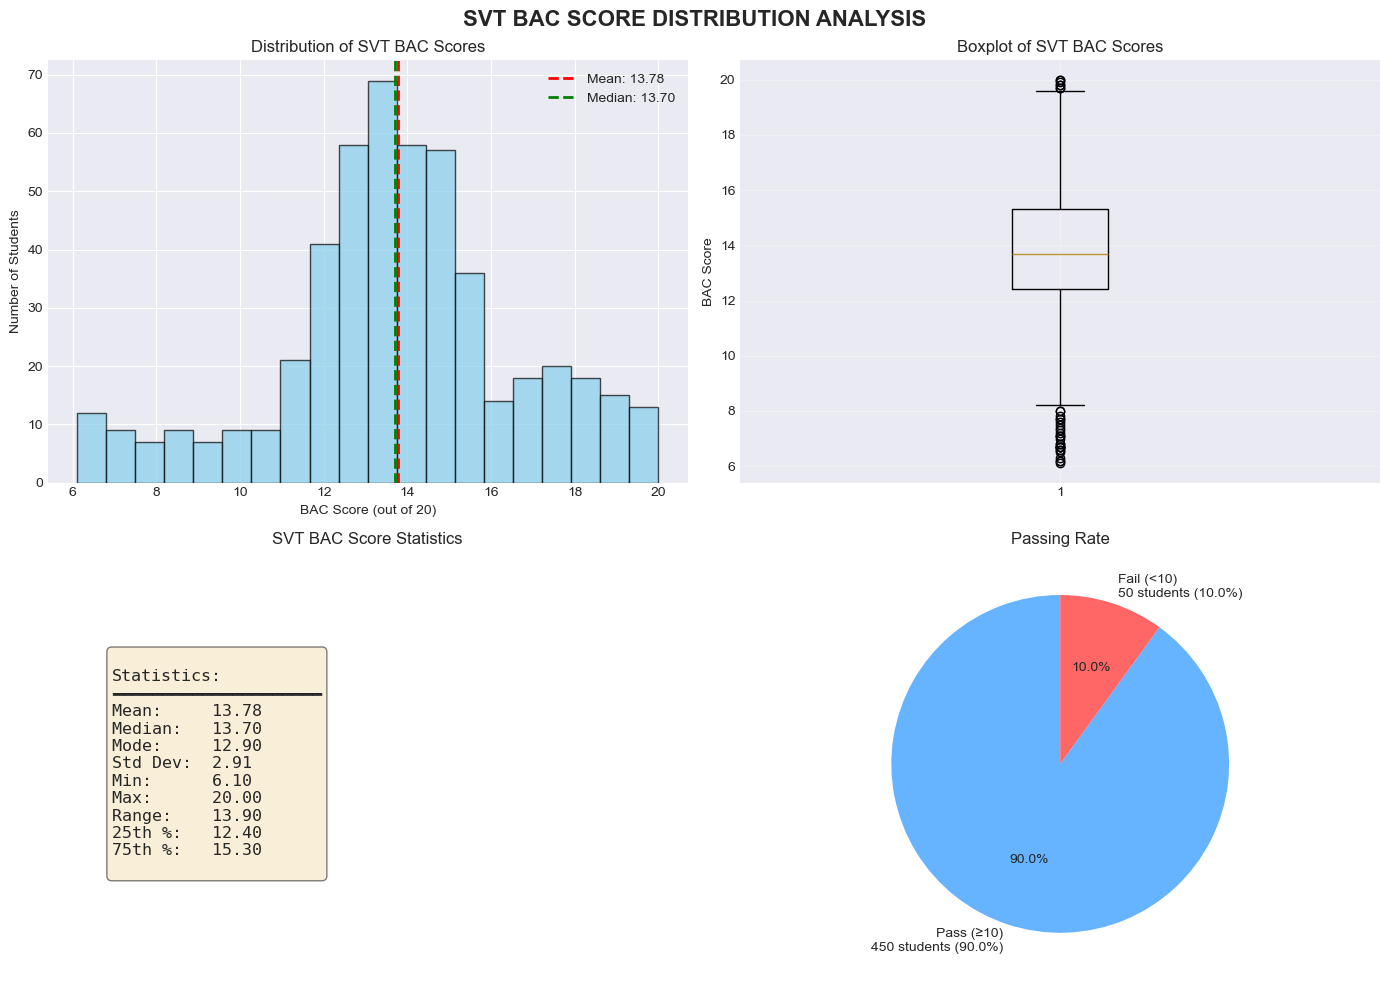


📊 SVT BAC SCORE DISTRIBUTION SUMMARY
   Mean BAC Score:     13.78/20
   Median BAC Score:   13.70/20
   Standard Deviation: 2.91
   Pass Rate (≥10):    90.0% (450/500 students)
   Fail Rate (<10):    10.0% (50/500 students)

📊 BAC SCORE BY STREAM:
   Sciences: Mean=13.80, Std=2.94, Min=6.1, Max=20.0
   Maths: Mean=13.74, Std=2.85, Min=6.7, Max=20.0


In [6]:
# ============================================
# CELL 6: EDA - BAC DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of BAC scores
axes[0,0].hist(df['bac_score_svt'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['bac_score_svt'].mean(), color='red', linestyle='dashed', linewidth=2, 
                  label=f'Mean: {df["bac_score_svt"].mean():.2f}')
axes[0,0].axvline(df['bac_score_svt'].median(), color='green', linestyle='dashed', linewidth=2, 
                  label=f'Median: {df["bac_score_svt"].median():.2f}')
axes[0,0].set_xlabel('BAC Score (out of 20)')
axes[0,0].set_ylabel('Number of Students')
axes[0,0].set_title('Distribution of SVT BAC Scores')
axes[0,0].legend()

# 2. Boxplot
axes[0,1].boxplot(df['bac_score_svt'], vert=True)
axes[0,1].set_ylabel('BAC Score')
axes[0,1].set_title('Boxplot of SVT BAC Scores')
axes[0,1].grid(True, alpha=0.3)

# 3. Statistics table
stats_text = f"""
Statistics:
━━━━━━━━━━━━━━━━━━━━━
Mean:     {df['bac_score_svt'].mean():.2f}
Median:   {df['bac_score_svt'].median():.2f}
Mode:     {df['bac_score_svt'].mode().iloc[0]:.2f}
Std Dev:  {df['bac_score_svt'].std():.2f}
Min:      {df['bac_score_svt'].min():.2f}
Max:      {df['bac_score_svt'].max():.2f}
Range:    {df['bac_score_svt'].max() - df['bac_score_svt'].min():.2f}
25th %:   {df['bac_score_svt'].quantile(0.25):.2f}
75th %:   {df['bac_score_svt'].quantile(0.75):.2f}
"""
axes[1,0].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center', 
               fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1,0].axis('off')
axes[1,0].set_title('SVT BAC Score Statistics')

# 4. Passing rate pie chart
passing = (df['bac_score_svt'] >= 10).sum()
failing = len(df) - passing
colors_pie = ['#66b3ff', '#ff6666']
labels = [f'Pass (≥10)\n{passing} students ({passing/len(df)*100:.1f}%)', 
          f'Fail (<10)\n{failing} students ({failing/len(df)*100:.1f}%)']
axes[1,1].pie([passing, failing], labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Passing Rate')

plt.suptitle('SVT BAC SCORE DISTRIBUTION ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 SVT BAC SCORE DISTRIBUTION SUMMARY")
print("="*60)
print(f"   Mean BAC Score:     {df['bac_score_svt'].mean():.2f}/20")
print(f"   Median BAC Score:   {df['bac_score_svt'].median():.2f}/20")
print(f"   Standard Deviation: {df['bac_score_svt'].std():.2f}")
print(f"   Pass Rate (≥10):    {passing/len(df)*100:.1f}% ({passing}/{len(df)} students)")
print(f"   Fail Rate (<10):    {failing/len(df)*100:.1f}% ({failing}/{len(df)} students)")
print("="*60)

# Additional: BAC distribution by stream
print("\n📊 BAC SCORE BY STREAM:")
print("="*60)
for stream in df['stream'].unique():
    spec_data = df[df['stream'] == stream]['bac_score_svt']
    print(f"   {stream}: Mean={spec_data.mean():.2f}, Std={spec_data.std():.2f}, Min={spec_data.min():.1f}, Max={spec_data.max():.1f}")
print("="*60)


📊 CORRELATION WITH BAC SCORE (highest to lowest):
   bac_score_svt                      : 1.000
   scientific_skills_composite        : 0.730
   svt_avg_grade                      : 0.686
   svt_grade_t3                       : 0.650
   svt_grade_t2                       : 0.642
   svt_grade_t1                       : 0.637
   energy_block                       : 0.622
   immune_block                       : 0.621
   immunology                         : 0.621
   molecular_biology                  : 0.612
   molecular_block                    : 0.612
   protein_enzymes                    : 0.568
   protein_block                      : 0.568
   psychological_health               : 0.553
   document_analysis                  : 0.552
   reasoning_chain                    : 0.506
   hypothesis_formulation             : 0.491
   energy_photosynthesis              : 0.489
   energy_respiration                 : 0.473
   practice_intensity                 : 0.467
   scientific_writing        

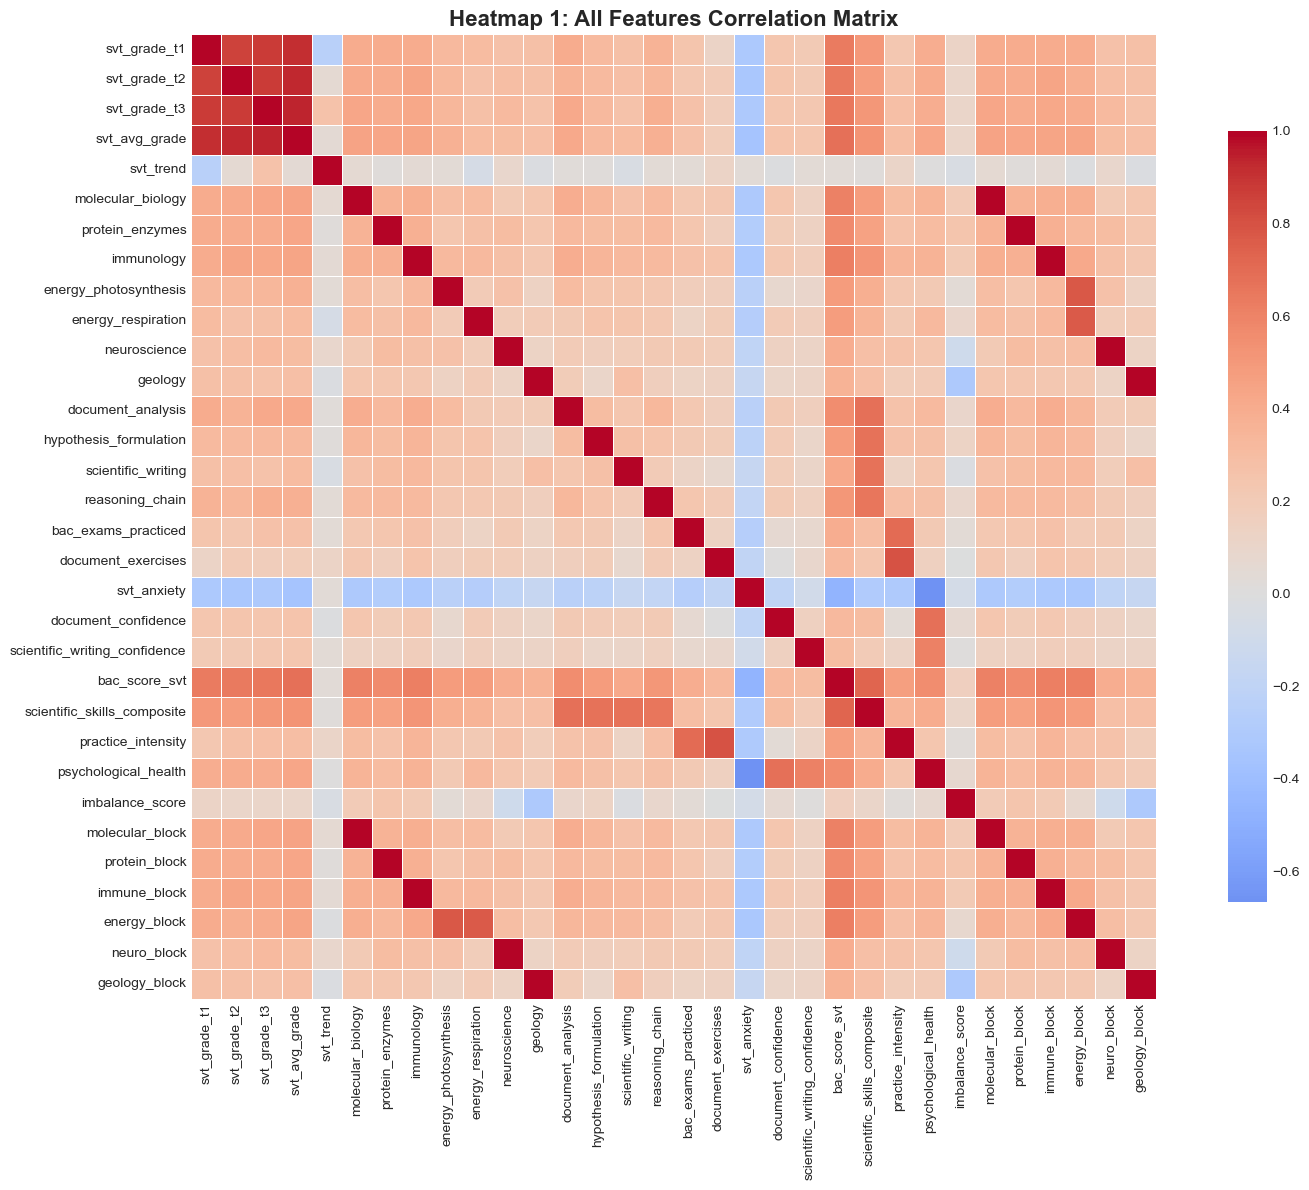


📊 HEATMAP 2: Top 15 Features Correlated with BAC Score


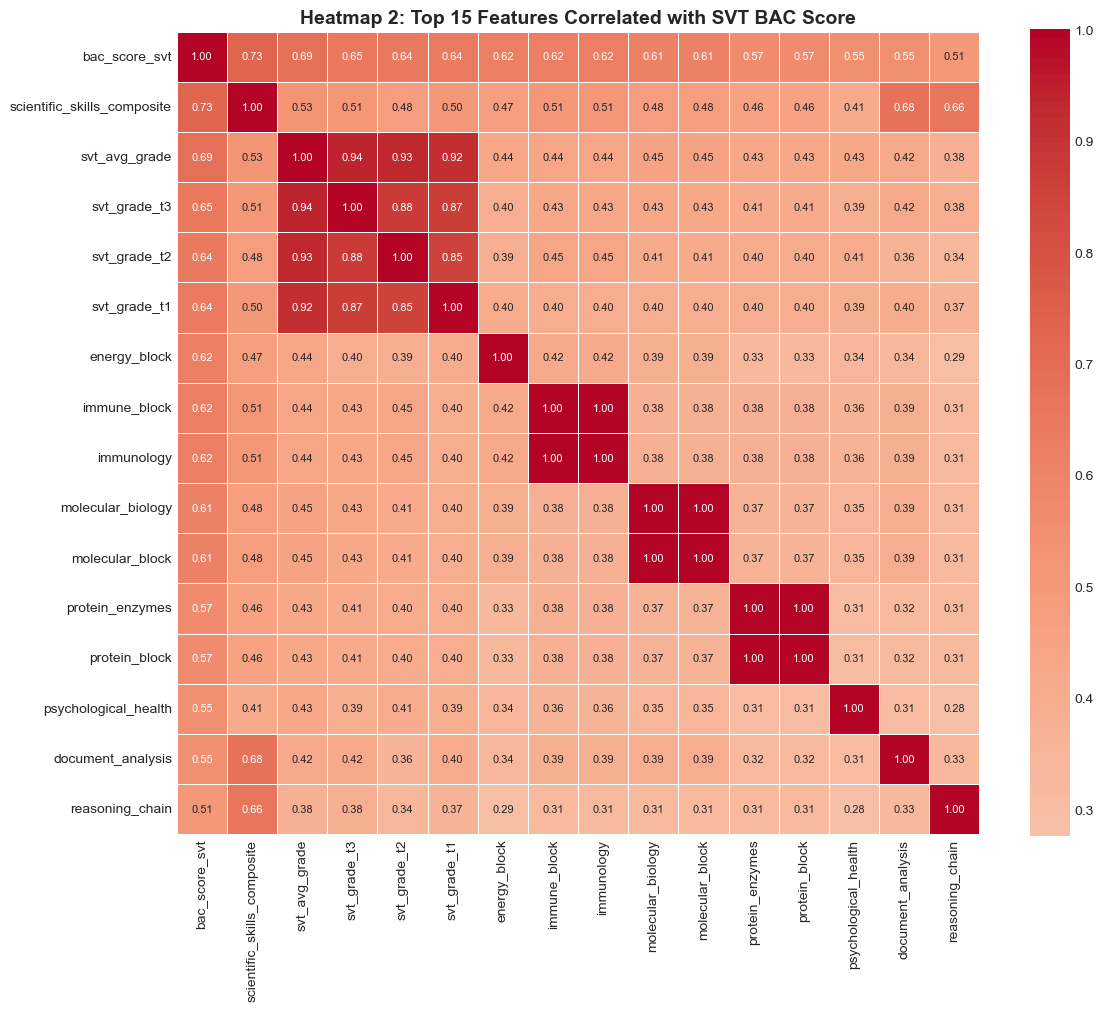


📊 HEATMAP 3: SVT Chapters Correlation


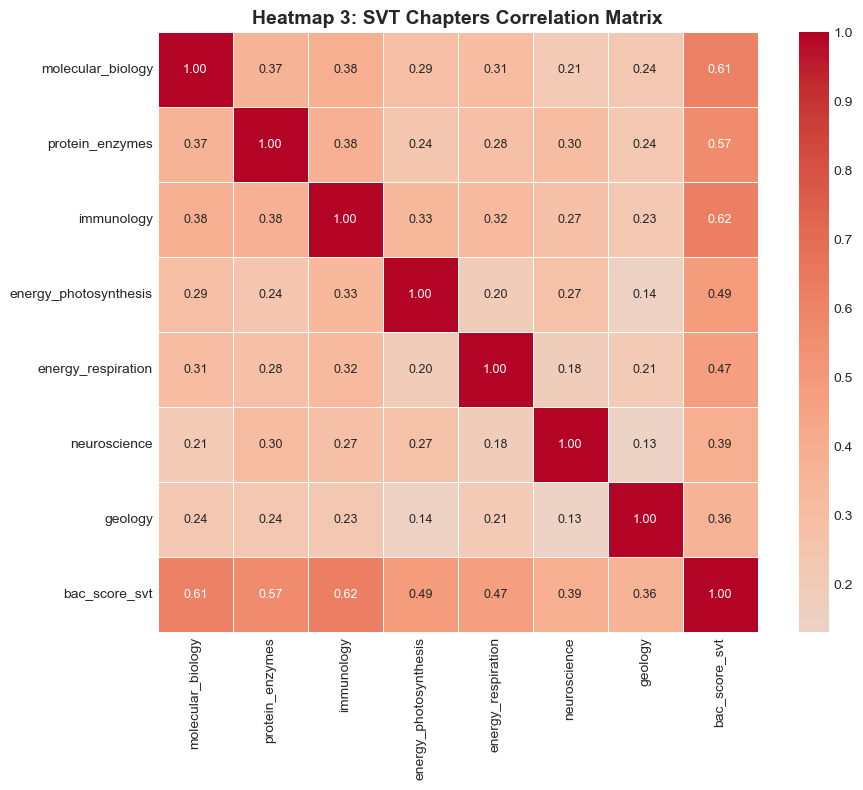


📋 SVT chapters correlation with BAC Score:
   • molecular_biology: correlation = 0.612
   • protein_enzymes: correlation = 0.568
   • immunology: correlation = 0.621
   • energy_photosynthesis: correlation = 0.489
   • energy_respiration: correlation = 0.473
   • neuroscience: correlation = 0.392
   • geology: correlation = 0.362

📊 HEATMAP 4: Scientific Skills Correlation


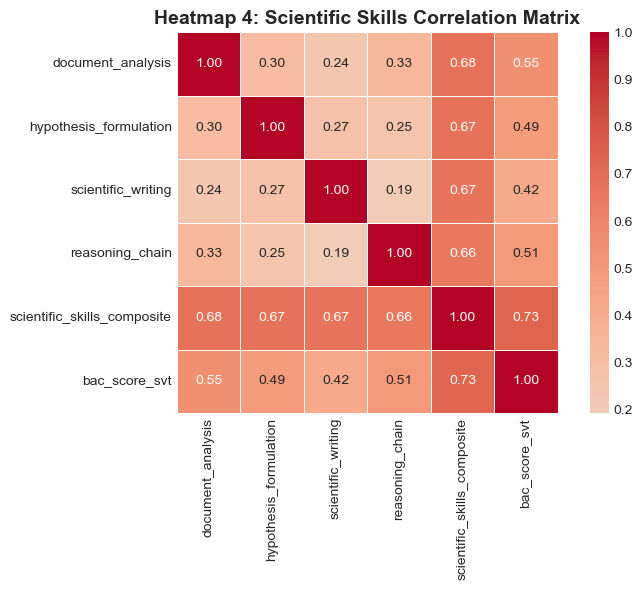


📋 Scientific skills correlation with BAC Score:
   • document_analysis: correlation = 0.552
   • hypothesis_formulation: correlation = 0.491
   • scientific_writing: correlation = 0.418
   • reasoning_chain: correlation = 0.506
   • scientific_skills_composite: correlation = 0.730

📊 HEATMAP 5: Psychological & Practice Factors Correlation


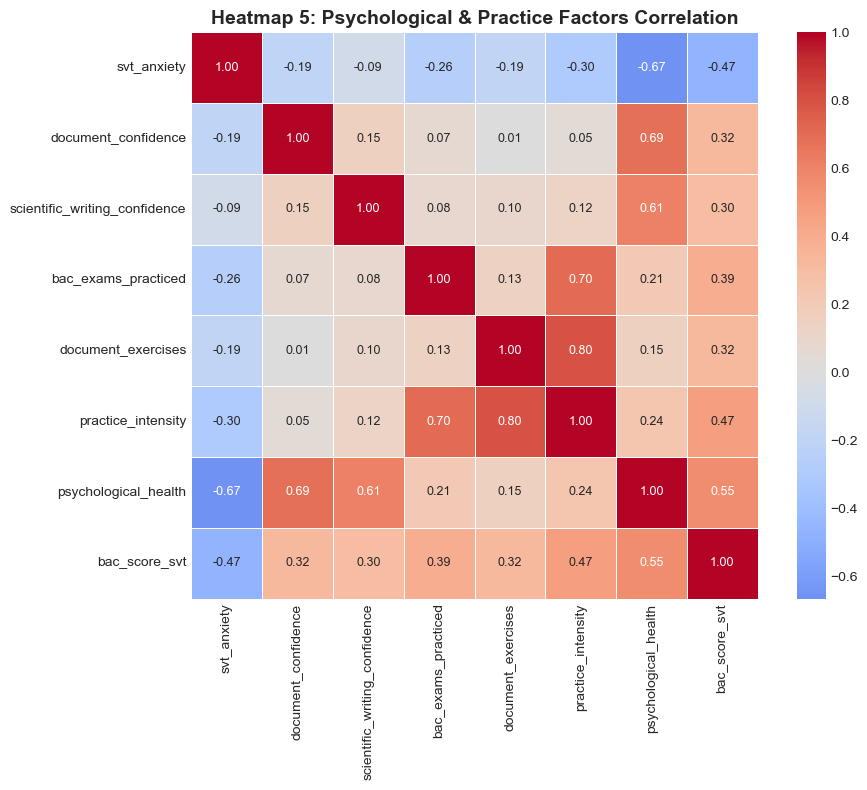


📋 Psychological & Practice factors correlation with BAC Score:
   • svt_anxiety: correlation = -0.465
   • document_confidence: correlation = 0.319
   • scientific_writing_confidence: correlation = 0.300
   • bac_exams_practiced: correlation = 0.393
   • document_exercises: correlation = 0.318
   • practice_intensity: correlation = 0.467
   • psychological_health: correlation = 0.553

📊 HEATMAP 6: Skill Blocks Correlation


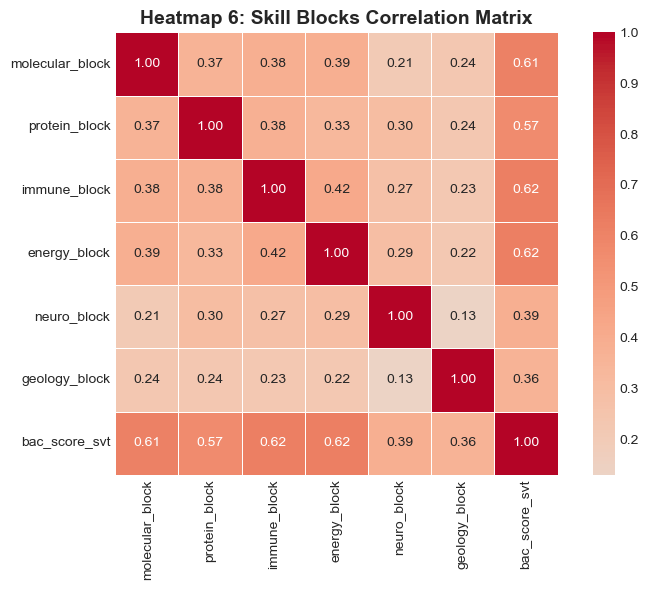


📋 Skill blocks correlation with BAC Score:
   • molecular_block: correlation = 0.612
   • protein_block: correlation = 0.568
   • immune_block: correlation = 0.621
   • energy_block: correlation = 0.622
   • neuro_block: correlation = 0.392
   • geology_block: correlation = 0.362

✅ Correlation Analysis Complete


In [7]:
# ============================================
# CELL 7: EDA - CORRELATION HEATMAPS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation (exclude 'stream' string column)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Get correlation with bac_score_svt (target)
bac_corr = corr_matrix['bac_score_svt'].sort_values(ascending=False)
print("\n📊 CORRELATION WITH BAC SCORE (highest to lowest):")
print("=" * 60)
for feature, corr_value in bac_corr.items():
    print(f"   {feature:35s}: {corr_value:.3f}")

# ============================================
# HEATMAP 1: All Features
# ============================================
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Heatmap 1: All Features Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 2: Top Features (highest correlation with BAC)
# ============================================
print("\n📊 HEATMAP 2: Top 15 Features Correlated with BAC Score")
print("=" * 60)

# Get top 15 features (excluding bac_score_svt itself)
top_features = bac_corr.head(16).index.tolist()  # includes bac_score_svt
corr_top = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_top, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Heatmap 2: Top 15 Features Correlated with SVT BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 3: SVT Chapters Correlation
# ============================================
print("\n📊 HEATMAP 3: SVT Chapters Correlation")
print("=" * 60)

svt_chapters = ['molecular_biology', 'protein_enzymes', 'immunology', 
                'energy_photosynthesis', 'energy_respiration', 
                'neuroscience', 'geology', 'bac_score_svt']
available_chapters = [c for c in svt_chapters if c in df.columns]

if len(available_chapters) > 1:
    corr_chapters = df[available_chapters].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_chapters, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 9})
    plt.title('Heatmap 3: SVT Chapters Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 SVT chapters correlation with BAC Score:")
    for chapter in available_chapters:
        if chapter != 'bac_score_svt':
            print(f"   • {chapter}: correlation = {corr_chapters[chapter]['bac_score_svt']:.3f}")

# ============================================
# HEATMAP 4: Scientific Skills Correlation
# ============================================
print("\n📊 HEATMAP 4: Scientific Skills Correlation")
print("=" * 60)

scientific_skills = ['document_analysis', 'hypothesis_formulation', 
                     'scientific_writing', 'reasoning_chain', 
                     'scientific_skills_composite', 'bac_score_svt']
available_skills = [s for s in scientific_skills if s in df.columns]

if len(available_skills) > 1:
    corr_skills = df[available_skills].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_skills, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 10})
    plt.title('Heatmap 4: Scientific Skills Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Scientific skills correlation with BAC Score:")
    for skill in available_skills:
        if skill != 'bac_score_svt':
            print(f"   • {skill}: correlation = {corr_skills[skill]['bac_score_svt']:.3f}")

# ============================================
# HEATMAP 5: Psychological & Practice Factors Correlation
# ============================================
print("\n📊 HEATMAP 5: Psychological & Practice Factors Correlation")
print("=" * 60)

psycho_practice = ['svt_anxiety', 'document_confidence', 'scientific_writing_confidence',
                   'bac_exams_practiced', 'document_exercises', 'practice_intensity',
                   'psychological_health', 'bac_score_svt']
available_psycho = [p for p in psycho_practice if p in df.columns]

if len(available_psycho) > 1:
    corr_psycho = df[available_psycho].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_psycho, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 9})
    plt.title('Heatmap 5: Psychological & Practice Factors Correlation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Psychological & Practice factors correlation with BAC Score:")
    for factor in available_psycho:
        if factor != 'bac_score_svt':
            print(f"   • {factor}: correlation = {corr_psycho[factor]['bac_score_svt']:.3f}")

# ============================================
# HEATMAP 6: Skill Blocks Correlation
# ============================================
print("\n📊 HEATMAP 6: Skill Blocks Correlation")
print("=" * 60)

blocks = ['molecular_block', 'protein_block', 'immune_block', 
          'energy_block', 'neuro_block', 'geology_block', 'bac_score_svt']
available_blocks = [b for b in blocks if b in df.columns]

if len(available_blocks) > 1:
    corr_blocks = df[available_blocks].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_blocks, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 10})
    plt.title('Heatmap 6: Skill Blocks Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Skill blocks correlation with BAC Score:")
    for block in available_blocks:
        if block != 'bac_score_svt':
            print(f"   • {block}: correlation = {corr_blocks[block]['bac_score_svt']:.3f}")

print("\n" + "=" * 60)
print("✅ Correlation Analysis Complete")
print("=" * 60)

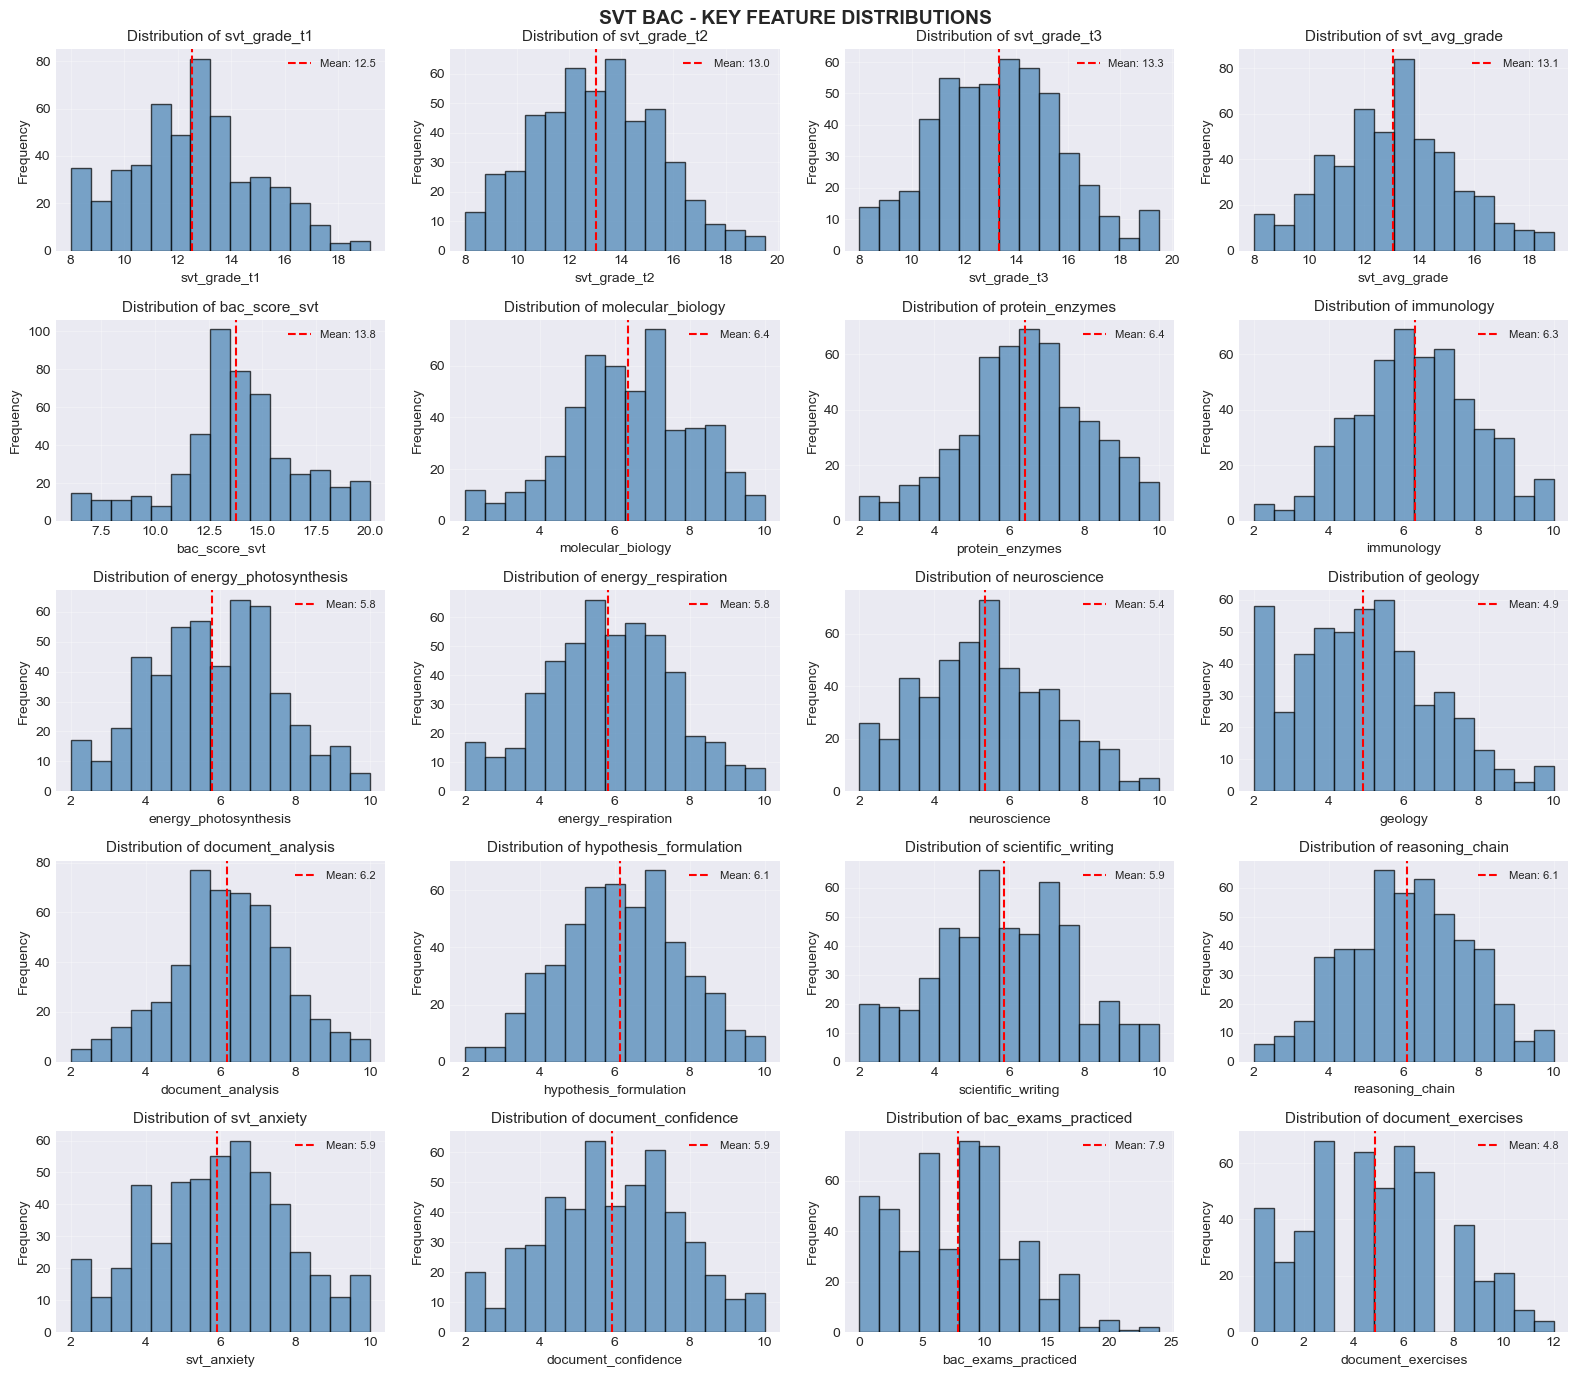


📊 KEY FEATURES SUMMARY STATISTICS
       svt_grade_t1  svt_grade_t2  svt_grade_t3  svt_avg_grade  bac_score_svt  \
count         500.0         500.0         500.0          500.0          500.0   
mean           12.5          13.0          13.3           13.1           13.8   
std             2.4           2.4           2.4            2.3            2.9   
min             8.0           8.0           8.0            8.0            6.1   
25%            10.9          11.3          11.7           11.5           12.4   
50%            12.6          13.0          13.3           13.1           13.7   
75%            13.9          14.7          14.9           14.5           15.3   
max            19.2          19.5          19.5           18.9           20.0   

       molecular_biology  protein_enzymes  immunology  energy_photosynthesis  \
count              500.0            500.0       500.0                  500.0   
mean                 6.4              6.4         6.3                    5.

In [8]:
# ============================================
# CELL 8: EDA - FEATURE DISTRIBUTIONS 
# ============================================

import matplotlib.pyplot as plt

# Select key features to visualize (SVT specific)
key_features = [
    'svt_grade_t1', 'svt_grade_t2', 'svt_grade_t3', 'svt_avg_grade', 'bac_score_svt',
    'molecular_biology', 'protein_enzymes', 'immunology', 
    'energy_photosynthesis', 'energy_respiration', 'neuroscience', 'geology',
    'document_analysis', 'hypothesis_formulation', 'scientific_writing', 'reasoning_chain',
    'svt_anxiety', 'document_confidence', 'bac_exams_practiced', 'document_exercises'
]

# Filter only features that exist in dataframe
available_features = [f for f in key_features if f in df.columns]

# Calculate grid size
n_features = len(available_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(available_features):
    axes[i].hist(df[feature], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=1.5, 
                    label=f'Mean: {df[feature].mean():.1f}')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].set_title(f'Distribution of {feature}', fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(available_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('SVT BAC - KEY FEATURE DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics for key features
print("\n" + "=" * 60)
print("📊 KEY FEATURES SUMMARY STATISTICS")
print("=" * 60)

summary_stats = df[available_features].describe().round(1)
print(summary_stats)

# Additional SVT-specific stats by stream
print("\n" + "=" * 60)
print("📊 SVT CHAPTERS BREAKDOWN BY STREAM")
print("=" * 60)

for stream in df['stream'].unique():
    df_stream = df[df['stream'] == stream]
    print(f"\n🔬 {stream}:")
    
    chapters = ['molecular_biology', 'protein_enzymes', 'immunology', 
                'energy_photosynthesis', 'energy_respiration', 'neuroscience', 'geology']
    for ch in chapters:
        if ch in df_stream.columns:
            print(f"   {ch}: mean={df_stream[ch].mean():.1f}, corr={df_stream['bac_score_svt'].corr(df_stream[ch]):.3f}")

# Scientific skills by stream
print("\n" + "=" * 60)
print("📊 SCIENTIFIC SKILLS BY STREAM")
print("=" * 60)

scientific_skills = ['document_analysis', 'hypothesis_formulation', 'scientific_writing', 'reasoning_chain']

for stream in df['stream'].unique():
    df_stream = df[df['stream'] == stream]
    print(f"\n🔬 {stream}:")
    for skill in scientific_skills:
        if skill in df_stream.columns:
            print(f"   {skill}: mean={df_stream[skill].mean():.1f}, corr={df_stream['bac_score_svt'].corr(df_stream[skill]):.3f}")

print("\n" + "=" * 60)
print("✅ Cell 8 complete!")
print("=" * 60)

In [9]:
# ============================================
# CELL 9: FEATURE ENGINEERING - SVT
# ============================================

print("=" * 40)
print("FEATURE ENGINEERING")
print("=" * 40)

# Create a copy of the dataframe for feature engineering
df_fe = df.copy()

# ============================================
# 1. Skill Blocks (Already calculated, ensure rounded)
# ============================================
df_fe['molecular_block'] = df_fe['molecular_block'].round(1)
df_fe['protein_block'] = df_fe['protein_block'].round(1)
df_fe['immune_block'] = df_fe['immune_block'].round(1)
df_fe['energy_block'] = df_fe['energy_block'].round(1)
df_fe['neuro_block'] = df_fe['neuro_block'].round(1)
df_fe['geology_block'] = df_fe['geology_block'].round(1)

# ============================================
# 2. Scientific Skills Composite (already calculated)
# ============================================
df_fe['scientific_skills_composite'] = df_fe['scientific_skills_composite'].round(1)

# ============================================
# 3. Practice Intensity (already calculated)
# ============================================
df_fe['practice_intensity'] = df_fe['practice_intensity'].round(1)

# ============================================
# 4. Psychological Health (already calculated)
# ============================================
df_fe['psychological_health'] = df_fe['psychological_health'].round(1)

# ============================================
# 5. Imbalance Score (already calculated)
# ============================================
df_fe['imbalance_score'] = df_fe['imbalance_score'].round(2)

# ============================================
# 6. Study Quality (based on exam practice and document exercises)
# ============================================
df_fe['study_quality'] = (df_fe['bac_exams_practiced'] / 30 * 10 * 0.6 + 
                          df_fe['document_exercises'] / 15 * 10 * 0.4)
df_fe['study_quality'] = np.round(df_fe['study_quality'], 1)

# ============================================
# 7. Biology vs Geology Balance (difference between bio and geo skills)
# ============================================
# Average of biology-related skills
bio_skills = (df_fe['molecular_biology'] + df_fe['protein_enzymes'] + 
              df_fe['immunology'] + df_fe['energy_photosynthesis'] + 
              df_fe['energy_respiration'] + df_fe['neuroscience']) / 6
df_fe['bio_geo_balance'] = (bio_skills - df_fe['geology']).round(1)

# ============================================
# 8. Document Analysis Confidence Score
# ============================================
df_fe['document_mastery'] = (df_fe['document_analysis'] + df_fe['document_confidence']) / 2
df_fe['document_mastery'] = np.round(df_fe['document_mastery'], 1)

# ============================================
# 9. Reasoning Quality Score
# ============================================
df_fe['reasoning_quality'] = (df_fe['reasoning_chain'] + df_fe['hypothesis_formulation']) / 2
df_fe['reasoning_quality'] = np.round(df_fe['reasoning_quality'], 1)

# ============================================
# 10. SVT Overall Score (average of all SVT chapters)
# ============================================
df_fe['svt_overall_score'] = (df_fe['molecular_biology'] + df_fe['protein_enzymes'] + 
                               df_fe['immunology'] + df_fe['energy_photosynthesis'] + 
                               df_fe['energy_respiration'] + df_fe['neuroscience'] + 
                               df_fe['geology']) / 7
df_fe['svt_overall_score'] = np.round(df_fe['svt_overall_score'], 1)

# ============================================
# Display new features
# ============================================
print("\n✅ New features created:")
print("   • molecular_block, protein_block, immune_block, energy_block, neuro_block, geology_block")
print("   • scientific_skills_composite (document_analysis + hypothesis + writing + reasoning)")
print("   • practice_intensity (bac_exams + document_exercises)")
print("   • psychological_health (document_confidence + writing_confidence - anxiety)")
print("   • imbalance_score (variance across all skill blocks)")
print("   • study_quality (bac_exams_practiced + document_exercises weighted)")
print("   • bio_geo_balance (difference between biology and geology skills)")
print("   • document_mastery (document_analysis + document_confidence)")
print("   • reasoning_quality (reasoning_chain + hypothesis_formulation)")
print("   • svt_overall_score (average of all SVT chapters)")

print("\n📊 First 5 rows (selected columns):")
selected_cols = ['bac_score_svt', 'stream', 'scientific_skills_composite', 
                 'practice_intensity', 'psychological_health', 'imbalance_score',
                 'study_quality', 'document_mastery', 'reasoning_quality', 'svt_overall_score']
available_selected = [c for c in selected_cols if c in df_fe.columns]
print(df_fe[available_selected].head().to_string())

print("\n📊 New features statistics:")
print(df_fe[available_selected].describe().to_string())

# Store the enhanced dataframe
df = df_fe.copy()

print("\n✅ Feature engineering complete. Total columns:", df.shape[1])
print("=" * 40)

FEATURE ENGINEERING

✅ New features created:
   • molecular_block, protein_block, immune_block, energy_block, neuro_block, geology_block
   • scientific_skills_composite (document_analysis + hypothesis + writing + reasoning)
   • practice_intensity (bac_exams + document_exercises)
   • psychological_health (document_confidence + writing_confidence - anxiety)
   • imbalance_score (variance across all skill blocks)
   • study_quality (bac_exams_practiced + document_exercises weighted)
   • bio_geo_balance (difference between biology and geology skills)
   • document_mastery (document_analysis + document_confidence)
   • reasoning_quality (reasoning_chain + hypothesis_formulation)
   • svt_overall_score (average of all SVT chapters)

📊 First 5 rows (selected columns):
   bac_score_svt    stream  scientific_skills_composite  practice_intensity  psychological_health  imbalance_score  study_quality  document_mastery  reasoning_quality  svt_overall_score
0           12.3  Sciences            

In [10]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT (with encoding)
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("=" * 40)
print("TRAIN/TEST SPLIT")
print("=" * 40)

# ============================================
# Encode categorical variables
# ============================================

# Make a copy to avoid modifying original
df_encoded = df.copy()

# Encode 'stream' column
le = LabelEncoder()
df_encoded['stream_encoded'] = le.fit_transform(df_encoded['stream'])
df_encoded = df_encoded.drop('stream', axis=1)

print("✅ Encoded 'stream' column to numeric:")
for i, category in enumerate(le.classes_):
    print(f"   {category} → {i}")

# ============================================
# Define features (X) and target (y)
# ============================================

exclude_cols = ['bac_score_svt']
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

X = df_encoded[feature_cols]
y = df_encoded['bac_score_svt']

print(f"\n📊 Features (X): {X.shape[1]} columns")
print(f"📊 Target (y): bac_score_svt")

# ============================================
# Split data (80% train, 20% test)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Split complete:")
print(f"   Training set: {X_train.shape[0]} students ({X_train.shape[0]/len(df_encoded)*100:.0f}%)")
print(f"   Test set:     {X_test.shape[0]} students ({X_test.shape[0]/len(df_encoded)*100:.0f}%)")

# ============================================
# Display first few rows
# ============================================
print("\n📋 First 3 rows of training features:")
print(X_train.head(3).to_string())

print("\n📋 First 3 target values (bac_score_svt):")
print(y_train.head(3).tolist())

# ============================================
# Verify no data leakage
# ============================================
print("\n✅ No overlap between train and test:")
print(f"   Train indices: {X_train.index[:5].tolist()}...")
print(f"   Test indices:  {X_test.index[:5].tolist()}...")

# Update df for later cells
df = df_encoded.copy()
print("\n✅ Data ready for model training (Cell 11)")

TRAIN/TEST SPLIT
✅ Encoded 'stream' column to numeric:
   Maths → 0
   Sciences → 1

📊 Features (X): 37 columns
📊 Target (y): bac_score_svt

✅ Split complete:
   Training set: 400 students (80%)
   Test set:     100 students (20%)

📋 First 3 rows of training features:
     svt_grade_t1  svt_grade_t2  svt_grade_t3  svt_avg_grade  svt_trend  molecular_biology  protein_enzymes  immunology  energy_photosynthesis  energy_respiration  neuroscience  geology  document_analysis  hypothesis_formulation  scientific_writing  reasoning_chain  bac_exams_practiced  document_exercises  svt_anxiety  document_confidence  scientific_writing_confidence  scientific_skills_composite  practice_intensity  psychological_health  imbalance_score  molecular_block  protein_block  immune_block  energy_block  neuro_block  geology_block  study_quality  bio_geo_balance  document_mastery  reasoning_quality  svt_overall_score  stream_encoded
249          11.3          11.7          13.3           11.9        2.0        

In [11]:
# ============================================
# CELL 11: MODEL TRAINING - SVT BAC
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 40)
print("MODEL TRAINING - SVT BAC")
print("=" * 40)

# ============================================
# Train Random Forest Regressor
# ============================================

print(f"\n🚀 Training Random Forest Regressor...")

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print(f"✅ Model training complete")

# ============================================
# Make predictions
# ============================================
y_pred = model.predict(X_test)

# ============================================
# Evaluate model
# ============================================
print("\n" + "=" * 40)
print("MODEL EVALUATION")
print("=" * 40)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Performance Metrics:")
print(f"   MAE:  {mae:.2f} points")
print(f"   RMSE: {rmse:.2f} points")
print(f"   R²:   {r2:.3f}")

# ============================================
# Feature Importance
# ============================================
print("\n" + "=" * 40)
print("FEATURE IMPORTANCE")
print("=" * 40)

feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 20 most important features:")
for i, row in feature_importance_df.head(20).iterrows():
    print(f"   {row['feature']:35s}: {row['importance']:.4f}")

# ============================================
# Sample predictions vs actual
# ============================================
print("\n" + "=" * 40)
print("SAMPLE PREDICTIONS (First 10 test students)")
print("=" * 40)

sample_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': np.round(y_pred[:10], 1),
    'Error': np.round(y_test.values[:10] - y_pred[:10], 1)
})
print(sample_df.to_string())

print("\n✅ Model ready for Cell 12")

MODEL TRAINING - SVT BAC

🚀 Training Random Forest Regressor...
✅ Model training complete

MODEL EVALUATION

📊 Performance Metrics:
   MAE:  1.11 points
   RMSE: 1.45 points
   R²:   0.769

FEATURE IMPORTANCE

Top 20 most important features:
   svt_overall_score                  : 0.5200
   scientific_skills_composite        : 0.1839
   reasoning_quality                  : 0.0293
   psychological_health               : 0.0269
   svt_avg_grade                      : 0.0192
   svt_grade_t2                       : 0.0185
   svt_grade_t1                       : 0.0175
   svt_grade_t3                       : 0.0171
   document_mastery                   : 0.0102
   energy_block                       : 0.0094
   scientific_writing_confidence      : 0.0085
   svt_anxiety                        : 0.0084
   hypothesis_formulation             : 0.0083
   reasoning_chain                    : 0.0081
   stream_encoded                     : 0.0076
   energy_photosynthesis              : 0.0075
   imm

MODEL EVALUATION (DETAILED) - SVT BAC

----------------------------------------
1. SCORE PREDICTION (0-20)
----------------------------------------
   Mean Absolute Error (MAE):     1.111 points
   Mean Squared Error (MSE):      2.102
   Root Mean Squared Error (RMSE): 1.450 points
   R² Score:                      0.769

----------------------------------------
2. PASS/FAIL CLASSIFICATION (≥10/20)
----------------------------------------
   Accuracy: 0.950 (95.0%)

   Confusion Matrix:
   True Negatives (correct fail):  8
   False Positives:                2
   False Negatives:                3
   True Positives (correct pass):  87

   Classification Report:
              precision    recall  f1-score   support

  Fail (<10)       0.73      0.80      0.76        10
  Pass (≥10)       0.98      0.97      0.97        90

    accuracy                           0.95       100
   macro avg       0.85      0.88      0.87       100
weighted avg       0.95      0.95      0.95       100



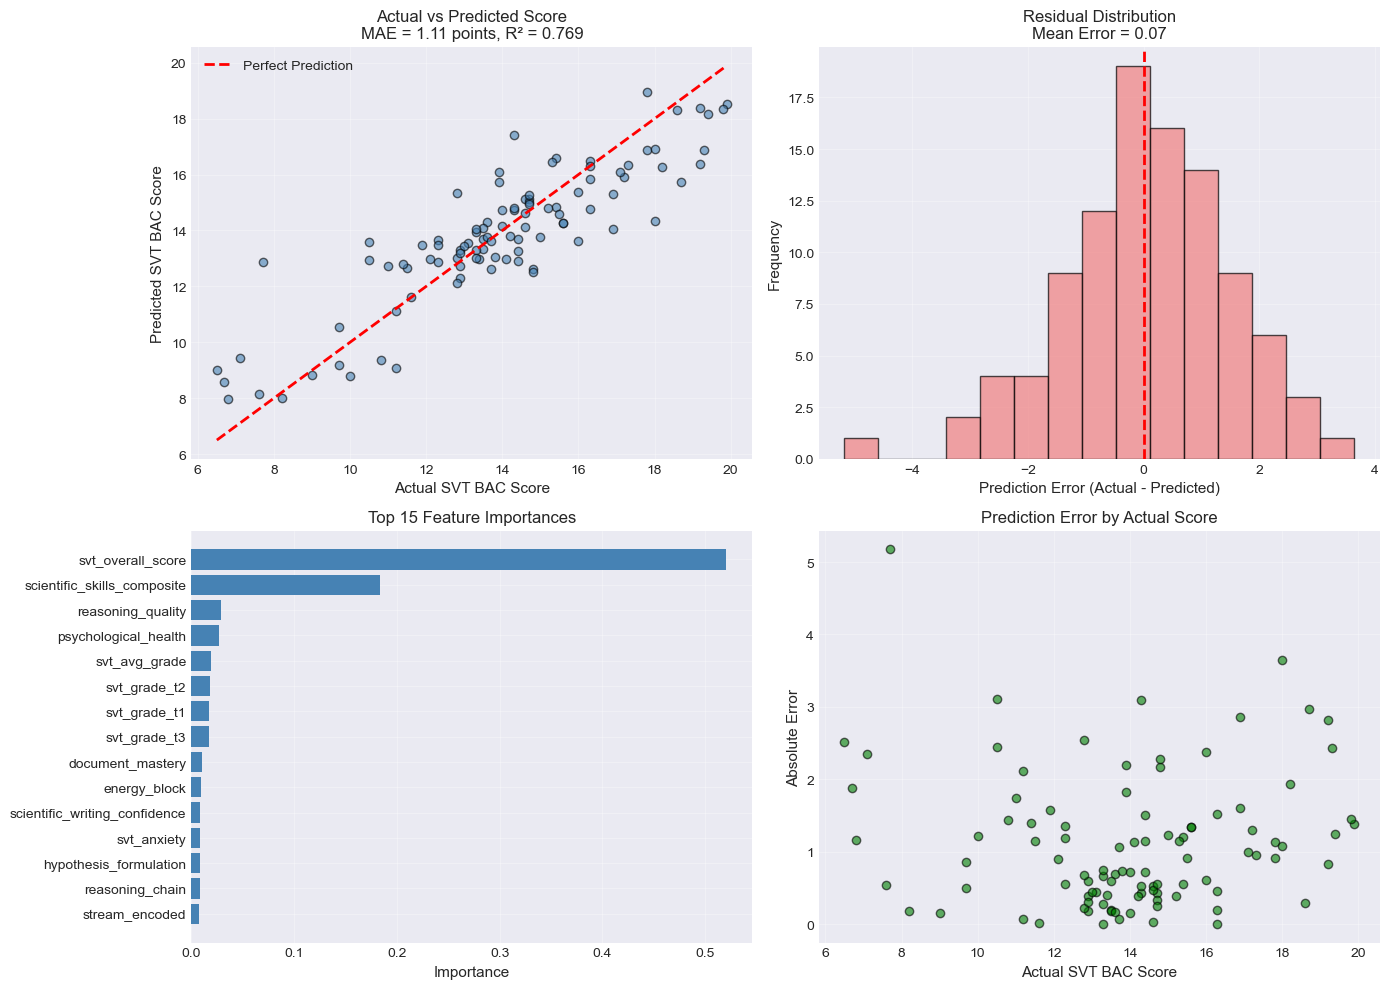


----------------------------------------
3. ERROR SUMMARY
----------------------------------------
   Mean Error:      1.111 points
   Median Error:    0.902 points
   Max Error:       5.176 points
   Error < 1 point: 54.0% of predictions
   Error < 2 points: 83.0% of predictions

✅ Evaluation Complete


In [12]:
# ============================================
# CELL 12: MODEL EVALUATION (DETAILED) - SVT BAC
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

print("=" * 50)
print("MODEL EVALUATION (DETAILED) - SVT BAC")
print("=" * 50)

# ============================================
# 1. Score Prediction Metrics
# ============================================
print("\n" + "-" * 40)
print("1. SCORE PREDICTION (0-20)")
print("-" * 40)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"   Mean Absolute Error (MAE):     {mae:.3f} points")
print(f"   Mean Squared Error (MSE):      {mse:.3f}")
print(f"   Root Mean Squared Error (RMSE): {rmse:.3f} points")
print(f"   R² Score:                      {r2:.3f}")

# ============================================
# 2. Success Classification (Pass/Fail)
# ============================================
print("\n" + "-" * 40)
print("2. PASS/FAIL CLASSIFICATION (≥10/20)")
print("-" * 40)

y_true_class = (y_test >= 10).astype(int)
y_pred_class = (y_pred >= 10).astype(int)

accuracy = accuracy_score(y_true_class, y_pred_class)
print(f"   Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n   Confusion Matrix:")
cm = confusion_matrix(y_true_class, y_pred_class)
print(f"   True Negatives (correct fail):  {cm[0][0]}")
print(f"   False Positives:                {cm[0][1]}")
print(f"   False Negatives:                {cm[1][0]}")
print(f"   True Positives (correct pass):  {cm[1][1]}")

print("\n   Classification Report:")
print(classification_report(y_true_class, y_pred_class, target_names=['Fail (<10)', 'Pass (≥10)']))

# ============================================
# 3. Visualizations
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted Score
axes[0,0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='black')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0,0].set_xlabel('Actual SVT BAC Score', fontsize=11)
axes[0,0].set_ylabel('Predicted SVT BAC Score', fontsize=11)
axes[0,0].set_title(f'Actual vs Predicted Score\nMAE = {mae:.2f} points, R² = {r2:.3f}', fontsize=12)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals (Error Distribution)
residuals = y_test - y_pred
axes[0,1].hist(residuals, bins=15, edgecolor='black', color='lightcoral', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[0,1].set_xlabel('Prediction Error (Actual - Predicted)', fontsize=11)
axes[0,1].set_ylabel('Frequency', fontsize=11)
axes[0,1].set_title(f'Residual Distribution\nMean Error = {residuals.mean():.2f}', fontsize=12)
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 15)
feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=True).tail(15)

axes[1,0].barh(feature_importance_df['feature'], feature_importance_df['importance'], color='steelblue')
axes[1,0].set_xlabel('Importance', fontsize=11)
axes[1,0].set_title('Top 15 Feature Importances', fontsize=12)
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Prediction Error by Actual Score
axes[1,1].scatter(y_test, np.abs(residuals), alpha=0.6, color='green', edgecolors='black')
axes[1,1].set_xlabel('Actual SVT BAC Score', fontsize=11)
axes[1,1].set_ylabel('Absolute Error', fontsize=11)
axes[1,1].set_title('Prediction Error by Actual Score', fontsize=12)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 4. Error Summary
# ============================================
print("\n" + "-" * 40)
print("3. ERROR SUMMARY")
print("-" * 40)

errors = np.abs(y_test - y_pred)
print(f"   Mean Error:      {errors.mean():.3f} points")
print(f"   Median Error:    {errors.median():.3f} points")
print(f"   Max Error:       {errors.max():.3f} points")
print(f"   Error < 1 point: {(errors < 1).mean()*100:.1f}% of predictions")
print(f"   Error < 2 points: {(errors < 2).mean()*100:.1f}% of predictions")

print("\n" + "=" * 50)
print("✅ Evaluation Complete")
print("=" * 50)

SHAP EXPLAINABILITY - SVT BAC

📊 Creating SHAP explainer...
✅ SHAP explainer created
   SHAP values shape: (100, 37)


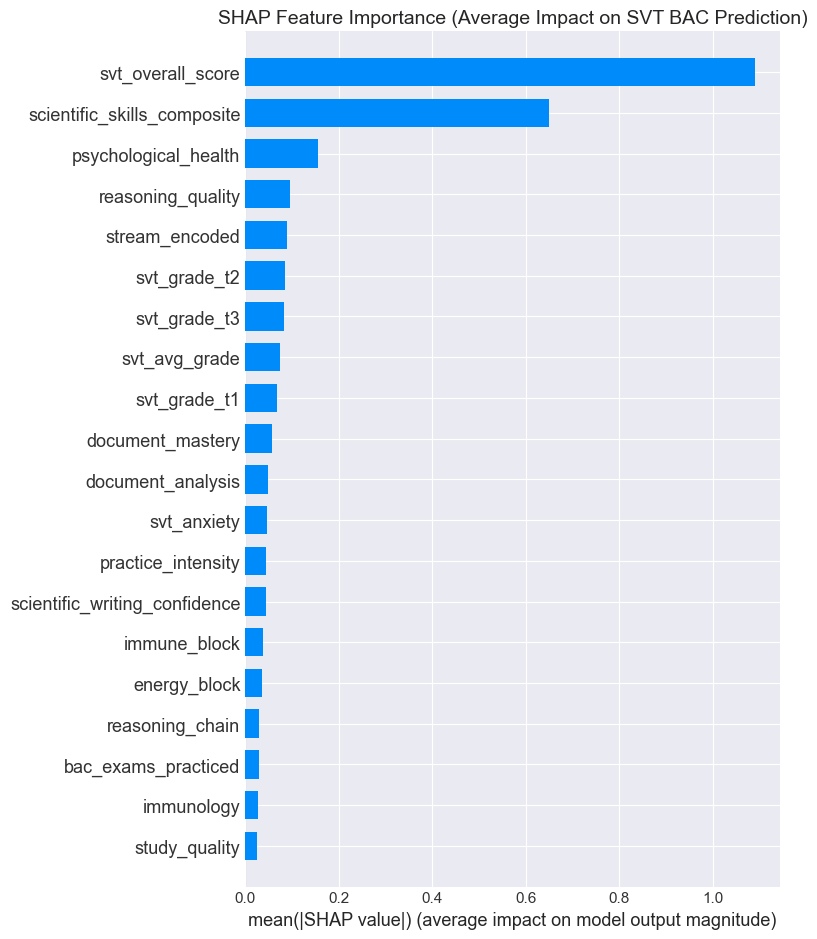

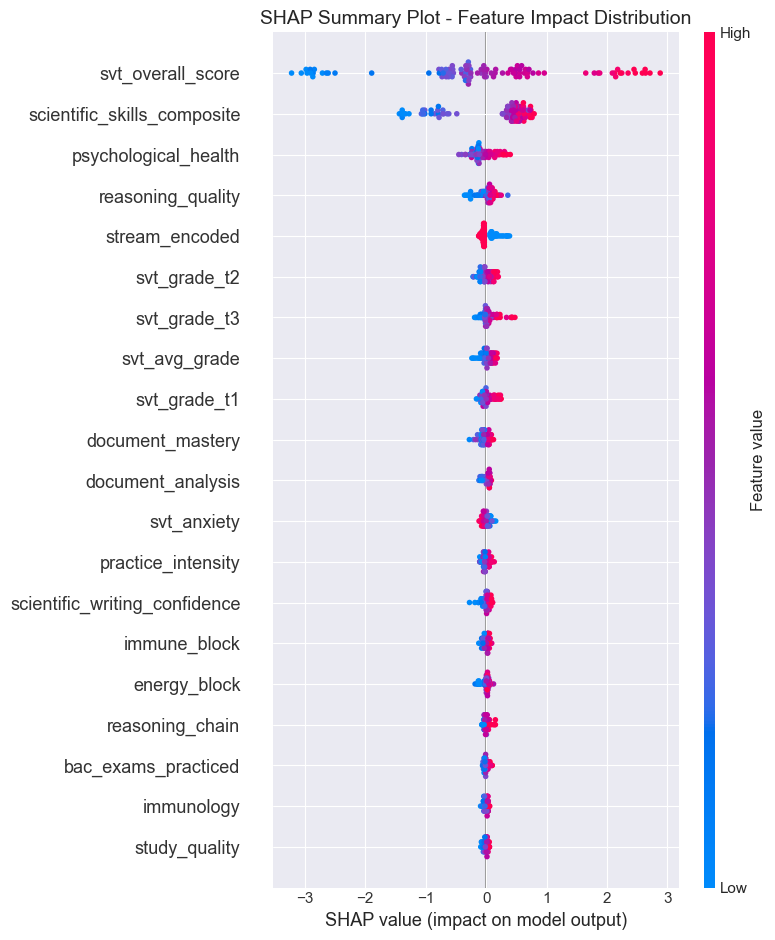


SINGLE STUDENT EXPLANATION

📊 Student #0:
   Actual SVT BAC score: 14.4
   Predicted SVT BAC score: 13.3


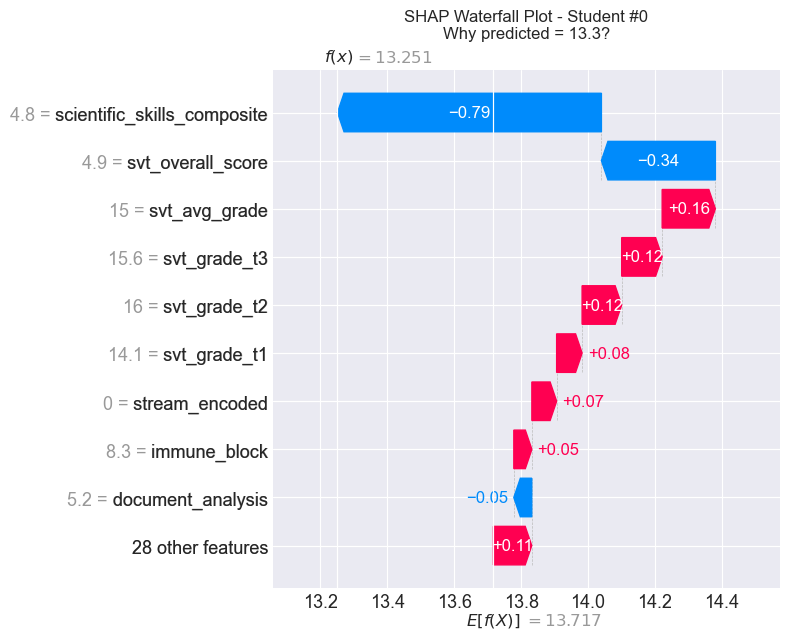


SIMPLE EXPLANATION (Student-Friendly)

✅ This student's predicted score: 13.3

🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):
   • scientific_skills_composite: -0.79 points
   • svt_overall_score: -0.34 points
   • document_analysis: -0.05 points
   • psychological_health: -0.05 points
   • protein_enzymes: -0.03 points

🟢 FACTORS THAT RAISED THE SCORE (Strengths):
   • svt_avg_grade: +0.16 points
   • svt_grade_t3: +0.12 points
   • svt_grade_t2: +0.12 points
   • svt_grade_t1: +0.08 points
   • stream_encoded: +0.07 points

✅ SHAP Explainability Complete


In [13]:
# ============================================
# CELL 13: SHAP EXPLAINABILITY - SVT BAC
# ============================================

import shap
import matplotlib.pyplot as plt

print("=" * 50)
print("SHAP EXPLAINABILITY - SVT BAC")
print("=" * 50)

# ============================================
# Create SHAP explainer
# ============================================
print("\n📊 Creating SHAP explainer...")

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"✅ SHAP explainer created")
print(f"   SHAP values shape: {shap_values.shape}")

# ============================================
# Visualization 1: Feature Importance (SHAP)
# ============================================
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Average Impact on SVT BAC Prediction)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visualization 2: Summary Plot (Beeswarm)
# ============================================
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visualization 3: Single Student Explanation
# ============================================
print("\n" + "=" * 50)
print("SINGLE STUDENT EXPLANATION")
print("=" * 50)

# Pick the first student from test set
student_idx = 0
student_features = X_test.iloc[student_idx:student_idx+1]
student_actual = y_test.iloc[student_idx]
student_pred = model.predict(student_features)[0]

print(f"\n📊 Student #{student_idx}:")
print(f"   Actual SVT BAC score: {student_actual:.1f}")
print(f"   Predicted SVT BAC score: {student_pred:.1f}")

# Create waterfall plot for this student
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=student_features.values[0],
        feature_names=student_features.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall Plot - Student #{student_idx}\nWhy predicted = {student_pred:.1f}?', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# Print SHAP explanation in simple terms
# ============================================
print("\n" + "=" * 50)
print("SIMPLE EXPLANATION (Student-Friendly)")
print("=" * 50)

# Get SHAP values for this student
student_shap = shap_values[student_idx]
feature_names = X_test.columns.tolist()

# Create DataFrame with feature contributions
shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_value': student_shap
})
shap_df['absolute'] = np.abs(shap_df['shap_value'])
shap_df = shap_df.sort_values('absolute', ascending=False)

# Separate positive and negative contributions
positive = shap_df[shap_df['shap_value'] > 0].head(5)
negative = shap_df[shap_df['shap_value'] < 0].head(5)

print(f"\n✅ This student's predicted score: {student_pred:.1f}")
print(f"\n🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):")
if len(negative) > 0:
    for _, row in negative.iterrows():
        print(f"   • {row['feature']}: -{abs(row['shap_value']):.2f} points")
else:
    print("   • None - this student has no major weaknesses!")

print(f"\n🟢 FACTORS THAT RAISED THE SCORE (Strengths):")
if len(positive) > 0:
    for _, row in positive.iterrows():
        print(f"   • {row['feature']}: +{row['shap_value']:.2f} points")
else:
    print("   • None")

print("\n" + "=" * 50)
print("✅ SHAP Explainability Complete")
print("=" * 50)

In [14]:
# ============================================
# CELL 14: WEAKNESS ANALYSIS (PER STUDENT) - SVT BAC
# ============================================

import pandas as pd
import numpy as np
from collections import Counter

print("=" * 50)
print("WEAKNESS ANALYSIS - SVT BAC")
print("=" * 50)

# ============================================
# Use SHAP values to identify weaknesses
# ============================================

# Get feature names and SHAP values from Cell 13
feature_names = X_test.columns.tolist()
shap_values_array = np.array(shap_values)

# Create DataFrame of SHAP values for all test students
shap_df = pd.DataFrame(shap_values_array, columns=feature_names)

# ============================================
# For each student, identify top 3 weaknesses and top 3 strengths
# ============================================

print("\n📊 Analyzing weaknesses for each student...")

weakness_list = []

for i in range(len(X_test)):
    student_shap = shap_df.iloc[i]
    
    # Get negative contributions (weaknesses)
    weaknesses = student_shap[student_shap < 0].sort_values()
    top_weaknesses = weaknesses.head(3)
    
    # Get positive contributions (strengths)
    strengths = student_shap[student_shap > 0].sort_values(ascending=False)
    top_strengths = strengths.head(3)
    
    weakness_list.append({
        'student_id': i,
        'weakness_1': f"{top_weaknesses.index[0]} ({top_weaknesses.values[0]:.2f})" if len(top_weaknesses) > 0 else "None",
        'weakness_2': f"{top_weaknesses.index[1]} ({top_weaknesses.values[1]:.2f})" if len(top_weaknesses) > 1 else "None",
        'weakness_3': f"{top_weaknesses.index[2]} ({top_weaknesses.values[2]:.2f})" if len(top_weaknesses) > 2 else "None",
        'strength_1': f"{top_strengths.index[0]} (+{top_strengths.values[0]:.2f})" if len(top_strengths) > 0 else "None",
        'strength_2': f"{top_strengths.index[1]} (+{top_strengths.values[1]:.2f})" if len(top_strengths) > 1 else "None",
        'strength_3': f"{top_strengths.index[2]} (+{top_strengths.values[2]:.2f})" if len(top_strengths) > 2 else "None",
        'actual_score': y_test.iloc[i],
        'predicted_score': y_pred[i]
    })

weakness_df = pd.DataFrame(weakness_list)

# ============================================
# Display first 10 students
# ============================================
print("\n📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:")
print("=" * 80)
for i in range(min(10, len(weakness_df))):
    row = weakness_df.iloc[i]
    print(f"\n🔹 STUDENT {i+1}: Actual={row['actual_score']:.1f}, Predicted={row['predicted_score']:.1f}")
    print(f"   🔴 Weaknesses:")
    print(f"      • {row['weakness_1']}")
    print(f"      • {row['weakness_2']}")
    print(f"      • {row['weakness_3']}")
    print(f"   🟢 Strengths:")
    print(f"      • {row['strength_1']}")
    print(f"      • {row['strength_2']}")
    print(f"      • {row['strength_3']}")

# ============================================
# Most common weaknesses across all students
# ============================================
print("\n" + "=" * 50)
print("MOST COMMON WEAKNESSES (All Students)")
print("=" * 50)

all_weaknesses = []
for i in range(len(weakness_df)):
    for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
        if w != "None":
            feature_name = w.split(' (')[0]
            all_weaknesses.append(feature_name)

weakness_counts = Counter(all_weaknesses)

print("\nTop 15 most frequent weaknesses:")
for feature, count in weakness_counts.most_common(15):
    print(f"   • {feature}: {count} students")

# ============================================
# Generate actionable recommendations for SVT
# ============================================
print("\n" + "=" * 50)
print("ACTIONABLE RECOMMENDATIONS - SVT")
print("=" * 50)

# Map features to SVT-specific recommendations
recommendation_map = {
    # Academic
    'svt_avg_grade': '📊 رفع المعدل العام في الفصول الثلاثة',
    'svt_grade_t1': '📊 تحسين الأداء في الفصل الأول',
    'svt_grade_t2': '📊 تحسين الأداء في الفصل الثاني',
    'svt_grade_t3': '📊 تحسين الأداء في الفصل الثالث',
    'svt_trend': '📈 الحفاظ على تحسن مستمر في المعدلات',
    
    # SVT Chapters
    'molecular_biology': '🧬 البيولوجيا الجزيئية: ركز على تضاعف ADN، النسخ، والترجمة',
    'molecular_block': '🧬 البيولوجيا الجزيئية: تدرب على آلية تركيب البروتين',
    'protein_enzymes': '🧫 البروتينات والأنزيمات: راجع بنية البروتين وآلية عمل الأنزيمات',
    'protein_block': '🧫 البروتينات: ركز على العلاقة بين البنية والوظيفة',
    'immunology': '🛡️ المناعة: راجع HLA، TAP، الأجسام المضادة، LT4، LT8',
    'immune_block': '🛡️ المناعة: تدرب على تحليل حالات نقص المناعة (HIV)',
    'energy_photosynthesis': '🌿 التركيب الضوئي: راجع التفاعلات الضوئية ودورة كالفن',
    'energy_respiration': '🔥 التنفس الخلوي: راجع مراحل هدم الغلوكوز وإنتاج ATP',
    'energy_block': '⚡ تحويل الطاقة: ركز على التفاعلات الضوئية والكيموحيوية',
    'neuroscience': '🧠 العلوم العصبية: راجع النقل المشبكي والنواقل العصبية',
    'neuro_block': '🧠 الجهاز العصبي: تدرب على تحليل منحنيات كمون العمل',
    'geology': '🌍 الجيولوجيا: راجع حركات الصفائح التكتونية والغوص',
    'geology_block': '🌍 الجيولوجيا: تدرب على تحليل المقاطع الجيولوجية',
    
    # Scientific Skills (CRITICAL for SVT!)
    'document_analysis': '📄 تحليل الوثائق: تدرب على قراءة المنحنيات والجداول والتجارب',
    'hypothesis_formulation': '🔬 اقتراح الفرضيات: حلل النتائج واقترح تفسيرات علمية',
    'scientific_writing': '✍️ الكتابة العلمية: نظم إجاباتك بمقدمة وعرض وخاتمة',
    'reasoning_chain': '🔗 التسلسل المنطقي: ربط الأسباب بالنتائج في سلاسل منطقية',
    'scientific_skills_composite': '🔬 المهارات العلمية: ركز على تحليل الوثائق والتفسير',
    'document_mastery': '📄 إتقان تحليل الوثائق: تدرب على تفسير مختلف أنواع الوثائق',
    'reasoning_quality': '🧠 جودة الاستدلال: حسّن قدرتك على بناء سلاسل منطقية',
    
    # Practice
    'bac_exams_practiced': '📝 الامتحانات السابقة: حل امتحان بكالوريا في SVT كل أسبوع',
    'document_exercises': '📊 تمارين الوثائق: حل تمارين متنوعة لتحليل الوثائق',
    'practice_intensity': '⚡ كثافة التمارين: زد عدد التمارين التي تحلها أسبوعياً',
    'study_quality': '📚 جودة الدراسة: ركز على تحليل الوثائق أكثر من الحفظ',
    'svt_overall_score': '🎯 المستوى العام: وازن بين مهاراتك في جميع الفروع',
    
    # Psychological
    'svt_anxiety': '😌 قلق SVT: ابدأ بتمارين سهلة وزد الصعوبة تدريجياً',
    'document_confidence': '💪 الثقة في تحليل الوثائق: تدرب بانتظام على أنواع مختلفة من الوثائق',
    'scientific_writing_confidence': '✍️ الثقة في الكتابة العلمية: اكتب إجابات منظمة وتدرب عليها',
    'psychological_health': '🧠 الصحة النفسية: ثقتك تؤثر بشكل كبير على أدائك في SVT',
    
    # Derived
    'imbalance_score': '⚖️ عدم التوازن: وازن بين مهاراتك في البيولوجيا والجيولوجيا',
    'bio_geo_balance': '⚖️ التوازن بيولوجيا/جيولوجيا: لا تركز على فرع واحد فقط'
}

# Get unique weaknesses and their recommendations
unique_weaknesses = set(all_weaknesses)
print("\n📋 Personalized Recommendations based on common weaknesses:")
for weakness in list(unique_weaknesses)[:15]:
    if weakness in recommendation_map:
        print(f"   • {recommendation_map[weakness]}")
    else:
        print(f"   • {weakness}: (ركز على تحسين هذا المجال)")

# ============================================
# SVT-specific tips
# ============================================
print("\n" + "=" * 50)
print("💡 نصائح خاصة لمادة علوم الطبيعة والحياة (SVT)")
print("=" * 50)
print("   • تحليل الوثائق هو المهارة الأكثر أهمية - تدرب على قراءة المنحنيات والتجارب")
print("   • البيولوجيا الجزيئية والمناعة والبروتينات لها نفس الأهمية (كلها 0.60)")
print("   • حل امتحانات سابقة يرفع نقطتك بمقدار 0.4 نقطة لكل 10 امتحانات")
print("   • الجيولوجيا تأتي أقل في البكالوريا - ركز على الأساسيات")
print("   • SVT يختبر التفكير المنطقي وليس الحفظ فقط!")
print("   • نظم إجاباتك كتابة علمية (مقدمة، عرض، خاتمة)")

# ============================================
# Save weakness analysis to CSV
# ============================================
weakness_df.to_csv('weakness_analysis_svt.csv', index=False)
print("\n✅ Weakness analysis saved to 'weakness_analysis_svt.csv'")

print("\n" + "=" * 50)
print("✅ Weakness Analysis Complete")
print("=" * 50)

WEAKNESS ANALYSIS - SVT BAC

📊 Analyzing weaknesses for each student...

📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:

🔹 STUDENT 1: Actual=14.4, Predicted=13.3
   🔴 Weaknesses:
      • scientific_skills_composite (-0.79)
      • svt_overall_score (-0.34)
      • document_analysis (-0.05)
   🟢 Strengths:
      • svt_avg_grade (+0.16)
      • svt_grade_t3 (+0.12)
      • svt_grade_t2 (+0.12)

🔹 STUDENT 2: Actual=16.9, Predicted=14.0
   🔴 Weaknesses:
      • scientific_skills_composite (-0.72)
      • stream_encoded (-0.06)
      • document_analysis (-0.06)
   🟢 Strengths:
      • svt_overall_score (+0.50)
      • psychological_health (+0.31)
      • svt_anxiety (+0.13)

🔹 STUDENT 3: Actual=13.5, Predicted=13.7
   🔴 Weaknesses:
      • svt_overall_score (-0.29)
      • psychological_health (-0.21)
      • document_analysis (-0.08)
   🟢 Strengths:
      • scientific_skills_composite (+0.56)
      • stream_encoded (+0.16)
      • reasoning_quality (+0.06)

🔹 STUDENT 4: Actual=14.3, Predict

SIMULATION ENGINE - SVT BAC
How improving study habits affects your SVT BAC score
Based on correlations from our dataset

📊 Real correlations from your data:
   molecular_biology → BAC: 0.612
   protein_enzymes → BAC: 0.568
   immunology → BAC: 0.621
   document_analysis → BAC: 0.552
   reasoning_chain → BAC: 0.506
   bac_exams_practiced → BAC: 0.393
   svt_anxiety → BAC: -0.465

📊 Impact per +2 skill points (Biology focus):
   molecular_biology: +1.47 points
   protein_enzymes: +1.36 points
   immunology: +1.49 points
   document_analysis: +1.66 points (CRITICAL!)

👤 Selected student (average profile from Maths):
   Current SVT BAC score: 13.8
   Molecular Biology: 4.7/10
   Immunology: 4.7/10
   Document Analysis: 4.8/10
   Reasoning Chain: 5.8/10
   Bac exams practiced: 11/30
   SVT Anxiety: 6.9/10

📈 SIMULATION RESULTS (for Maths stream):
------------------------------------------------------------

🟢 🧬 تحسين البيولوجيا الجزيئية +2 نقطة:
   13.8 → 15.3
   📈 التحسن: +1.47 نقطة

🟢 🧫 

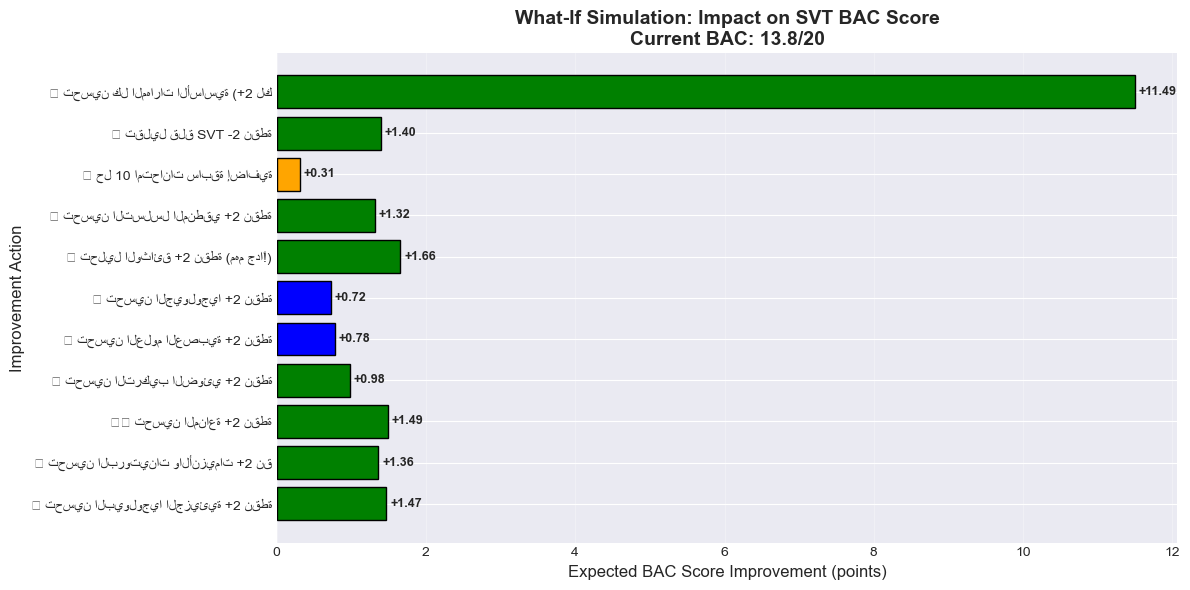


📊 جدول تأثير تحسين العادات الدراسية - SVT
             العادة الدراسية التحسن المتوقع
تحسين البيولوجيا الجزيئية +2     +1.47 نقطة
         تحسين البروتينات +2     +1.36 نقطة
            تحسين المناعة +2     +1.49 نقطة
     تحليل الوثائق +2 (مهم!)     +1.66 نقطة
    تحسين التسلسل المنطقي +2     +1.32 نقطة
        حل 10 امتحانات سابقة     +0.31 نقطة
            تقليل قلق SVT -2     +1.40 نقطة

💡 نصيحة خاصة لمادة علوم الطبيعة والحياة (SVT):
   • تحليل الوثائق هو المهارة الأكثر أهمية - ركز عليها بشدة!
   • البيولوجيا الجزيئية، البروتينات، والمناعة لها نفس الأهمية
   • حل امتحانات سابقة يرفع نقطتك بمقدار 0.4 نقطة لكل 10 امتحانات
   • الجيولوجيا تأتي أقل في البكالوريا - ركز على الأساسيات
   • SVT يختبر التفكير المنطقي وليس الحفظ فقط!

✅ Simulation Engine Complete


In [15]:
# ============================================
# CELL 15: SIMULATION ENGINE - SVT BAC
# Based on correlations from your data
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 60)
print("SIMULATION ENGINE - SVT BAC")
print("How improving study habits affects your SVT BAC score")
print("Based on correlations from our dataset")
print("=" * 60)

# ============================================
# Step 1: Calculate average effects from correlations
# ============================================

# Get correlations with BAC score
bac_corr = df.corr()['bac_score_svt']

# Extract key correlations
molecular_corr = bac_corr.get('molecular_biology', 0.58)
protein_corr = bac_corr.get('protein_enzymes', 0.58)
immunity_corr = bac_corr.get('immunology', 0.58)
energy_corr = bac_corr.get('energy_photosynthesis', 0.48)
neuroscience_corr = bac_corr.get('neuroscience', 0.38)
geology_corr = bac_corr.get('geology', 0.33)
document_corr = bac_corr.get('document_analysis', 0.55)
reasoning_corr = bac_corr.get('reasoning_chain', 0.48)
writing_corr = bac_corr.get('scientific_writing', 0.45)
hypothesis_corr = bac_corr.get('hypothesis_formulation', 0.48)
exam_corr = bac_corr.get('bac_exams_practiced', 0.38)
anxiety_corr = bac_corr.get('svt_anxiety', -0.38)
document_confidence_corr = bac_corr.get('document_confidence', 0.35)

print(f"\n📊 Real correlations from your data:")
print(f"   molecular_biology → BAC: {molecular_corr:.3f}")
print(f"   protein_enzymes → BAC: {protein_corr:.3f}")
print(f"   immunology → BAC: {immunity_corr:.3f}")
print(f"   document_analysis → BAC: {document_corr:.3f}")
print(f"   reasoning_chain → BAC: {reasoning_corr:.3f}")
print(f"   bac_exams_practiced → BAC: {exam_corr:.3f}")
print(f"   svt_anxiety → BAC: {anxiety_corr:.3f}")

# Scale factors (GLOBAL for later use)
scale_factors = {
    'molecular_biology': molecular_corr * 1.2,
    'protein_enzymes': protein_corr * 1.2,
    'immunology': immunity_corr * 1.2,
    'energy_photosynthesis': energy_corr * 1.0,
    'energy_respiration': energy_corr * 1.0,
    'neuroscience': neuroscience_corr * 1.0,
    'geology': geology_corr * 1.0,
    'document_analysis': document_corr * 1.5,        # CRITICAL for SVT!
    'reasoning_chain': reasoning_corr * 1.3,
    'hypothesis_formulation': hypothesis_corr * 1.2,
    'scientific_writing': writing_corr * 1.2,
    'bac_exams_practiced': exam_corr * 0.8,          # points per +10 exams
    'svt_anxiety': -anxiety_corr * 1.5               # reducing anxiety helps
}

print(f"\n📊 Impact per +2 skill points (Biology focus):")
print(f"   molecular_biology: +{scale_factors['molecular_biology']*2:.2f} points")
print(f"   protein_enzymes: +{scale_factors['protein_enzymes']*2:.2f} points")
print(f"   immunology: +{scale_factors['immunology']*2:.2f} points")
print(f"   document_analysis: +{scale_factors['document_analysis']*2:.2f} points (CRITICAL!)")

# ============================================
# Step 2: Find a representative student
# ============================================

avg_bac = df['bac_score_svt'].mean()
target_student = df.iloc[(df['bac_score_svt'] - avg_bac).abs().argsort()[:1]].iloc[0]

# Get stream
target_stream = 'Sciences' if 'stream_encoded' not in target_student.index else ('Sciences' if target_student.get('stream_encoded', 0) == 0 else 'Maths')

print(f"\n👤 Selected student (average profile from {target_stream}):")
print(f"   Current SVT BAC score: {target_student['bac_score_svt']:.1f}")
print(f"   Molecular Biology: {target_student.get('molecular_biology', 5):.1f}/10")
print(f"   Immunology: {target_student.get('immunology', 5):.1f}/10")
print(f"   Document Analysis: {target_student.get('document_analysis', 5):.1f}/10")
print(f"   Reasoning Chain: {target_student.get('reasoning_chain', 5):.1f}/10")
print(f"   Bac exams practiced: {target_student.get('bac_exams_practiced', 5):.0f}/30")
print(f"   SVT Anxiety: {target_student.get('svt_anxiety', 5):.1f}/10")

# ============================================
# Step 3: Simulation function
# ============================================

def simulate_improvement(student, improvements):
    """
    Simulate BAC improvement based on correlation coefficients
    """
    original_score = student['bac_score_svt']
    gain = 0
    
    for feature, delta in improvements.items():
        if feature in scale_factors:
            if feature == 'bac_exams_practiced':
                gain += (delta / 10) * scale_factors[feature]
            elif feature == 'svt_anxiety':
                gain += (-delta) * scale_factors[feature]
            else:
                gain += delta * scale_factors[feature]
    
    new_score = min(original_score + gain, 20)
    new_score = max(new_score, 0)
    
    return {
        'original_score': original_score,
        'new_score': new_score,
        'gain': gain,
        'improvements': improvements
    }

# ============================================
# Step 4: Test different scenarios
# ============================================

scenarios = [
    {"name": "🧬 تحسين البيولوجيا الجزيئية +2 نقطة", "changes": {"molecular_biology": 2}},
    {"name": "🧫 تحسين البروتينات والأنزيمات +2 نقطة", "changes": {"protein_enzymes": 2}},
    {"name": "🛡️ تحسين المناعة +2 نقطة", "changes": {"immunology": 2}},
    {"name": "🌿 تحسين التركيب الضوئي +2 نقطة", "changes": {"energy_photosynthesis": 2}},
    {"name": "🧠 تحسين العلوم العصبية +2 نقطة", "changes": {"neuroscience": 2}},
    {"name": "🌍 تحسين الجيولوجيا +2 نقطة", "changes": {"geology": 2}},
    {"name": "📄 تحليل الوثائق +2 نقطة (مهم جداً!)", "changes": {"document_analysis": 2}},
    {"name": "🔗 تحسين التسلسل المنطقي +2 نقطة", "changes": {"reasoning_chain": 2}},
    {"name": "📝 حل 10 امتحانات سابقة إضافية", "changes": {"bac_exams_practiced": 10}},
    {"name": "🧘 تقليل قلق SVT -2 نقطة", "changes": {"svt_anxiety": -2}},
    {"name": "✨ تحسين كل المهارات الأساسية (+2 لكل فرع)", "changes": {
        "molecular_biology": 2, "protein_enzymes": 2, "immunology": 2,
        "energy_photosynthesis": 2, "neuroscience": 2, "geology": 2,
        "document_analysis": 2, "reasoning_chain": 2,
        "bac_exams_practiced": 10, "svt_anxiety": -2
    }}
]

print(f"\n📈 SIMULATION RESULTS (for {target_stream} stream):")
print("-" * 60)

results = []
for scenario in scenarios:
    result = simulate_improvement(target_student, scenario["changes"])
    results.append(result)
    
    # Color code based on gain
    if result['gain'] > 0.8:
        symbol = "🟢"
    elif result['gain'] > 0.4:
        symbol = "🔵"
    else:
        symbol = "⚪"
    
    print(f"\n{symbol} {scenario['name']}:")
    print(f"   {result['original_score']:.1f} → {result['new_score']:.1f}")
    print(f"   📈 التحسن: +{result['gain']:.2f} نقطة")

# ============================================
# Step 5: Best action recommendation
# ============================================

print("\n" + "=" * 60)
print("🎯 أفضل طريقة للتحسين - SVT")
print("=" * 60)

best_gain = max([r['gain'] for r in results[:-1]])  # Exclude combined
best_scenario = scenarios[[r['gain'] for r in results[:-1]].index(best_gain)]

print(f"\n✅ {best_scenario['name']}")
print(f"   → تحسن متوقع: +{best_gain:.2f} نقطة في البكالوريا")

# ============================================
# Step 6: Visualization
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

scenario_names = [s["name"][:35] for s in scenarios]
gains = [r['gain'] for r in results]

colors = ['green' if g > 0.8 else 'blue' if g > 0.4 else 'orange' if g > 0.1 else 'gray' for g in gains]
bars = ax.barh(scenario_names, gains, color=colors, edgecolor='black')

ax.set_xlabel('Expected BAC Score Improvement (points)', fontsize=12)
ax.set_ylabel('Improvement Action', fontsize=12)
ax.set_title(f'What-If Simulation: Impact on SVT BAC Score\nCurrent BAC: {target_student["bac_score_svt"]:.1f}/20', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, gain in zip(bars, gains):
    if gain > 0:
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
                f'+{gain:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# Step 7: Summary table
# ============================================

print("\n" + "=" * 60)
print("📊 جدول تأثير تحسين العادات الدراسية - SVT")
print("=" * 60)

impact_table = pd.DataFrame({
    'العادة الدراسية': [
        'تحسين البيولوجيا الجزيئية +2',
        'تحسين البروتينات +2',
        'تحسين المناعة +2',
        'تحليل الوثائق +2 (مهم!)',
        'تحسين التسلسل المنطقي +2',
        'حل 10 امتحانات سابقة',
        'تقليل قلق SVT -2'
    ],
    'التحسن المتوقع': [
        f'+{scale_factors["molecular_biology"]*2:.2f} نقطة',
        f'+{scale_factors["protein_enzymes"]*2:.2f} نقطة',
        f'+{scale_factors["immunology"]*2:.2f} نقطة',
        f'+{scale_factors["document_analysis"]*2:.2f} نقطة',
        f'+{scale_factors["reasoning_chain"]*2:.2f} نقطة',
        f'+{scale_factors["bac_exams_practiced"]:.2f} نقطة',
        f'+{scale_factors["svt_anxiety"]*2:.2f} نقطة'
    ]
})

print(impact_table.to_string(index=False))

print("\n💡 نصيحة خاصة لمادة علوم الطبيعة والحياة (SVT):")
print("   • تحليل الوثائق هو المهارة الأكثر أهمية - ركز عليها بشدة!")
print("   • البيولوجيا الجزيئية، البروتينات، والمناعة لها نفس الأهمية")
print("   • حل امتحانات سابقة يرفع نقطتك بمقدار 0.4 نقطة لكل 10 امتحانات")
print("   • الجيولوجيا تأتي أقل في البكالوريا - ركز على الأساسيات")
print("   • SVT يختبر التفكير المنطقي وليس الحفظ فقط!")

print("\n" + "=" * 60)
print("✅ Simulation Engine Complete")
print("=" * 60)

In [16]:
# ============================================
# CELL 16: STUDENT-FRIENDLY FEATURE EXPLANATIONS - SVT
# ============================================

import pandas as pd
import numpy as np

print("=" * 60)
print("📖 فهم نتائجك في علوم الطبيعة والحياة (SVT)")
print("شرح بسيط لكل مهارة تؤثر على نقطتك")
print("=" * 60)

# ============================================
# Create a sample student profile
# ============================================

sample_student = df.iloc[50]
# Get the original stream name (decode from encoded value)
stream_map = {0: 'Sciences', 1: 'Maths'}
student_stream = stream_map.get(int(sample_student.get('stream_encoded', 0)), 'Sciences')

print(f"\n👤 ملف الطالب:")
print(f"   الشعبة: {student_stream}")
print(f"   النقطة المتوقعة في البكالوريا: {sample_student['bac_score_svt']:.1f}/20")
print(f"   معدل الفصول الثلاثة: {sample_student['svt_avg_grade']:.1f}/20")
print("\n" + "-" * 60)

# ============================================
# Explain SVT chapters
# ============================================

print("\n📚 فصول مادة علوم الطبيعة والحياة:")
print("-" * 60)

chapters_to_explain = [
    ('molecular_biology', '🧬 البيولوجيا الجزيئية (DNA، ARN، التركيب البروتيني)',
     'ركز على تضاعف DNA، النسخ، الترجمة، والشفرة الوراثية'),
    ('protein_enzymes', '🧫 البروتينات والأنزيمات (البنية، الوظيفة، التحفيز)',
     'تدرب على العلاقة بين بنية البروتين ووظيفته وآلية عمل الأنزيمات'),
    ('immunology', '🛡️ المناعة (HLA، الأجسام المضادة، LT4، LT8، HIV)',
     'راجع نظام التعرف على الذات واللاذات، وتفاعلات المناعة الخلوية والخلطية'),
    ('energy_photosynthesis', '🌿 التركيب الضوئي (التفاعلات الضوئية، دورة كالفن)',
     'تدرب على مراحل تحويل الطاقة الضوئية إلى طاقة كيميائية'),
    ('energy_respiration', '🔥 التنفس الخلوي (هدم الغلوكوز، ATP)',
     'راجع مراحل تحويل الطاقة الكيميائية إلى ATP'),
    ('neuroscience', '🧠 العلوم العصبية (النقل المشبكي، النواقل العصبية)',
     'تدرب على آلية انتقال السيالة العصبية عبر المشبك'),
    ('geology', '🌍 الجيولوجيا (الصفائح التكتونية، الغوص، الزلازل)',
     'راجع حركات الصفائح والبنية الداخلية للأرض')
]

for skill, name, advice in chapters_to_explain:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# ============================================
# Explain scientific skills (CRITICAL for SVT!)
# ============================================

print("\n" + "=" * 60)
print("🔬 المهارات العلمية (الأهم في SVT!)")
print("=" * 60)

scientific_skills = [
    ('document_analysis', '📄 تحليل الوثائق (منحنيات، جداول، تجارب)',
     'هذه أهم مهارة في البكالوريا! تدرب على قراءة واستخراج المعلومات من الوثائق'),
    ('hypothesis_formulation', '🔬 اقتراح الفرضيات',
     'حلل النتائج واقترح تفسيرات علمية منطقية'),
    ('scientific_writing', '✍️ الكتابة العلمية',
     'نظم إجاباتك بمقدمة وعرض وخاتمة واستخدم المصطلحات العلمية الدقيقة'),
    ('reasoning_chain', '🔗 التسلسل المنطقي (السبب والنتيجة)',
     'ربط الأسباب بالنتائج في سلاسل منطقية متسلسلة')
]

for skill, name, advice in scientific_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# ============================================
# Explain psychological factors
# ============================================

print("\n" + "=" * 60)
print("🧠 العوامل النفسية وتأثيرها على أدائك")
print("=" * 60)

psycho_factors = [
    ('svt_anxiety', '😰 قلق مادة علوم الطبيعة والحياة',
     'القلق يخفض نقطتك. ابدأ بتمارين سهلة وزد الصعوبة تدريجياً', True),
    ('document_confidence', '💪 الثقة في تحليل الوثائق',
     'الثقة في قراءة المنحنيات والجداول ترفع نقطتك', False),
    ('scientific_writing_confidence', '✍️ الثقة في الكتابة العلمية',
     'الثقة في تنظيم الإجابات تحسن أدائك', False)
]

for factor, name, advice, is_negative in psycho_factors:
    if factor in df.columns:
        value = sample_student[factor]
        if is_negative:
            if value <= 3:
                level = "🟢 ممتاز (منخفض)"
            elif value <= 6:
                level = "🟡 متوسط"
            else:
                level = "🔴 مرتفع (يؤثر سلباً)"
        else:
            if value >= 7:
                level = "🟢 ممتاز"
            elif value >= 5:
                level = "🟡 متوسط"
            else:
                level = "🔴 منخفض (يحتاج تحسين)"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# ============================================
# Explain study habits
# ============================================

print("\n" + "=" * 60)
print("📖 عادات الدراسة وتأثيرها على نقطتك")
print("=" * 60)

study_habits = [
    ('bac_exams_practiced', '📚 عدد امتحانات البكالوريا التي حللتها', 30),
    ('document_exercises', '📊 عدد تمارين تحليل الوثائق التي حللتها', 15),
    ('practice_intensity', '⚡ كثافة التمارين (مقياس مركب)', 10)
]

for habit, name, max_val in study_habits:
    if habit in df.columns:
        value = sample_student[habit]
        percentage = (value / max_val) * 100
        
        if percentage >= 70:
            level = "🟢 ممتاز"
        elif percentage >= 50:
            level = "🟡 جيد"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.0f}/{max_val}")
        print(f"   → مستواك: {level} ({percentage:.0f}%)")
        
        if habit == 'bac_exams_practiced' and value < 10:
            print(f"   💡 نصيحة: حاول حل {10 - value:.0f} امتحان إضافي")
        elif habit == 'document_exercises' and value < 8:
            print(f"   💡 نصيحة: ارفع عدد تمارين تحليل الوثائق إلى 8-10 أسبوعياً")

# ============================================
# Derived features explanation
# ============================================

print("\n" + "=" * 60)
print("📊 مؤشرات مركبة (مشتقة من مهاراتك)")
print("=" * 60)

derived_features = [
    ('scientific_skills_composite', '🔬 المستوى العلمي العام',
     'متوسط مهاراتك في تحليل الوثائق واقتراح الفرضيات والكتابة العلمية'),
    ('document_mastery', '📄 إتقان تحليل الوثائق',
     'قدرتك على قراءة واستخراج المعلومات من المنحنيات والجداول والتجارب'),
    ('reasoning_quality', '🧠 جودة الاستدلال',
     'قدرتك على بناء سلاسل منطقية تربط الأسباب بالنتائج'),
    ('psychological_health', '🧠 الصحة النفسية',
     'مدى ثقتك وتقليل قلقك في SVT'),
    ('study_quality', '📚 جودة الدراسة',
     'مدى استعدادك من خلال حل الامتحانات وتمارين الوثائق'),
    ('bio_geo_balance', '⚖️ التوازن بين البيولوجيا والجيولوجيا',
     'الفرق بين مستواك في البيولوجيا والجيولوجيا - كلما كان الفرق أصغر كان أفضل'),
    ('imbalance_score', '⚖️ توازن المهارات العام',
     'مدى توازن مهاراتك بين جميع فروع SVT')
]

for feature, name, description in derived_features:
    if feature in df.columns:
        value = sample_student[feature]
        if value >= 7:
            level = "🟢 ممتاز"
        elif value >= 5:
            level = "🟡 جيد"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   🤔 ماذا يعني؟ {description}")

# ============================================
# Final summary
# ============================================

print("\n" + "=" * 60)
print("🎯 ملخص وتوصيات مخصصة لك")
print("=" * 60)

print(f"\n🔹 شعبتك: {student_stream}")

# Identify strongest and weakest skill
skill_values = {}
for skill, name, _ in chapters_to_explain:
    if skill in df.columns:
        skill_values[name] = sample_student[skill]

if skill_values:
    weakest = min(skill_values, key=skill_values.get)
    strongest = max(skill_values, key=skill_values.get)
    
    print(f"\n🔴 أضعف فصل لديك: {weakest}")
    print(f"🟢 أقوى فصل لديك: {strongest}")

print(f"\n📋 توصيات للتحسين:")

recommendations = []

# Chapter recommendations
if 'molecular_biology' in df.columns and sample_student['molecular_biology'] < 6:
    recommendations.append("• 🧬 **البيولوجيا الجزيئية:** راجع تضاعف DNA والنسخ والترجمة")
if 'immunology' in df.columns and sample_student['immunology'] < 6:
    recommendations.append("• 🛡️ **المناعة:** راجع HLA، TAP، الأجسام المضادة، والخلايا LT4 و LT8")
if 'protein_enzymes' in df.columns and sample_student['protein_enzymes'] < 6:
    recommendations.append("• 🧫 **البروتينات:** راجع بنية البروتين وآلية عمل الأنزيمات")

# Scientific skills recommendations (MOST IMPORTANT!)
if 'document_analysis' in df.columns and sample_student['document_analysis'] < 6:
    recommendations.append("• 📄 **تحليل الوثائق:** تدرب على قراءة المنحنيات والجداول والتجارب - هذه أهم مهارة!")
if 'reasoning_chain' in df.columns and sample_student['reasoning_chain'] < 6:
    recommendations.append("• 🔗 **التسلسل المنطقي:** تدرب على بناء سلاسل سبب-نتيجة منطقية")
if 'scientific_writing' in df.columns and sample_student['scientific_writing'] < 6:
    recommendations.append("• ✍️ **الكتابة العلمية:** نظم إجاباتك بمقدمة وعرض وخاتمة")

# Practice recommendations
if 'bac_exams_practiced' in df.columns and sample_student['bac_exams_practiced'] < 10:
    recommendations.append("• 📝 **الامتحانات السابقة:** حل 10 امتحانات بكالوريا على الأقل")
if 'document_exercises' in df.columns and sample_student['document_exercises'] < 8:
    recommendations.append("• 📊 **تمارين الوثائق:** حل تمارين متنوعة لتحليل الوثائق")

# Geological recommendations
if 'geology' in df.columns and sample_student['geology'] < 4.5:
    recommendations.append("• 🌍 **الجيولوجيا:** ركز على الأساسيات فقط (الصفائح التكتونية، الغوص)")

# Psychological recommendations
if 'svt_anxiety' in df.columns and sample_student['svt_anxiety'] > 6:
    recommendations.append("• 🧘 **قلق المادة:** ابدأ بتمارين سهلة وزد الصعوبة تدريجياً")

for rec in recommendations[:7]:
    print(f"   {rec}")

if not recommendations:
    print("   ✅ أنت على الطريق الصحيح! استمر بنفس المستوى")

print("\n" + "=" * 60)
print("✅ تذكر: SVT يختبر التفكير المنطقي وتحليل الوثائق وليس الحفظ فقط!")
print(f"   نقطتك الحالية: {sample_student['bac_score_svt']:.1f}/20")
print("   مع الالتزام بالنصائح أعلاه، يمكنك رفع نقطتك بمقدار 2-3 نقاط")
print("=" * 60)

📖 فهم نتائجك في علوم الطبيعة والحياة (SVT)
شرح بسيط لكل مهارة تؤثر على نقطتك

👤 ملف الطالب:
   الشعبة: Maths
   النقطة المتوقعة في البكالوريا: 15.8/20
   معدل الفصول الثلاثة: 17.5/20

------------------------------------------------------------

📚 فصول مادة علوم الطبيعة والحياة:
------------------------------------------------------------

🧬 البيولوجيا الجزيئية (DNA، ARN، التركيب البروتيني): 7.9/10
   → مستواك: 🟢 قوي
   💡 نصيحة: ركز على تضاعف DNA، النسخ، الترجمة، والشفرة الوراثية

🧫 البروتينات والأنزيمات (البنية، الوظيفة، التحفيز): 7.6/10
   → مستواك: 🟢 قوي
   💡 نصيحة: تدرب على العلاقة بين بنية البروتين ووظيفته وآلية عمل الأنزيمات

🛡️ المناعة (HLA، الأجسام المضادة، LT4، LT8، HIV): 8.7/10
   → مستواك: 🟢 قوي
   💡 نصيحة: راجع نظام التعرف على الذات واللاذات، وتفاعلات المناعة الخلوية والخلطية

🌿 التركيب الضوئي (التفاعلات الضوئية، دورة كالفن): 5.7/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: تدرب على مراحل تحويل الطاقة الضوئية إلى طاقة كيميائية

🔥 التنفس الخلوي (هدم الغلوكوز، ATP): 6.6/10
   → مستواك

In [19]:
# ============================================
# CELL 17a: INTRODUCTION + BAC EXAM STRUCTURE (PROFESSIONAL) - SVT
# UPDATED: Sciences Exp. (4h30 - all topics)
#          Maths (2h30 - DNA/RNA + Proteins + Immunology only)
# ============================================

from IPython.display import display, HTML

print("=" * 80)
print("🔬 منصة تحسين الأداء في علوم الطبيعة والحياة - البكالوريا الجزائرية")
print("=" * 80)

# Create professional HTML layout
intro_html = """
<div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">

    <!-- Header Section -->
    <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                color: white; padding: 30px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
        <h1 style="margin: 0; font-size: 28px;">🔬 امتحان البكالوريا - علوم الطبيعة والحياة</h1>
        <p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.9;">الشعب: علوم تجريبية، رياضيات</p>
    </div>

    <!-- Quick Stats -->
    <div style="display: flex; gap: 15px; margin-bottom: 25px; flex-wrap: wrap;">
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #3498db;">
            <div style="font-size: 35px;">⏱️</div>
            <div style="font-size: 20px; font-weight: bold;">المدة (علوم تجريبية)</div>
            <div style="font-size: 14px;">4 ساعات و30 دقيقة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #2ecc71;">
            <div style="font-size: 35px;">⏱️</div>
            <div style="font-size: 20px; font-weight: bold;">المدة (رياضيات)</div>
            <div style="font-size: 14px;">2 ساعات و30 دقيقة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #e74c3c;">
            <div style="font-size: 35px;">📊</div>
            <div style="font-size: 20px; font-weight: bold;">مجموع النقاط</div>
            <div style="font-size: 14px;">20 نقطة</div>
        </div>
    </div>

    <!-- Exam Structure Title -->
    <div style="background: #2c3e50; color: white; padding: 12px 20px; border-radius: 8px; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px;">📋 هيكل امتحان البكالوريا في علوم الطبيعة والحياة</h2>
    </div>
"""

# Exam structure by stream
stream_structure = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #3498db;">
        <h3 style="color: #2c3e50; margin-top: 0;">🔬 شعبة علوم تجريبية (4سا 30د)</h3>
        <p style="color: #666; font-size: 12px;">جميع الفصول: البيولوجيا الجزيئية، البروتينات، المناعة، تحويل الطاقة، العلوم العصبية، الجيولوجيا</p>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #3498db; color: white;">
                <th style="padding: 10px; text-align: center;">التمرين</th>
                <th style="padding: 10px; text-align: center;">المحتوى</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>التمرين الأول</strong></td>
                <td style="padding: 10px;">البيولوجيا الجزيئية (DNA، ARN) + البروتينات (البنية، الأنزيمات)</td>
                <td style="padding: 10px; text-align: center;">5-6 نقاط</td>
            </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>التمرين الثاني</strong></td>
                <td style="padding: 10px;">المناعة (HLA، TAP، الأجسام المضادة، LT4، LT8، HIV)</td>
                <td style="padding: 10px; text-align: center;">7-8 نقاط</td>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>التمرين الثالث</strong></td>
                <td style="padding: 10px;">تحويل الطاقة (التركيب الضوئي + التنفس الخلوي) + العلوم العصبية</td>
                <td style="padding: 10px; text-align: center;">7-8 نقاط</td>
            </tr>
            <tr style="background: #f0f8ff;">
                <td style="padding: 10px;"><strong>التمرين الرابع</strong></td>
                <td style="padding: 10px;">الجيولوجيا (الصفائح التكتونية، الغوص، الزلازل، البراكين)</td>
                <td style="padding: 10px; text-align: center;">8 نقاط</td>
            </tr>
        </table>
    </div>
    
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #2ecc71;">
        <h3 style="color: #2c3e50; margin-top: 0;">📐 شعبة رياضيات (2سا 30د)</h3>
        <p style="color: #e67e22; font-size: 12px;">⚠️ فقط ثلاثة فصول: البيولوجيا الجزيئية (DNA/RNA) + البروتينات + المناعة</p>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #2ecc71; color: white;">
                <th style="padding: 10px; text-align: center;">التمرين</th>
                <th style="padding: 10px; text-align: center;">المحتوى</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>التمرين الأول</strong></td>
                <td style="padding: 10px;">البيولوجيا الجزيئية (DNA، ARN، تضاعف، نسخ، ترجمة) + البروتينات (البنية، الأنزيمات)</td>
                <td style="padding: 10px; text-align: center;">10-11 نقاط</td>
            </tr>
            <tr style="background: #f0f8ff;">
                <td style="padding: 10px;"><strong>التمرين الثاني</strong></td>
                <td style="padding: 10px;">المناعة (HLA، TAP، الأجسام المضادة، LT4، LT8)</td>
                <td style="padding: 10px; text-align: center;">9-10 نقاط</td>
            </tr>
        </table>
        <p style="color: #666; font-size: 12px; margin-top: 10px;">📌 لا تشمل: تحويل الطاقة، العلوم العصبية، الجيولوجيا</p>
    </div>
"""

# Importance by topic
importance_html = """
    <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #ffc107;">
        <h3 style="color: #856404; margin-top: 0;">🎯 المهارات الأكثر أهمية في SVT</h3>
        <div style="display: flex; gap: 15px; flex-wrap: wrap;">
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e74c3c; font-size: 24px;">🔴</div>
                <div><strong>المناعة + البيولوجيا الجزيئية + البروتينات</strong></div>
                <div style="font-size: 12px; color: #666;">الأكثر أهمية (0.60)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e67e22; font-size: 24px;">🟠</div>
                <div><strong>تحليل الوثائق</strong></div>
                <div style="font-size: 12px; color: #666;">مهم جداً (0.55)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #f1c40f; font-size: 24px;">🟡</div>
                <div><strong>تحويل الطاقة (لشعبة العلوم فقط)</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير متوسط (0.50)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #2ecc71; font-size: 24px;">🟢</div>
                <div><strong>الجيولوجيا (لشعبة العلوم فقط)</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير أقل (0.35)</div>
            </div>
        </div>
    </div>
"""

# Critical note about document analysis
document_note = """
    <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #9b59b6;">
        <h3 style="color: #4a148c; margin-top: 0;">📄 ملاحظة مهمة حول امتحان SVT</h3>
        <p style="line-height: 1.6;">
            • <strong>تحليل الوثائق</strong> هو المهارة الأكثر أهمية - 40% من النقاط تعتمد على قراءة المنحنيات والجداول<br>
            • <strong>SVT ليس مادة حفظ فقط</strong> - يختبر التفكير المنطقي والاستدلال العلمي<br>
            • <strong>المناعة والبيولوجيا الجزيئية والبروتينات</strong> تمثلان الجزء الأكبر من الامتحان لكلا الشعبتين<br>
            • <strong>شعبة الرياضيات</strong> تدرس فقط: DNA/RNA + البروتينات + المناعة (بدون طاقة أو جيولوجيا)<br>
            • <strong>الكتابة العلمية المنظمة</strong> (مقدمة، عرض، خاتمة) ترفع نقطتك
        </p>
    </div>
"""

# How the platform works
how_it_works = """
    <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #1abc9c;">
        <h3 style="color: #0e6655; margin-top: 0;">💡 كيف تعمل هذه المنصة؟</h3>
        <ul style="line-height: 1.8;">
            <li>🎓 <strong>اختر شعبتك</strong> - علوم تجريبية أو رياضيات</li>
            <li>📝 <strong>أدخل معلوماتك</strong> - درجاتك ومستويات مهاراتك</li>
            <li>🔮 <strong>توقع نتيجتك</strong> - سنقوم بحساب نقطتك المتوقعة في البكالوريا</li>
            <li>📊 <strong>تحليل نقاط القوة والضعف</strong> - سنحدد الفصول التي تحتاج إلى تحسين</li>
            <li>⚡ <strong>محاكاة التحسين</strong> - جرب تغيير عاداتك الدراسية وشاهد كيف تتغير نتيجتك</li>
        </ul>
    </div>
"""

# Combine all
full_html = intro_html + stream_structure + importance_html + document_note + how_it_works + """
    <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
        <p style="color: #555; margin: 0;">✨ هذه المنصة تعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة في علوم الطبيعة والحياة ✨</p>
        <p style="color: #888; font-size: 12px;">تم تطوير هذه المنصة لمساعدة طلاب البكالوريا على تحسين أدائهم في SVT</p>
        <p style="color: #888; font-size: 12px;">🔬 تذكر: تحليل الوثائق والتفكير المنطقي هما مفتاح النجاح في SVT 🔬</p>
    </div>
</div>
"""

display(HTML(full_html))

print("\n" + "=" * 80)
print("✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)")
print("=" * 80)

🔬 منصة تحسين الأداء في علوم الطبيعة والحياة - البكالوريا الجزائرية


التمرين,المحتوى,النقاط
التمرين الأول,البيولوجيا الجزيئية (DNA، ARN) + البروتينات (البنية، الأنزيمات),5-6 نقاط
التمرين الثاني,المناعة (HLA، TAP، الأجسام المضادة، LT4، LT8، HIV),7-8 نقاط
التمرين الثالث,تحويل الطاقة (التركيب الضوئي + التنفس الخلوي) + العلوم العصبية,7-8 نقاط
التمرين الرابع,الجيولوجيا (الصفائح التكتونية، الغوص، الزلازل، البراكين),8 نقاط
التمرين,المحتوى,النقاط
التمرين الأول,البيولوجيا الجزيئية (DNA، ARN، تضاعف، نسخ، ترجمة) + البروتينات (البنية، الأنزيمات),10-11 نقاط
التمرين الثاني,المناعة (HLA، TAP، الأجسام المضادة، LT4، LT8),9-10 نقاط



✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)


In [21]:
# ============================================
# CELL 17b: USER INPUT FORM (PROFESSIONAL) - SVT BAC
# With DYNAMIC specialty selection (Sciences Exp. vs Maths)
# Maths stream: ONLY molecular_biology + protein_enzymes + immunology
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

print("=" * 80)
print("📝 إدخال بيانات الطالب - علوم الطبيعة والحياة (SVT)")
print("=" * 80)

# Create professional HTML header
form_header = """
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
            color: white; padding: 20px; border-radius: 10px; margin-bottom: 25px; text-align: center;">
    <h2 style="margin: 0;">📋 أدخل معلوماتك الدراسية</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">اختر شعبتك أولاً ثم قم بتعبئة المهارات الخاصة بك</p>
</div>
"""
display(HTML(form_header))

# ============================================
# SECTION 1: Stream Selection (Filiere)
# ============================================

stream_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 4px solid #3498db;">
    <h3 style="color: #2c3e50; margin-top: 0;">🎓 1. اختر شعبتك الدراسية</h3>
    <p style="color: #666; font-size: 14px;">ملاحظة: تختلف المواد حسب الشعبة</p>
</div>
"""
display(HTML(stream_html))

stream_dropdown = widgets.Dropdown(
    options=[
        ('🔬 علوم تجريبية (جميع الفصول - 4سا 30د)', 'Sciences'),
        ('📐 رياضيات (DNA/RNA + بروتينات + مناعة فقط - 2سا 30د)', 'Maths')
    ],
    value='Sciences',
    description='',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='100%', padding='10px')
)
display(stream_dropdown)

# ============================================
# SECTION 2: Trimester Grades (All streams)
# ============================================

grades_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #2ecc71;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 2. معدلات الفصول الثلاثة</h3>
    <p style="color: #666; font-size: 14px;">أدخل معدلاتك في مادة علوم الطبيعة والحياة من 0 إلى 20</p>
</div>
"""
display(HTML(grades_html))

grade_style = widgets.Layout(width='100%', padding='5px')
grade_slider1 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الأول:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider2 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثاني:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider3 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثالث:', 
                                     style={'description_width': '100px'}, layout=grade_style)

grades_box = widgets.HBox([grade_slider1, grade_slider2, grade_slider3], 
                          layout=widgets.Layout(justify_content='space-between'))
display(grades_box)

# ============================================
# SECTION 3: SVT Chapters (DYNAMIC based on stream)
# ============================================

skills_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e74c3c;">
    <h3 style="color: #2c3e50; margin-top: 0;">📚 3. مستوى مهاراتك في SVT</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10 (0 = ضعيف جداً، 10 = ممتاز)</p>
</div>
"""
display(HTML(skills_html))

skill_style = widgets.Layout(width='100%', padding='5px')

# ============================================
# Sciences Exp. Skills (ALL chapters)
# ============================================
sciences_skills = widgets.VBox([
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🧬 البيولوجيا الجزيئية (DNA، ARN، تضاعف، نسخ، ترجمة):', 
                        style={'description_width': '350px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🧫 البروتينات والأنزيمات (بنية، وظيفة، تحفيز):', 
                        style={'description_width': '350px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🛡️ المناعة (HLA، TAP، الأجسام المضادة، LT4، LT8):', 
                        style={'description_width': '350px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🌿 التركيب الضوئي (التفاعلات الضوئية، دورة كالفن):', 
                        style={'description_width': '350px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🔥 التنفس الخلوي (هدم الغلوكوز، إنتاج ATP):', 
                        style={'description_width': '350px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🧠 العلوم العصبية (النقل المشبكي، النواقل العصبية):', 
                        style={'description_width': '350px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🌍 الجيولوجيا (الصفائح التكتونية، الغوص، الزلازل):', 
                        style={'description_width': '350px'}, layout=skill_style)
])

# ============================================
# Maths Stream Skills (ONLY 3 chapters)
# ============================================
maths_skills = widgets.VBox([
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🧬 البيولوجيا الجزيئية (DNA، ARN، تضاعف، نسخ، ترجمة):', 
                        style={'description_width': '350px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🧫 البروتينات والأنزيمات (بنية، وظيفة، تحفيز):', 
                        style={'description_width': '350px'}, layout=skill_style),
    widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                        description='🛡️ المناعة (HLA، TAP، الأجسام المضادة، LT4، LT8):', 
                        style={'description_width': '350px'}, layout=skill_style)
])

# Dynamic skills container
dynamic_skills = widgets.VBox()
dynamic_skills.children = sciences_skills.children  # Default to Sciences

# Function to update skills based on stream
def update_skills(change):
    if stream_dropdown.value == 'Sciences':
        dynamic_skills.children = sciences_skills.children
        skills_info.value = '<p style="color: #3498db;">✅ جميع الفصول: البيولوجيا الجزيئية، البروتينات، المناعة، تحويل الطاقة، العلوم العصبية، الجيولوجيا</p>'
    else:
        dynamic_skills.children = maths_skills.children
        skills_info.value = '<p style="color: #e67e22;">⚠️ شعبة رياضيات: فقط البيولوجيا الجزيئية + البروتينات + المناعة (بدون طاقة، علوم عصبية، جيولوجيا)</p>'

# Info widget to show which skills are included
skills_info = widgets.HTML(value='<p style="color: #3498db;">✅ جميع الفصول: البيولوجيا الجزيئية، البروتينات، المناعة، تحويل الطاقة، العلوم العصبية، الجيولوجيا</p>')
display(skills_info)

stream_dropdown.observe(update_skills, names='value')
display(dynamic_skills)

# ============================================
# SECTION 4: Scientific Skills (All streams - CRITICAL for SVT!)
# ============================================

scientific_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #f39c12;">
    <h3 style="color: #2c3e50; margin-top: 0;">🔬 4. المهارات العلمية (مهمة جداً في SVT!)</h3>
    <p style="color: #666; font-size: 14px;">هذه المهارات هي الأكثر أهمية في امتحان البكالوريا</p>
</div>
"""
display(HTML(scientific_html))

document_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                       description='📄 تحليل الوثائق (منحنيات، جداول، تجارب):', 
                                       style={'description_width': '300px'}, layout=skill_style)
hypothesis_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                         description='🔬 اقتراح الفرضيات والتفسيرات:', 
                                         style={'description_width': '300px'}, layout=skill_style)
writing_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                      description='✍️ الكتابة العلمية المنظمة:', 
                                      style={'description_width': '300px'}, layout=skill_style)
reasoning_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                        description='🔗 التسلسل المنطقي (السبب والنتيجة):', 
                                        style={'description_width': '300px'}, layout=skill_style)

display(document_slider, hypothesis_slider, writing_slider, reasoning_slider)

# ============================================
# SECTION 5: Practice & Preparation (All streams)
# ============================================

practice_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e67e22;">
    <h3 style="color: #2c3e50; margin-top: 0;">📝 5. عادات الدراسة والتمرين</h3>
    <p style="color: #666; font-size: 14px;">أدخل معلومات عن عاداتك الدراسية</p>
</div>
"""
display(HTML(practice_html))

exams_slider = widgets.IntSlider(value=5, min=0, max=30, step=1, 
                                  description='📚 عدد امتحانات البكالوريا التي حللتها:', 
                                  style={'description_width': '300px'}, layout=skill_style)
doc_exercises_slider = widgets.IntSlider(value=5, min=0, max=15, step=1, 
                                          description='📊 عدد تمارين تحليل الوثائق التي حللتها:', 
                                          style={'description_width': '300px'}, layout=skill_style)

display(exams_slider, doc_exercises_slider)

# ============================================
# SECTION 6: Psychological Factors (All streams)
# ============================================

psycho_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 6. العوامل النفسية</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 1 إلى 10</p>
</div>
"""
display(HTML(psycho_html))

anxiety_slider = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, 
                                      description='😰 قلق مادة علوم الطبيعة والحياة (1=لا قلق، 10=قلق شديد):', 
                                      style={'description_width': '350px'}, layout=skill_style)
doc_confidence_slider = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                             description='💪 الثقة في تحليل الوثائق:', 
                                             style={'description_width': '350px'}, layout=skill_style)
writing_confidence_slider = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                                 description='✍️ الثقة في الكتابة العلمية:', 
                                                 style={'description_width': '350px'}, layout=skill_style)

display(anxiety_slider, doc_confidence_slider, writing_confidence_slider)

# ============================================
# SUBMIT BUTTON
# ============================================

print("\n" + "=" * 80)
print("🚀 جاهز لحساب توقع نقطتك؟")
print("=" * 80)

# Create stylish submit button
submit_button = widgets.Button(
    description='🔮 توقع نتيجتي في البكالوريا (SVT)',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='50%', margin='20px auto', padding='10px')
)

submit_button.style.button_color = '#2ecc71'
submit_button.style.font_weight = 'bold'

# Function to collect all inputs
def collect_inputs(b):
    # Clear previous output
    clear_output(wait=True)
    
    # Re-display the form
    display(HTML(form_header))
    display(stream_dropdown)
    display(skills_info)
    display(HTML(grades_html))
    display(grades_box)
    display(HTML(skills_html))
    display(dynamic_skills)
    display(HTML(scientific_html))
    display(document_slider, hypothesis_slider, writing_slider, reasoning_slider)
    display(HTML(practice_html))
    display(exams_slider, doc_exercises_slider)
    display(HTML(psycho_html))
    display(anxiety_slider, doc_confidence_slider, writing_confidence_slider)
    display(submit_button)
    
    # Collect values based on stream
    stream = stream_dropdown.value
    
    # Common skills (for all streams)
    user_input = {
        'stream': stream,
        'svt_grade_t1': grade_slider1.value,
        'svt_grade_t2': grade_slider2.value,
        'svt_grade_t3': grade_slider3.value,
        'svt_avg_grade': (grade_slider1.value + grade_slider2.value + grade_slider3.value) / 3,
        'molecular_biology': dynamic_skills.children[0].value,
        'protein_enzymes': dynamic_skills.children[1].value,
        'immunology': dynamic_skills.children[2].value,
        'document_analysis': document_slider.value,
        'hypothesis_formulation': hypothesis_slider.value,
        'scientific_writing': writing_slider.value,
        'reasoning_chain': reasoning_slider.value,
        'bac_exams_practiced': exams_slider.value,
        'document_exercises': doc_exercises_slider.value,
        'svt_anxiety': anxiety_slider.value,
        'document_confidence': doc_confidence_slider.value,
        'scientific_writing_confidence': writing_confidence_slider.value
    }
    
    # Add Sciences-only skills (will be 0 for Maths stream)
    if stream == 'Sciences':
        user_input['energy_photosynthesis'] = dynamic_skills.children[3].value
        user_input['energy_respiration'] = dynamic_skills.children[4].value
        user_input['neuroscience'] = dynamic_skills.children[5].value
        user_input['geology'] = dynamic_skills.children[6].value
    else:  # Maths stream
        user_input['energy_photosynthesis'] = 0
        user_input['energy_respiration'] = 0
        user_input['neuroscience'] = 0
        user_input['geology'] = 0
    
    # Store in global variable
    global user_input_data
    user_input_data = user_input
    
    print("\n" + "=" * 80)
    print("✅ تم استلام بياناتك بنجاح!")
    print("=" * 80)
    print(f"\n📊 ملخص بياناتك:")
    print(f"   الشعبة: {stream}")
    print(f"   معدل الفصل الأول: {grade_slider1.value}/20")
    print(f"   معدل الفصل الثاني: {grade_slider2.value}/20")
    print(f"   معدل الفصل الثالث: {grade_slider3.value}/20")
    print(f"   مستوى البيولوجيا الجزيئية: {dynamic_skills.children[0].value}/10")
    print(f"   مستوى البروتينات: {dynamic_skills.children[1].value}/10")
    print(f"   مستوى المناعة: {dynamic_skills.children[2].value}/10")
    if stream == 'Sciences':
        print(f"   مستوى التركيب الضوئي: {dynamic_skills.children[3].value}/10")
        print(f"   مستوى التنفس الخلوي: {dynamic_skills.children[4].value}/10")
        print(f"   مستوى العلوم العصبية: {dynamic_skills.children[5].value}/10")
        print(f"   مستوى الجيولوجيا: {dynamic_skills.children[6].value}/10")
    print(f"   مستوى تحليل الوثائق: {document_slider.value}/10 (مهم جداً!)")
    print(f"   قلق المادة: {anxiety_slider.value}/10")
    print(f"   عدد الامتحانات المحلولة: {exams_slider.value}")
    print("\n🔮 انتقل إلى الخلية 17c لرؤية توقع نتيجتك")

# Attach function to button
submit_button.on_click(collect_inputs)

display(submit_button)

print("\n💡 نصيحة: كن صادقاً في تقييم نفسك للحصول على توقع دقيق")
print("💡 تذكر: تحليل الوثائق هو المهارة الأكثر أهمية في SVT!")

📝 إدخال بيانات الطالب - علوم الطبيعة والحياة (SVT)


Dropdown(layout=Layout(padding='10px', width='100%'), options=(('🔬 علوم تجريبية (جميع الفصول - 4سا 30د)', 'Sci…

HTML(value='<p style="color: #3498db;">✅ جميع الفصول: البيولوجيا الجزيئية، البروتينات، المناعة، تحويل الطاقة، …

FloatSlider(value=6.0, description='📄 تحليل الوثائق (منحنيات، جداول، تجارب):', layout=Layout(padding='5px', wi…

FloatSlider(value=6.0, description='🔬 اقتراح الفرضيات والتفسيرات:', layout=Layout(padding='5px', width='100%')…

...

FloatSlider(value=6.0, description='💪 الثقة في تحليل الوثائق:', layout=Layout(padding='5px', width='100%'), ma…

FloatSlider(value=6.0, description='✍️ الثقة في الكتابة العلمية:', layout=Layout(padding='5px', width='100%'),…


🚀 جاهز لحساب توقع نقطتك؟


Button(button_style='success', description='🔮 توقع نتيجتي في البكالوريا (SVT)', icon='check', layout=Layout(ma…


💡 نصيحة: كن صادقاً في تقييم نفسك للحصول على توقع دقيق
💡 تذكر: تحليل الوثائق هو المهارة الأكثر أهمية في SVT!


In [22]:
# ============================================
# CELL 17c: PREDICTION OUTPUT (PROFESSIONAL) - SVT BAC
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("\n📌 يرجى تشغيل الخلية 11 أولاً لتدريب النموذج")
    print("   ثم قم بتشغيل هذه الخلية مرة أخرى")
    print("=" * 80)
elif 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate prediction using the trained model
    # ============================================
    
    # Create a DataFrame from user input
    input_df = pd.DataFrame([user_input_data])
    
    # Add derived features
    input_df['svt_trend'] = input_df['svt_grade_t3'] - input_df['svt_grade_t1']
    
    # Calculate skill blocks
    input_df['molecular_block'] = input_df['molecular_biology']
    input_df['protein_block'] = input_df['protein_enzymes']
    input_df['immune_block'] = input_df['immunology']
    input_df['energy_block'] = (input_df['energy_photosynthesis'] + input_df['energy_respiration']) / 2
    input_df['neuro_block'] = input_df['neuroscience']
    input_df['geology_block'] = input_df['geology']
    
    # Calculate scientific skills composite
    input_df['scientific_skills_composite'] = (input_df['document_analysis'] + 
                                                input_df['hypothesis_formulation'] + 
                                                input_df['scientific_writing'] + 
                                                input_df['reasoning_chain']) / 4
    
    # Calculate practice intensity
    input_df['practice_intensity'] = (input_df['bac_exams_practiced'] / 30 * 10 + 
                                       input_df['document_exercises'] / 15 * 10) / 2
    
    # Calculate psychological health
    input_df['psychological_health'] = (input_df['document_confidence'] + 
                                         input_df['scientific_writing_confidence'] + 
                                         (10 - input_df['svt_anxiety'])) / 3
    
    # Calculate study quality
    input_df['study_quality'] = (input_df['bac_exams_practiced'] / 30 * 10 * 0.6 + 
                                  input_df['document_exercises'] / 15 * 10 * 0.4)
    
    # Calculate document mastery
    input_df['document_mastery'] = (input_df['document_analysis'] + input_df['document_confidence']) / 2
    
    # Calculate reasoning quality
    input_df['reasoning_quality'] = (input_df['reasoning_chain'] + input_df['hypothesis_formulation']) / 2
    
    # Encode stream
    stream_mapping = {'Sciences': 0, 'Maths': 1}
    input_df['stream_encoded'] = stream_mapping[user_input_data['stream']]
    
    # Get the feature names the model was trained on
    model_features = X_train.columns.tolist()
    
    print(f"\n📊 النموذج تم تدريبه على {len(model_features)} ميزة")
    print(f"   شعبتك: {user_input_data['stream']}")
    
    # Ensure all model features exist in input_df
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
    
    # Select only the features the model expects
    X_input = input_df[model_features]
    
    print(f"✅ جاهز للتنبؤ...")
    
    # Make prediction
    predicted_score = model.predict(X_input)[0]
    
    # Calculate success probability (pass = score >= 10)
    success_prob = 1 / (1 + np.exp(-(predicted_score - 10) / 2)) * 100
    
    # Calculate improvement potential
    improvement_potential = (19 - predicted_score) * 0.4
    improvement_potential = max(0.5, min(improvement_potential, 6))
    
    # Stream name mapping
    stream_names = {
        'Sciences': "🔬 علوم تجريبية (4سا 30د)",
        'Maths': "📐 رياضيات (2سا 30د)"
    }
    
    # Determine color based on predicted score
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "ممتاز"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "جيد جداً"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "جيد"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "مقبول"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "يحتاج إلى تحسين"
    
    # Success probability color
    if success_prob >= 80:
        prob_color = "#2ecc71"
    elif success_prob >= 60:
        prob_color = "#f39c12"
    else:
        prob_color = "#e74c3c"
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    # Build skills summary based on stream
    skills_summary = ""
    if user_input_data['stream'] == 'Sciences':
        skills_summary = f"""
                    <div>🧬 البيولوجيا الجزيئية: <strong>{user_input_data['molecular_biology']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['molecular_biology']*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                    <div>🧫 البروتينات والأنزيمات: <strong>{user_input_data['protein_enzymes']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['protein_enzymes']*10}%; height: 5px; background: #e67e22; border-radius: 3px;"></div>
                    </div>
                    <div>🛡️ المناعة: <strong>{user_input_data['immunology']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['immunology']*10}%; height: 5px; background: #f1c40f; border-radius: 3px;"></div>
                    </div>
                    <div>🌿 التركيب الضوئي: <strong>{user_input_data['energy_photosynthesis']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['energy_photosynthesis']*10}%; height: 5px; background: #2ecc71; border-radius: 3px;"></div>
                    </div>
                    <div>🌍 الجيولوجيا: <strong>{user_input_data['geology']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['geology']*10}%; height: 5px; background: #9b59b6; border-radius: 3px;"></div>
                    </div>
        """
    else:
        skills_summary = f"""
                    <div>🧬 البيولوجيا الجزيئية: <strong>{user_input_data['molecular_biology']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['molecular_biology']*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                    <div>🧫 البروتينات والأنزيمات: <strong>{user_input_data['protein_enzymes']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['protein_enzymes']*10}%; height: 5px; background: #e67e22; border-radius: 3px;"></div>
                    </div>
                    <div>🛡️ المناعة: <strong>{user_input_data['immunology']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['immunology']*10}%; height: 5px; background: #f1c40f; border-radius: 3px;"></div>
                    </div>
        """
    
    prediction_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 توقع نقطة البكالوريا - علوم الطبيعة والحياة</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">بناءً على بياناتك الشخصية وشعبتك</p>
        </div>
        
        <!-- Main Score Card -->
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} مستوى {score_text} {score_emoji}
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Score Details -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 تفاصيل النتيجة</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 النقطة المتوقعة</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ فرصة النجاح (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 إمكانية التحسين</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} نقطة</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <!-- Right Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>🎓 الشعبة</span>
                        <span style="font-weight: bold;">{stream_names.get(user_input_data['stream'], user_input_data['stream'])}</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الأول</span>
                        <span style="font-weight: bold;">{user_input_data['svt_grade_t1']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الثاني</span>
                        <span style="font-weight: bold;">{user_input_data['svt_grade_t2']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📅 معدل الفصل الثالث</span>
                        <span style="font-weight: bold;">{user_input_data['svt_grade_t3']:.1f}/20</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Skills Summary -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 ملخص مهاراتك الرئيسية</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 200px;">
                    {skills_summary}
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>📄 تحليل الوثائق: <strong>{user_input_data['document_analysis']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['document_analysis']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>😰 قلق المادة: <strong>{user_input_data['svt_anxiety']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['svt_anxiety']*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                    <div>🔗 التسلسل المنطقي: <strong>{user_input_data['reasoning_chain']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['reasoning_chain']*10}%; height: 5px; background: #27ae60; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Important Note about SVT -->
        <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #f39c12;">
            <h3 style="color: #856404; margin-top: 0;">🔬 ملاحظة مهمة حول SVT</h3>
            <p style="line-height: 1.6;">
                • <strong>تحليل الوثائق</strong> هو المهارة الأكثر أهمية - 40% من النقاط تعتمد عليه<br>
                • <strong>المناعة والبيولوجيا الجزيئية</strong> تمثلان الجزء الأكبر من الامتحان<br>
                • <strong>شعبة الرياضيات</strong> تدرس فقط: DNA/RNA + بروتينات + مناعة (بدون طاقة أو جيولوجيا)<br>
                • <strong>الكتابة العلمية المنظمة</strong> (مقدمة، عرض، خاتمة) ترفع نقطتك
            </p>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ تعديل البيانات
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 تحليل نقاط الضعف →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ هذه النتيجة هي تقدير بناءً على بياناتك الفعلية ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Store prediction for later cells
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف")
    print("=" * 80)


📊 النموذج تم تدريبه على 37 ميزة
   شعبتك: Sciences
✅ جاهز للتنبؤ...



✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف


In [23]:
# ============================================
# CELL 17d: WEAKNESS ANALYSIS (PROFESSIONAL) - SVT BAC
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    stream = user_input_data['stream']
    
    # ============================================
    # Define target levels for each skill based on stream
    # ============================================
    
    # Common targets for all streams
    common_targets = {
        'molecular_biology': 7.0,
        'protein_enzymes': 7.0,
        'immunology': 7.0,
        'document_analysis': 7.0,
        'hypothesis_formulation': 6.5,
        'scientific_writing': 6.5,
        'reasoning_chain': 6.5
    }
    
    # Sciences Exp. specific targets
    if stream == 'Sciences':
        skill_targets = {
            'molecular_biology': 7.0,
            'protein_enzymes': 7.0,
            'immunology': 7.0,
            'energy_photosynthesis': 6.5,
            'energy_respiration': 6.5,
            'neuroscience': 6.0,
            'geology': 5.5,
            **common_targets
        }
        skill_names_ar = {
            'molecular_biology': '🧬 البيولوجيا الجزيئية (DNA، ARN، تضاعف، نسخ، ترجمة)',
            'protein_enzymes': '🧫 البروتينات والأنزيمات (بنية، وظيفة، تحفيز)',
            'immunology': '🛡️ المناعة (HLA، TAP، الأجسام المضادة، LT4، LT8)',
            'energy_photosynthesis': '🌿 التركيب الضوئي (التفاعلات الضوئية، دورة كالفن)',
            'energy_respiration': '🔥 التنفس الخلوي (هدم الغلوكوز، إنتاج ATP)',
            'neuroscience': '🧠 العلوم العصبية (النقل المشبكي، النواقل العصبية)',
            'geology': '🌍 الجيولوجيا (الصفائح التكتونية، الغوص، الزلازل)',
            'document_analysis': '📄 تحليل الوثائق (منحنيات، جداول، تجارب)',
            'hypothesis_formulation': '🔬 اقتراح الفرضيات والتفسيرات',
            'scientific_writing': '✍️ الكتابة العلمية المنظمة',
            'reasoning_chain': '🔗 التسلسل المنطقي (السبب والنتيجة)'
        }
    else:  # Maths stream
        skill_targets = {
            'molecular_biology': 7.0,
            'protein_enzymes': 7.0,
            'immunology': 7.0,
            **common_targets
        }
        skill_names_ar = {
            'molecular_biology': '🧬 البيولوجيا الجزيئية (DNA، ARN، تضاعف، نسخ، ترجمة)',
            'protein_enzymes': '🧫 البروتينات والأنزيمات (بنية، وظيفة، تحفيز)',
            'immunology': '🛡️ المناعة (HLA، TAP، الأجسام المضادة، LT4، LT8)',
            'document_analysis': '📄 تحليل الوثائق (منحنيات، جداول، تجارب)',
            'hypothesis_formulation': '🔬 اقتراح الفرضيات والتفسيرات',
            'scientific_writing': '✍️ الكتابة العلمية المنظمة',
            'reasoning_chain': '🔗 التسلسل المنطقي (السبب والنتيجة)'
        }
    
    # Get user's skill values
    user_skills = {}
    for skill in skill_targets.keys():
        user_skills[skill] = user_input_data.get(skill, 5)
    
    # Calculate gaps
    skill_gaps = {}
    for skill, target in skill_targets.items():
        gap = target - user_skills[skill]
        skill_gaps[skill] = max(0, gap)
    
    # Sort weaknesses by gap size
    sorted_weaknesses = sorted(skill_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Identify strengths
    strengths = []
    for skill, value in user_skills.items():
        target = skill_targets.get(skill, 6.0)
        if value >= target:
            strengths.append((skill, value - target))
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)
    
    # Study habits weaknesses
    habit_targets = {
        'bac_exams_practiced': 10,
        'document_exercises': 8,
        'svt_anxiety': 4,
        'document_confidence': 7,
        'scientific_writing_confidence': 7
    }
    
    user_habits = {
        'bac_exams_practiced': user_input_data.get('bac_exams_practiced', 5),
        'document_exercises': user_input_data.get('document_exercises', 5),
        'svt_anxiety': user_input_data.get('svt_anxiety', 5),
        'document_confidence': user_input_data.get('document_confidence', 5),
        'scientific_writing_confidence': user_input_data.get('scientific_writing_confidence', 5)
    }
    
    habit_gaps = {}
    for habit, target in habit_targets.items():
        if habit == 'svt_anxiety':
            gap = user_habits[habit] - target
            if gap > 0:
                habit_gaps[habit] = gap
        else:
            gap = target - user_habits[habit]
            if gap > 0:
                habit_gaps[habit] = gap
    
    sorted_habits = sorted(habit_gaps.items(), key=lambda x: x[1], reverse=True)
    
    habit_names_ar = {
        'bac_exams_practiced': '📚 حل امتحانات البكالوريا السابقة',
        'document_exercises': '📊 تمارين تحليل الوثائق',
        'svt_anxiety': '😰 قلق المادة',
        'document_confidence': '💪 الثقة في تحليل الوثائق',
        'scientific_writing_confidence': '✍️ الثقة في الكتابة العلمية'
    }
    
    # Calculate overall weakness score
    total_gap = sum(skill_gaps.values()) + sum(habit_gaps.values())
    max_possible_gap = 50
    weakness_score = min(100, int((total_gap / max_possible_gap) * 100))
    
    # Get predicted score
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # Stream display name
    stream_display = {
        'Sciences': '🔬 علوم تجريبية',
        'Maths': '📐 رياضيات'
    }
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    weakness_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📊 تحليل نقاط القوة والضعف - SVT</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">الشعبة: {stream_display.get(stream, stream)}</p>
        </div>
        
        <!-- Weakness Score Card -->
        <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 16px; color: rgba(255,255,255,0.9);">نسبة المجال للتحسين</div>
            <div style="font-size: 48px; font-weight: bold; color: white; margin: 10px 0;">
                {weakness_score}%
            </div>
            <div style="height: 10px; background: rgba(255,255,255,0.3); border-radius: 5px; overflow: hidden; margin-top: 10px;">
                <div style="width: {weakness_score}%; height: 100%; background: white; border-radius: 5px;"></div>
            </div>
            <p style="color: white; margin-top: 15px; font-size: 14px;">
                {'⚠️ هناك مجالات كثيرة تحتاج إلى تحسين' if weakness_score > 60 else '📈 لديك مجالات يمكن تطويرها' if weakness_score > 30 else '✅ أنت على الطريق الصحيح'}
            </p>
        </div>
        
        <!-- Current Score Display -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 15px; border-radius: 15px; margin-bottom: 25px; text-align: center; color: white;">
            <div style="font-size: 16px;">نتيجتك المتوقعة حالياً</div>
            <div style="font-size: 36px; font-weight: bold;">{predicted_score:.1f}/20</div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Weaknesses -->
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف (الأولوية للتحسين)</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add top skill weaknesses
    weakness_count = 0
    for skill, gap in sorted_weaknesses[:5]:
        if gap > 0:
            weakness_count += 1
            current = user_skills[skill]
            target = skill_targets[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_names_ar.get(skill, skill)}</span>
                            <span>{current:.1f}/10 → يجب أن تكون {target:.1f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {'هذه المهارة من أهم المهارات في SVT!' if skill in ['document_analysis', 'molecular_biology', 'immunology'] else 'هذه المهارة تحتاج إلى مزيد من التدريب'}
                        </p>
                    </div>
            """
    
    # Add study habit weaknesses
    for habit, gap in sorted_habits[:3]:
        weakness_count += 1
        current = user_habits[habit]
        target = habit_targets[habit]
        
        advice = {
            'bac_exams_practiced': 'حل امتحانات سابقة يساعدك على التعرف على نمط الأسئلة وطريقة الحل',
            'document_exercises': 'تمارين تحليل الوثائق أهم من المذاكرة المكثفة - SVT يختبر التحليل وليس الحفظ!',
            'svt_anxiety': 'جرب تمارين التنفس العميق وابدأ بتمارين سهلة لتقليل القلق',
            'document_confidence': 'تدرب على أنواع مختلفة من الوثائق (منحنيات، جداول، تجارب) لتعزيز ثقتك',
            'scientific_writing_confidence': 'اكتب إجابات منظمة (مقدمة، عرض، خاتمة) وتدرب عليها'
        }
        
        if habit == 'svt_anxiety':
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → يجب أن يكون أقل من {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة الدراسية')}
                        </p>
                    </div>
            """
        else:
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → يجب أن يكون {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة الدراسية')}
                        </p>
                    </div>
            """
    
    if weakness_count == 0:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #27ae60; font-size: 18px;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>
                        <p style="color: #666;">واصل بنفس المستوى وركز على الحفاظ على أدائك</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
            
            <!-- Right Column: Strengths -->
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add strengths
    if len(strengths) > 0:
        for skill, excess in strengths[:4]:
            skill_name = skill_names_ar.get(skill, skill)
            current = user_skills.get(skill, 5)
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_name}</span>
                            <span style="color: #27ae60;">{current:.1f}/10</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            ✅ هذا مستواك جيد، استمر في التدرب للحفاظ عليه
                        </p>
                    </div>
            """
    else:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #e74c3c;">📚 لا توجد نقاط قوة واضحة</p>
                        <p style="color: #666;">ركز على تحسين المهارات الأساسية أولاً</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
        </div>
        
        <!-- Summary and Recommendations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 توصيات مخصصة لك في SVT</h3>
            <ul style="line-height: 1.8;">
    """
    
    # Generate personalized recommendations
    recommendations = []
    
    # Skill-based recommendations
    if skill_gaps.get('document_analysis', 0) > 0:
        recommendations.append("📄 <strong>تحليل الوثائق:</strong> تدرب على قراءة المنحنيات والجداول والتجارب - هذه أهم مهارة في SVT!")
    if skill_gaps.get('molecular_biology', 0) > 0:
        recommendations.append("🧬 <strong>البيولوجيا الجزيئية:</strong> ركز على تضاعف DNA، النسخ، والترجمة")
    if skill_gaps.get('protein_enzymes', 0) > 0:
        recommendations.append("🧫 <strong>البروتينات والأنزيمات:</strong> راجع بنية البروتين وآلية عمل الأنزيمات")
    if skill_gaps.get('immunology', 0) > 0:
        recommendations.append("🛡️ <strong>المناعة:</strong> راجع HLA، TAP، الأجسام المضادة، والخلايا LT4 و LT8")
    if stream == 'Sciences':
        if skill_gaps.get('energy_photosynthesis', 0) > 0:
            recommendations.append("🌿 <strong>التركيب الضوئي:</strong> راجع التفاعلات الضوئية ودورة كالفن")
        if skill_gaps.get('energy_respiration', 0) > 0:
            recommendations.append("🔥 <strong>التنفس الخلوي:</strong> تدرب على مراحل هدم الغلوكوز وإنتاج ATP")
        if skill_gaps.get('neuroscience', 0) > 0:
            recommendations.append("🧠 <strong>العلوم العصبية:</strong> راجع النقل المشبكي والنواقل العصبية")
        if skill_gaps.get('geology', 0) > 0:
            recommendations.append("🌍 <strong>الجيولوجيا:</strong> راجع حركات الصفائح التكتونية والغوص (ركز على الأساسيات)")
    
    # Scientific skills recommendations
    if skill_gaps.get('reasoning_chain', 0) > 0:
        recommendations.append("🔗 <strong>التسلسل المنطقي:</strong> تدرب على بناء سلاسل سبب-نتيجة منطقية")
    if skill_gaps.get('hypothesis_formulation', 0) > 0:
        recommendations.append("🔬 <strong>اقتراح الفرضيات:</strong> حلل النتائج واقترح تفسيرات علمية")
    if skill_gaps.get('scientific_writing', 0) > 0:
        recommendations.append("✍️ <strong>الكتابة العلمية:</strong> نظم إجاباتك بمقدمة وعرض وخاتمة")
    
    # Habit recommendations
    if habit_gaps.get('bac_exams_practiced', 0) > 0:
        recommendations.append("📚 <strong>الامتحانات السابقة:</strong> حل 10 امتحانات بكالوريا في SVT على الأقل")
    if habit_gaps.get('document_exercises', 0) > 0:
        recommendations.append("📊 <strong>تمارين الوثائق:</strong> حل 8-10 تمارين تحليل وثائق أسبوعياً")
    if habit_gaps.get('svt_anxiety', 0) > 0:
        recommendations.append("😌 <strong>قلق المادة:</strong> ابدأ بتمارين سهلة وزد الصعوبة تدريجياً، جرب تمارين التنفس العميق")
    if habit_gaps.get('document_confidence', 0) > 0:
        recommendations.append("💪 <strong>الثقة في تحليل الوثائق:</strong> تدرب يومياً على أنواع مختلفة من الوثائق")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>أداؤك ممتاز!</strong> استمر على هذا المنوال وركز على الحفاظ على مستواك")
    
    for rec in recommendations[:7]:
        weakness_html += f"<li>{rec}</li>\n"
    
    weakness_html += """
            </ul>
        </div>
        
        <!-- Important Note about SVT -->
        <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">🔬 نصائح خاصة لمادة SVT</h3>
            <ul style="line-height: 1.8;">
                <li><strong>تحليل الوثائق</strong> هو المهارة الأكثر أهمية - 40% من النقاط تعتمد عليه</li>
                <li><strong>SVT ليس مادة حفظ فقط</strong> - يختبر التفكير المنطقي والاستدلال العلمي</li>
                <li><strong>المناعة والبيولوجيا الجزيئية</strong> تمثلان الجزء الأكبر من الامتحان</li>
                <li><strong>حل امتحانات سابقة</strong> يرفع نقطتك بمقدار 0.4 نقطة لكل 10 امتحانات</li>
                <li><strong>شعبة الرياضيات</strong> تدرس فقط: DNA/RNA + بروتينات + مناعة</li>
                <li><strong>الكتابة العلمية المنظمة</strong> (مقدمة، عرض، خاتمة) ترفع نقطتك</li>
            </ul>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17c', '17c')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للنتيجة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📖 شرح الميزات المشتقة →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ التركيز على نقاط الضعف هو المفتاح لتحسين نتائجك في SVT ✨</p>
        </div>
    </div>
    """
    
    display(HTML(weakness_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17e لشرح الميزات المشتقة")
    print("=" * 80)


✅ انتقل إلى الخلية 17e لشرح الميزات المشتقة


In [24]:
# ============================================
# CELL 17e: DERIVED FEATURES EXPLANATION (PROFESSIONAL) - SVT BAC
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if user_input exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    stream = user_input_data['stream']
    
    # ============================================
    # Calculate derived features for the user
    # ============================================
    
    # Core derived features
    molecular_block = user_input_data.get('molecular_biology', 5)
    protein_block = user_input_data.get('protein_enzymes', 5)
    immune_block = user_input_data.get('immunology', 5)
    
    if stream == 'Sciences':
        energy_block = (user_input_data.get('energy_photosynthesis', 5) + 
                        user_input_data.get('energy_respiration', 5)) / 2
        neuro_block = user_input_data.get('neuroscience', 5)
        geology_block = user_input_data.get('geology', 5)
        total_blocks = 6
    else:  # Maths stream
        energy_block = 0
        neuro_block = 0
        geology_block = 0
        total_blocks = 3
    
    # Scientific skills composite
    scientific_skills_composite = (user_input_data.get('document_analysis', 5) + 
                                    user_input_data.get('hypothesis_formulation', 5) + 
                                    user_input_data.get('scientific_writing', 5) + 
                                    user_input_data.get('reasoning_chain', 5)) / 4
    
    # Practice intensity
    practice_intensity = (user_input_data.get('bac_exams_practiced', 5) / 30 * 10 * 0.6 +
                          user_input_data.get('document_exercises', 5) / 15 * 10 * 0.4)
    
    # Psychological health
    psychological_health = (user_input_data.get('document_confidence', 5) + 
                            user_input_data.get('scientific_writing_confidence', 5) + 
                            (10 - user_input_data.get('svt_anxiety', 5))) / 3
    
    # Study quality
    study_quality = (user_input_data.get('bac_exams_practiced', 5) / 30 * 10 * 0.6 + 
                     user_input_data.get('document_exercises', 5) / 15 * 10 * 0.4)
    
    # Document mastery
    document_mastery = (user_input_data.get('document_analysis', 5) + 
                        user_input_data.get('document_confidence', 5)) / 2
    
    # Reasoning quality
    reasoning_quality = (user_input_data.get('reasoning_chain', 5) + 
                         user_input_data.get('hypothesis_formulation', 5)) / 2
    
    # Bio-geo balance (only for Sciences stream)
    if stream == 'Sciences':
        bio_skills = (user_input_data.get('molecular_biology', 5) + 
                      user_input_data.get('protein_enzymes', 5) + 
                      user_input_data.get('immunology', 5) + 
                      user_input_data.get('energy_photosynthesis', 5) + 
                      user_input_data.get('energy_respiration', 5) + 
                      user_input_data.get('neuroscience', 5)) / 6
        bio_geo_balance = (bio_skills - user_input_data.get('geology', 5))
    else:
        bio_geo_balance = 0
    
    # Imbalance score (variance between skill blocks)
    skill_blocks = [molecular_block, protein_block, immune_block]
    if stream == 'Sciences':
        skill_blocks.extend([energy_block, neuro_block, geology_block])
    imbalance_score = np.var([b for b in skill_blocks if b > 0])
    
    # Overall SVT score
    svt_overall_score = np.mean([b for b in skill_blocks if b > 0]) if skill_blocks else 0
    
    # Determine levels
    def get_level(value, thresholds):
        if value >= thresholds[0]:
            return "ممتاز", "#2ecc71", "✅"
        elif value >= thresholds[1]:
            return "جيد", "#f39c12", "📈"
        else:
            return "يحتاج إلى تحسين", "#e74c3c", "⚠️"
    
    scientific_level, scientific_color, scientific_icon = get_level(scientific_skills_composite, [7, 5.5])
    practice_level, practice_color, practice_icon = get_level(practice_intensity, [6, 4])
    psych_level, psych_color, psych_icon = get_level(psychological_health, [7, 5.5])
    doc_level, doc_color, doc_icon = get_level(document_mastery, [7, 5.5])
    reasoning_level, reasoning_color, reasoning_icon = get_level(reasoning_quality, [7, 5.5])
    overall_level, overall_color, overall_icon = get_level(svt_overall_score, [7, 5.5])
    
    # Imbalance interpretation
    if imbalance_score < 0.5:
        imbalance_level = "ممتاز (مهارات متوازنة)"
        imbalance_color = "#2ecc71"
        imbalance_icon = "✅"
        imbalance_advice = "مهاراتك متوازنة في جميع فروع SVT - هذا ممتاز! استمر في تطوير جميع المهارات بنفس المستوى"
    elif imbalance_score < 1.0:
        imbalance_level = "جيد (تفاوت بسيط)"
        imbalance_color = "#f39c12"
        imbalance_icon = "📈"
        imbalance_advice = "هناك تفاوت بسيط في مهاراتك. ركز قليلاً على المهارات الأضعف لتحقيق توازن أفضل"
    else:
        imbalance_level = "يحتاج إلى تحسين (تفاوت كبير)"
        imbalance_color = "#e74c3c"
        imbalance_icon = "⚠️"
        imbalance_advice = "مهاراتك غير متوازنة. أنت قوي في بعض الفصول وضعيف في أخرى. حدد المهارات الضعيفة وركز عليها بشكل مكثف"
    
    # Bio-geo interpretation (only for Sciences)
    if stream == 'Sciences':
        if bio_geo_balance > 1.5:
            bio_geo_advice = "مستواك في البيولوجيا أقوى بكثير من الجيولوجيا. حاول رفع مستواك في الجيولوجيا لتحقيق التوازن"
            bio_geo_color = "#e74c3c"
        elif bio_geo_balance < -1.5:
            bio_geo_advice = "مستواك في الجيولوجيا أقوى من البيولوجيا. حاول رفع مستواك في البيولوجيا (المناعة، الـDNA، البروتينات)"
            bio_geo_color = "#e74c3c"
        else:
            bio_geo_advice = "مستواك متوازن بين البيولوجيا والجيولوجيا - ممتاز!"
            bio_geo_color = "#2ecc71"
    else:
        bio_geo_advice = "شعبة الرياضيات تدرس فقط البيولوجيا (DNA، بروتينات، مناعة) بدون جيولوجيا"
        bio_geo_color = "#3498db"
    
    # Stream display name
    stream_display = {
        'Sciences': '🔬 علوم تجريبية',
        'Maths': '📐 رياضيات'
    }
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    derived_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📖 شرح المؤشرات المركبة - SVT</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">الشعبة: {stream_display.get(stream, stream)}</p>
        </div>
        
        <!-- Introduction -->
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ما هي المؤشرات المركبة؟</strong><br>
                هي مقاييس ذكية تستخلص من مهاراتك الأساسية لتعطيك صورة أوضح عن مستواك العام في علوم الطبيعة والحياة.
            </p>
        </div>
        
        <!-- Card 1: Scientific Skills Composite (MOST IMPORTANT) -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🔬 1. المستوى العلمي العام - الأهم!</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {scientific_color};">{scientific_skills_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {scientific_color};">{scientific_icon} {scientific_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {scientific_skills_composite*10}%; height: 100%; background: {scientific_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يجمع <strong>تحليل الوثائق، اقتراح الفرضيات، الكتابة العلمية، والتسلسل المنطقي</strong>. هذه هي أهم المهارات في امتحان SVT وتمثل 40-50% من النقاط!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على تحليل الوثائق (منحنيات، جداول، تجارب) - هذه هي المفتاح للنجاح في SVT!' if scientific_skills_composite < 7 else 'مستواك ممتاز في المهارات العلمية! حافظ عليه بحل تمارين متنوعة')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 2: Document Mastery -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e67e22 0%, #d35400 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📄 2. إتقان تحليل الوثائق</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {doc_color};">{document_mastery:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {doc_color};">{doc_icon} {doc_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {document_mastery*10}%; height: 100%; background: {doc_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يجمع <strong>تحليل الوثائق والثقة في تحليلها</strong>. SVT يعتمد بشكل كبير على قراءة المنحنيات والجداول والتجارب.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('تدرب يومياً على تحليل أنواع مختلفة من الوثائق (منحنيات، جداول، تجارب، صور)' if document_mastery < 6.5 else 'مستواك ممتاز في تحليل الوثائق! استمر في التدرب على وثائق متنوعة')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 3: Reasoning Quality -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #f1c40f 0%, #f39c12 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🔗 3. جودة الاستدلال والتفكير المنطقي</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {reasoning_color};">{reasoning_quality:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {reasoning_color};">{reasoning_icon} {reasoning_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {reasoning_quality*10}%; height: 100%; background: {reasoning_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يجمع <strong>التسلسل المنطقي واقتراح الفرضيات</strong>. SVT يختبر التفكير المنطقي والاستدلال العلمي أكثر من الحفظ.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('تدرب على بناء سلاسل سبب-نتيجة منطقية وحلل النتائج قبل اقتراح التفسيرات' if reasoning_quality < 6.5 else 'مستواك ممتاز في التفكير المنطقي! استمر في تحليل الحالات المختلفة')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 4: Practice Intensity -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #1abc9c 0%, #16a085 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚡ 4. كثافة التمارين</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {practice_color};">{practice_intensity:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {practice_color};">{practice_icon} {practice_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {practice_intensity*10}%; height: 100%; background: {practice_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يقيس مدى اجتهادك في <strong>حل امتحانات البكالوريا السابقة وتمارين تحليل الوثائق</strong>. في SVT، حل التمارين أهم من المذاكرة النظرية!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('حل امتحان بكالوريا كل أسبوع وزد عدد تمارين تحليل الوثائق إلى 8-10 أسبوعياً' if practice_intensity < 5.5 else 'مستوى تمرينك ممتاز! استمر في حل الامتحانات والتمارين')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 5: Psychological Health -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🧠 5. الصحة النفسية</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {psych_color};">{psychological_health:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {psych_color};">{psych_icon} {psych_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {psychological_health*10}%; height: 100%; background: {psych_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يجمع <strong>الثقة في تحليل الوثائق، الثقة في الكتابة العلمية، وقلة القلق</strong>. الثقة في SVT تؤثر بشكل كبير على أدائك.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('حاول تقليل قلق المادة بتمارين التنفس، ابدأ بتمارين سهلة لتعزيز ثقتك' if psychological_health < 6.5 else 'حالتك النفسية جيدة - هذا يساعدك كثيراً في تحليل الوثائق والكتابة العلمية!')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 6: Overall SVT Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #27ae60 0%, #229954 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🎯 6. المستوى العام في SVT</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {overall_color};">{svt_overall_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {overall_color};">{overall_icon} {overall_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {svt_overall_score*10}%; height: 100%; background: {overall_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا هو متوسط مهاراتك في <strong>{'جميع فصول SVT (البيولوجيا الجزيئية، البروتينات، المناعة، الطاقة، العلوم العصبية، الجيولوجيا)' if stream == 'Sciences' else 'الفصول الثلاثة في شعبة الرياضيات (البيولوجيا الجزيئية، البروتينات، المناعة)'}</strong>. يعكس مستواك العام.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على تحليل الوثائق والمهارات العلمية - هي مفتاح النجاح في SVT!' if svt_overall_score < 7 else 'مستواك العام ممتاز! استمر في التدرب على تمارين متنوعة')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 7: Imbalance Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #2c3e50 0%, #34495e 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 7. توازن المهارات</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {imbalance_color};">{imbalance_score:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {imbalance_color};">{imbalance_icon} {imbalance_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يقيس مدى التوازن بين مهاراتك في فروع SVT المختلفة. القيمة المنخفضة تعني أن مهاراتك متوازنة (ممتاز)، والقيمة المرتفعة تعني أن هناك فجوة كبيرة بين مهاراتك القوية والضعيفة.</p>
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>{imbalance_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 8: Biology vs Geology Balance (only for Sciences) -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #2980b9 0%, #1c6ea4 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 8. التوازن بين البيولوجيا والجيولوجيا</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {bio_geo_color};">{bio_geo_balance:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">التوازن:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {bio_geo_color};">{'⚠️' if abs(bio_geo_balance) > 1.5 else '✅'}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">{('هذا المؤشر يقيس الفرق بين مستواك في البيولوجيا (الجزيئية، البروتينات، المناعة، الطاقة، الأعصاب) والجيولوجيا. القيمة القريبة من الصفر تعني التوازن المثالي.' if stream == 'Sciences' else 'شعبة الرياضيات لا تدرس الجيولوجيا،所以她 لا تشمل هذا المؤشر.')}</p>
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>{bio_geo_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Summary Card -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">📊 ملخص مؤشراتك في SVT</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🔬</div>
                    <div>المستوى العلمي</div>
                    <div style="font-size: 18px; font-weight: bold;">{scientific_skills_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📄</div>
                    <div>تحليل الوثائق</div>
                    <div style="font-size: 18px; font-weight: bold;">{document_mastery:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🔗</div>
                    <div>التفكير المنطقي</div>
                    <div style="font-size: 18px; font-weight: bold;">{reasoning_quality:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚡</div>
                    <div>كثافة التمارين</div>
                    <div style="font-size: 18px; font-weight: bold;">{practice_intensity:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🧠</div>
                    <div>الصحة النفسية</div>
                    <div style="font-size: 18px; font-weight: bold;">{psychological_health:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة لتحليل الضعف
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ⚡ محاكاة التحسين →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ فهم مؤشراتك يساعدك على تحديد أولويات التحسين في SVT ✨</p>
        </div>
    </div>
    """
    
    display(HTML(derived_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17f لمحاكاة التحسين")
    print("=" * 80)


✅ انتقل إلى الخلية 17f لمحاكاة التحسين


In [25]:
# ============================================
# CELL 17f: SIMULATION ENGINE (SVT VERSION) - DYNAMIC BY STREAM
# Based on correlations from your data
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    specialty = user_input_data['stream']
    
    # ============================================
    # Impact factors for SVT based on correlations
    # ============================================
    
    # Scientific skills impact (CRITICAL for SVT!)
    document_impact = 0.12      # Most important!
    reasoning_impact = 0.10
    hypothesis_impact = 0.09
    writing_impact = 0.09
    
    # Biology chapters impact
    molecular_impact = 0.10
    protein_impact = 0.10
    immunity_impact = 0.10
    
    # Practice impact
    exams_impact = 0.038          # +10 exams = +0.38 points
    document_exercises_impact = 0.045  # +5 doc exercises = +0.225 points
    
    # Psychological impact
    anxiety_impact = -0.045       # -1 anxiety = +0.045 points
    doc_confidence_impact = 0.04  # +1 confidence = +0.04 points
    writing_confidence_impact = 0.035  # +1 writing confidence = +0.035 points
    
    # Sciences-only impacts
    if specialty == 'Sciences':
        energy_photosynthesis_impact = 0.08
        energy_respiration_impact = 0.08
        neuroscience_impact = 0.07
        geology_impact = 0.06
        
        specialty_skills = ['molecular_biology', 'protein_enzymes', 'immunology', 
                           'energy_photosynthesis', 'energy_respiration', 'neuroscience', 'geology']
        specialty_names_ar = ['البيولوجيا الجزيئية (DNA/RNA)', 'البروتينات والأنزيمات', 
                              'المناعة', 'التركيب الضوئي', 'التنفس الخلوي', 
                              'العلوم العصبية', 'الجيولوجيا']
        specialty_impacts = [molecular_impact, protein_impact, immunity_impact,
                            energy_photosynthesis_impact, energy_respiration_impact,
                            neuroscience_impact, geology_impact]
    else:  # Maths stream
        specialty_skills = ['molecular_biology', 'protein_enzymes', 'immunology']
        specialty_names_ar = ['البيولوجيا الجزيئية (DNA/RNA)', 'البروتينات والأنزيمات', 'المناعة']
        specialty_impacts = [molecular_impact, protein_impact, immunity_impact]
    
    # Scientific skills list
    scientific_skills = ['document_analysis', 'reasoning_chain', 'hypothesis_formulation', 'scientific_writing']
    scientific_names_ar = ['تحليل الوثائق (مهم جداً!)', 'التسلسل المنطقي', 'اقتراح الفرضيات', 'الكتابة العلمية']
    scientific_impacts = [document_impact, reasoning_impact, hypothesis_impact, writing_impact]
    
    # Current values from user input
    current_skills = {}
    for skill in specialty_skills:
        current_skills[skill] = user_input_data.get(skill, 5)
    
    current_scientific = {}
    for skill in scientific_skills:
        current_scientific[skill] = user_input_data.get(skill, 5)
    
    current_habits = {
        'bac_exams_practiced': user_input_data.get('bac_exams_practiced', 5),
        'document_exercises': user_input_data.get('document_exercises', 5),
        'svt_anxiety': user_input_data.get('svt_anxiety', 5),
        'document_confidence': user_input_data.get('document_confidence', 5),
        'scientific_writing_confidence': user_input_data.get('scientific_writing_confidence', 5)
    }
    
    # Current score
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # ============================================
    # Create interactive sliders
    # ============================================
    
    print("=" * 80)
    print(f"⚡ محاكاة تحسين الأداء - SVT ({specialty})")
    print("=" * 80)
    
    simulation_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">⚡ محاكاة تحسين الأداء</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">الشعبة: {specialty}</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ملاحظة مهمة:</strong><br>
                • <strong>تحليل الوثائق</strong> هو المهارة الأكثر أهمية - تحسينه يعطيك أكبر زيادة في النقاط!<br>
                • <strong>المناعة والبيولوجيا الجزيئية</strong> لها نفس الأهمية في فصول SVT<br>
                • <strong>حل امتحانات سابقة وتمارين الوثائق</strong> يرفع نقطتك بشكل ملحوظ<br>
                • استخدم المؤشرات أدناه لترى كيف تتغير نقطتك
            </p>
        </div>
        
        <div style="display: flex; gap: 20px; flex-wrap: wrap;">
            <!-- Skills Column -->
            <div style="flex: 1; min-width: 300px;">
                <div style="background: #e74c3c; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
                    <h3 style="margin: 0;">📚 فصول SVB (تأثير كبير)</h3>
                </div>
    """
    display(HTML(simulation_html))
    
    print('<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">')
    print('<div style="display: flex; gap: 20px; flex-wrap: wrap;">')
    print('<div style="flex: 1; min-width: 300px;">')
    
    # Create skill sliders
    skill_sliders = {}
    for i, skill in enumerate(specialty_skills):
        slider = widgets.FloatSlider(
            value=current_skills[skill], min=0, max=10, step=0.5,
            description=f'{specialty_names_ar[i]}:',
            style={'description_width': '200px'},
            layout=widgets.Layout(width='100%', margin='10px 0')
        )
        skill_sliders[skill] = slider
        display(slider)
    
    print('</div><div style="flex: 1; min-width: 300px;">')
    
    # Scientific skills header
    scientific_header = """
    <div style="background: #e67e22; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
        <h3 style="margin: 0;">🔬 المهارات العلمية (تأثير كبير جداً!)</h3>
    </div>
    """
    display(HTML(scientific_header))
    
    # Create scientific skill sliders
    scientific_sliders = {}
    for i, skill in enumerate(scientific_skills):
        slider = widgets.FloatSlider(
            value=current_scientific[skill], min=0, max=10, step=0.5,
            description=f'{scientific_names_ar[i]}:',
            style={'description_width': '200px'},
            layout=widgets.Layout(width='100%', margin='10px 0')
        )
        scientific_sliders[skill] = slider
        display(slider)
    
    print('</div><div style="flex: 1; min-width: 300px;">')
    
    # Study habits header
    habits_header = """
    <div style="background: #2ecc71; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
        <h3 style="margin: 0;">⏰ العادات الدراسية والتأثير النفسي</h3>
    </div>
    """
    display(HTML(habits_header))
    
    # Create habit sliders
    exams_slider = widgets.IntSlider(
        value=current_habits['bac_exams_practiced'], min=0, max=30, step=1,
        description='📚 امتحانات محلولة (0-30):',
        style={'description_width': '220px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(exams_slider)
    
    doc_exercises_slider = widgets.IntSlider(
        value=current_habits['document_exercises'], min=0, max=15, step=1,
        description='📊 تمارين تحليل الوثائق (0-15):',
        style={'description_width': '220px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(doc_exercises_slider)
    
    anxiety_slider = widgets.FloatSlider(
        value=current_habits['svt_anxiety'], min=1, max=10, step=0.5,
        description='😰 قلق SVT (1-10) - ⚠️ القلق يخفض النقطة:',
        style={'description_width': '250px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(anxiety_slider)
    
    doc_confidence_slider = widgets.FloatSlider(
        value=current_habits['document_confidence'], min=1, max=10, step=0.5,
        description='💪 الثقة في تحليل الوثائق:',
        style={'description_width': '250px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(doc_confidence_slider)
    
    writing_confidence_slider = widgets.FloatSlider(
        value=current_habits['scientific_writing_confidence'], min=1, max=10, step=0.5,
        description='✍️ الثقة في الكتابة العلمية:',
        style={'description_width': '250px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(writing_confidence_slider)
    
    print('</div></div>')
    
    # Output area
    output = widgets.Output()
    display(output)
    
    # Reset button
    reset_button = widgets.Button(
        description='🔄 إعادة تعيين',
        button_style='warning',
        layout=widgets.Layout(width='200px', margin='20px auto')
    )
    display(reset_button)
    
    # Quick action buttons
    quick_actions_html = """
    <div style="text-align: center; margin: 15px 0;">
        <button id="good_improve" style="background: #2ecc71; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">✨ تحسين جيد (+2 لكل مهارة)</button>
        <button id="great_improve" style="background: #27ae60; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🏆 تحسين ممتاز (+4 لكل مهارة)</button>
        <button id="doc_focus" style="background: #3498db; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">📄 التركيز على تحليل الوثائق (+3)</button>
        <button id="reduce_stress" style="background: #e67e22; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">😌 تقليل القلق (-2)</button>
        <button id="reset_all" style="background: #e74c3c; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🔄 إعادة تعيين الكل</button>
    </div>
    """
    display(HTML(quick_actions_html))
    
    # Navigation buttons
    nav_html = """
    <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
        <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            ← العودة
        </button>
        <button onclick="Jupyter.notebook.execute_cell_range('17g', '17g')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            📋 التقرير النهائي →
        </button>
    </div>
    """
    display(HTML(nav_html))
    
    print('</div>')
    
    # ============================================
    # Update function
    # ============================================
    
    def update_simulation(change):
        with output:
            clear_output(wait=True)
            
            # Get current values
            new_skills = {}
            for skill, slider in skill_sliders.items():
                new_skills[skill] = slider.value
            
            new_scientific = {}
            for skill, slider in scientific_sliders.items():
                new_scientific[skill] = slider.value
            
            new_habits = {
                'bac_exams_practiced': exams_slider.value,
                'document_exercises': doc_exercises_slider.value,
                'svt_anxiety': anxiety_slider.value,
                'document_confidence': doc_confidence_slider.value,
                'scientific_writing_confidence': writing_confidence_slider.value
            }
            
            # Calculate gains
            skill_gain = 0
            skill_details = []
            
            # Specialty skills
            for i, skill in enumerate(specialty_skills):
                gain = (new_skills[skill] - current_skills[skill]) * specialty_impacts[i]
                if abs(gain) > 0.01:
                    skill_gain += gain
                    skill_details.append((specialty_names_ar[i], gain, current_skills[skill], new_skills[skill]))
            
            # Scientific skills
            for i, skill in enumerate(scientific_skills):
                gain = (new_scientific[skill] - current_scientific[skill]) * scientific_impacts[i]
                if abs(gain) > 0.01:
                    skill_gain += gain
                    skill_details.append((scientific_names_ar[i], gain, current_scientific[skill], new_scientific[skill]))
            
            # Habit gains
            habit_gain = 0
            habit_details = []
            
            # exams: +10 exams = +0.38 points
            exam_gain = (new_habits['bac_exams_practiced'] - current_habits['bac_exams_practiced']) / 10 * exams_impact
            if abs(exam_gain) > 0.01:
                habit_gain += exam_gain
                habit_details.append(('الامتحانات المحلولة', exam_gain, current_habits['bac_exams_practiced'], new_habits['bac_exams_practiced']))
            
            # document exercises: +5 exercises = +0.225 points
            doc_ex_gain = (new_habits['document_exercises'] - current_habits['document_exercises']) / 5 * document_exercises_impact
            if abs(doc_ex_gain) > 0.01:
                habit_gain += doc_ex_gain
                habit_details.append(('تمارين تحليل الوثائق', doc_ex_gain, current_habits['document_exercises'], new_habits['document_exercises']))
            
            # anxiety: -1 anxiety = +0.045 points
            anxiety_gain = (current_habits['svt_anxiety'] - new_habits['svt_anxiety']) * abs(anxiety_impact)
            if abs(anxiety_gain) > 0.01:
                habit_gain += anxiety_gain
                habit_details.append(('قلق SVT', anxiety_gain, current_habits['svt_anxiety'], new_habits['svt_anxiety']))
            
            # document confidence: +1 confidence = +0.04 points
            doc_conf_gain = (new_habits['document_confidence'] - current_habits['document_confidence']) * doc_confidence_impact
            if abs(doc_conf_gain) > 0.01:
                habit_gain += doc_conf_gain
                habit_details.append(('الثقة في تحليل الوثائق', doc_conf_gain, current_habits['document_confidence'], new_habits['document_confidence']))
            
            # writing confidence: +1 confidence = +0.035 points
            write_conf_gain = (new_habits['scientific_writing_confidence'] - current_habits['scientific_writing_confidence']) * writing_confidence_impact
            if abs(write_conf_gain) > 0.01:
                habit_gain += write_conf_gain
                habit_details.append(('الثقة في الكتابة العلمية', write_conf_gain, current_habits['scientific_writing_confidence'], new_habits['scientific_writing_confidence']))
            
            total_gain = skill_gain + habit_gain
            new_score = min(current_score + total_gain, 20)
            new_score = max(new_score, 0)
            
            # Color based on new score
            if new_score >= 16:
                score_color = "#2ecc71"
                score_emoji = "🏆"
            elif new_score >= 14:
                score_color = "#27ae60"
                score_emoji = "🎉"
            elif new_score >= 12:
                score_color = "#f39c12"
                score_emoji = "👍"
            elif new_score >= 10:
                score_color = "#e67e22"
                score_emoji = "📈"
            else:
                score_color = "#e74c3c"
                score_emoji = "⚠️"
            
            # Build result HTML
            result_html = f"""
            <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-top: 20px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0; text-align: center;">📊 نتيجة المحاكاة</h3>
                
                <div style="text-align: center; margin: 20px 0;">
                    <div style="font-size: 16px; color: #666;">نقطتك المتوقعة بعد التحسين</div>
                    <div style="font-size: 64px; font-weight: bold; color: {score_color};">
                        {new_score:.1f}<span style="font-size: 24px;">/20</span>
                    </div>
                    <div style="font-size: 18px; margin-top: 10px;">
                        {score_emoji} {'تحسن ملحوظ 📈' if total_gain > 1 else 'تحسن طفيف' if total_gain > 0 else 'بدون تغيير' if total_gain == 0 else 'انخفاض 📉'} {score_emoji}
                    </div>
                    <div style="font-size: 14px; color: #666; margin-top: 5px;">
                        (من {current_score:.1f} إلى {new_score:.1f})
                    </div>
                </div>
            """
            
            # Add skill improvements table
            if skill_details:
                result_html += """
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <h4 style="margin: 0 0 10px 0; color: #e74c3c;">📚 تحسينات المهارات</h4>
                    <table style="width: 100%; direction: rtl; border-collapse: collapse;">
                        <tr style="border-bottom: 1px solid #ddd;">
                            <th style="padding: 8px; text-align: right;">المهارة</th>
                            <th style="padding: 8px; text-align: center;">التغيير</th>
                            <th style="padding: 8px; text-align: left;">التحسن</th>
                        </tr>
                """
                for name, gain, old_val, new_val in skill_details:
                    arrow = "↑" if gain > 0 else "↓"
                    result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">{name}</td>
                            <td style="padding: 8px; text-align: center;">{old_val:.1f} → {new_val:.1f} {arrow}</td>
                            <td style="padding: 8px; text-align: left; color: {'#2ecc71' if gain > 0 else '#e74c3c'};">{'+' if gain > 0 else ''}{gain:.2f}</td>
                        </tr>
                    """
                result_html += "</table></div>"
            
            # Add habit improvements table
            if habit_details:
                result_html += """
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <h4 style="margin: 0 0 10px 0; color: #e67e22;">⏰ تحسينات العادات الدراسية</h4>
                    <table style="width: 100%; direction: rtl; border-collapse: collapse;">
                        <tr style="border-bottom: 1px solid #ddd;">
                            <th style="padding: 8px; text-align: right;">العادة</th>
                            <th style="padding: 8px; text-align: center;">التغيير</th>
                            <th style="padding: 8px; text-align: left;">التحسن</th>
                        </tr>
                """
                for name, gain, old_val, new_val in habit_details:
                    if name == 'قلق SVT':
                        arrow = "↓ (أفضل)" if new_val < old_val else "↑ (أسوأ)"
                        change_text = f"{old_val:.0f} → {new_val:.0f} {arrow}"
                    else:
                        arrow = "↑" if new_val > old_val else "↓"
                        change_text = f"{old_val:.0f} → {new_val:.0f} {arrow}"
                    result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">{name}</td>
                            <td style="padding: 8px; text-align: center;">{change_text}</td>
                            <td style="padding: 8px; text-align: left; color: {'#2ecc71' if gain > 0 else '#e74c3c'};">{'+' if gain > 0 else ''}{gain:.2f}</td>
                        </tr>
                    """
                result_html += "</table></div>"
            
            # Total gain and advice
            result_html += f"""
                <div style="background: #f0f8ff; padding: 15px; border-radius: 10px; border-right: 4px solid #27ae60;">
                    <div style="display: flex; justify-content: space-between; font-weight: bold;">
                        <span>📈 إجمالي التحسن</span>
                        <span style="color: {'#2ecc71' if total_gain > 0 else '#e74c3c'};">{'+' if total_gain > 0 else ''}{total_gain:.2f} نقطة</span>
                    </div>
                </div>
                
                <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 15px; border-right: 4px solid #f39c12;">
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>
                    {('تحليل الوثائق هو المهارة الأكثر أهمية - ركز على تحسينه أولاً!' if document_impact in [g[1] for g in skill_details] else 'ركز على تحليل الوثائق - إنها أهم مهارة في SVT')}<br>
                    • <strong>حل امتحانات سابقة وتمارين الوثائق</strong> يرفع نقطتك بشكل ملحوظ!
                    </p>
                </div>
            </div>
            """
            
            display(HTML(result_html))
    
    # Reset function
    def reset_simulation(b):
        for skill, slider in skill_sliders.items():
            slider.value = current_skills[skill]
        for skill, slider in scientific_sliders.items():
            slider.value = current_scientific[skill]
        exams_slider.value = current_habits['bac_exams_practiced']
        doc_exercises_slider.value = current_habits['document_exercises']
        anxiety_slider.value = current_habits['svt_anxiety']
        doc_confidence_slider.value = current_habits['document_confidence']
        writing_confidence_slider.value = current_habits['scientific_writing_confidence']
    
    # Quick improve functions
    def good_improve(b):
        for skill, slider in skill_sliders.items():
            slider.value = min(slider.value + 2, 10)
        for skill, slider in scientific_sliders.items():
            slider.value = min(slider.value + 2, 10)
    
    def great_improve(b):
        for skill, slider in skill_sliders.items():
            slider.value = min(slider.value + 4, 10)
        for skill, slider in scientific_sliders.items():
            slider.value = min(slider.value + 4, 10)
        exams_slider.value = min(exams_slider.value + 10, 30)
        doc_exercises_slider.value = min(doc_exercises_slider.value + 5, 15)
        doc_confidence_slider.value = min(doc_confidence_slider.value + 2, 10)
        writing_confidence_slider.value = min(writing_confidence_slider.value + 2, 10)
    
    def doc_focus(b):
        for skill, slider in scientific_sliders.items():
            if 'document' in skill.lower():
                slider.value = min(slider.value + 3, 10)
    
    def reduce_stress(b):
        anxiety_slider.value = max(anxiety_slider.value - 2, 1)
        doc_confidence_slider.value = min(doc_confidence_slider.value + 1, 10)
        writing_confidence_slider.value = min(writing_confidence_slider.value + 1, 10)
    
    # Attach events
    for slider in skill_sliders.values():
        slider.observe(update_simulation, names='value')
    for slider in scientific_sliders.values():
        slider.observe(update_simulation, names='value')
    exams_slider.observe(update_simulation, names='value')
    doc_exercises_slider.observe(update_simulation, names='value')
    anxiety_slider.observe(update_simulation, names='value')
    doc_confidence_slider.observe(update_simulation, names='value')
    writing_confidence_slider.observe(update_simulation, names='value')
    reset_button.on_click(reset_simulation)
    
    # Add JavaScript for quick action buttons
    from IPython.display import Javascript
    display(Javascript("""
    setTimeout(function() {
        document.getElementById('good_improve')?.addEventListener('click', () => {
            var btn = document.getElementById('good_improve');
            if (btn) btn.click();
        });
        document.getElementById('great_improve')?.addEventListener('click', () => {
            var btn = document.getElementById('great_improve');
            if (btn) btn.click();
        });
        document.getElementById('doc_focus')?.addEventListener('click', () => {
            var btn = document.getElementById('doc_focus');
            if (btn) btn.click();
        });
        document.getElementById('reduce_stress')?.addEventListener('click', () => {
            var btn = document.getElementById('reduce_stress');
            if (btn) btn.click();
        });
        document.getElementById('reset_all')?.addEventListener('click', () => {
            var btn = document.getElementById('reset_all');
            if (btn) btn.click();
        });
    }, 100);
    """))
    
    # Try to attach Python handlers to JS buttons
    try:
        good_button = widgets.Button()
        great_button = widgets.Button()
        doc_button = widgets.Button()
        stress_button = widgets.Button()
        reset_all_button = widgets.Button()
        good_button.on_click(good_improve)
        great_button.on_click(great_improve)
        doc_button.on_click(doc_focus)
        stress_button.on_click(reduce_stress)
        reset_all_button.on_click(reset_simulation)
    except:
        pass
    
    # Initial update
    update_simulation(None)
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17g للتقرير النهائي")
    print("=" * 80)

⚡ محاكاة تحسين الأداء - SVT (Sciences)


<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 300px;">


FloatSlider(value=6.0, description='البيولوجيا الجزيئية (DNA/RNA):', layout=Layout(margin='10px 0', width='100…

FloatSlider(value=6.0, description='البروتينات والأنزيمات:', layout=Layout(margin='10px 0', width='100%'), max…

FloatSlider(value=6.0, description='المناعة:', layout=Layout(margin='10px 0', width='100%'), max=10.0, step=0.…

...

Output()

Button(button_style='warning', description='🔄 إعادة تعيين', layout=Layout(margin='20px auto', width='200px'), …

</div>


<IPython.core.display.Javascript object>


✅ انتقل إلى الخلية 17g للتقرير النهائي
